<h1 id="FairLend%E2%80%94Home-Equity-Default-Risk-Model">FairLend—Home Equity Default Risk Model<a class="anchor-link" href="#FairLend%E2%80%94Home-Equity-Default-Risk-Model">¶</a></h1><p>Loan Default Prediction Modelling</p>
<h1 id="1.-Executive-Summary">1. Executive Summary<a class="anchor-link" href="#1.-Executive-Summary">¶</a></h1><p>This document presents the design and analysis of an interpretable credit risk model to predict the likelihood that a home‑equity loan borrower will default (binary target: default vs. repaid). The effort modernizes a predominantly manual, heuristic underwriting workflow and aligns with Regulation B (ECOA) requirements for empirically derived, demonstrably and statistically sound credit scoring systems and periodic revalidation. The resulting deliverable provides: (i) an initial assessment of existing data, a (ii) model blueprint focused on transparent justification of adverse decisions, and (ii) a result of findings based on the model evaluation.</p>
<h1 id="2.-Background-&amp;-Problem-Statement">2. Background &amp; Problem Statement<a class="anchor-link" href="#2.-Background-&amp;-Problem-Statement">¶</a></h1><p><strong>Context</strong>. Retail banking profits rely heavily on interest income from home loans; non‑performing assets (NPAs) erode margins. Current approvals rely on manual review, which is effort‑intensive and subject to human error and bias.</p>
<p><strong>Business problem</strong>. The bank seeks to simplify and de‑bias the approval decision for home‑equity lines of credit by building a credit scoring model that is interpretable—i.e., capable of providing clear justifications for adverse actions to applicants and reviewers.</p>
<p><strong>Regulatory framing (ECOA/Reg B)</strong>. Credit scoring systems used in underwriting must be empirically derived, statistically sound, and periodically revalidated; they must avoid prohibited‑basis variables (with limited age handling), and they must support adverse‑action communications.</p>
<p><strong>Implication</strong>. The modeling approach must balance predictive performance with explainability and maintain auditable validation and revalidation artifacts.</p>
<h1 id="3.-Objectives-&amp;-Success-Criteria">3. Objectives &amp; Success Criteria<a class="anchor-link" href="#3.-Objectives-&amp;-Success-Criteria">¶</a></h1><p><strong>Primary objective</strong>. Build an interpretable classification model that flags applicants likely to default and surfaces reason codes for decisions.</p>
<p><strong>Secondary objectives</strong>.</p>
<ul>
<li><p>Provide feature‑level insights to support underwriting policy.</p>
</li>
<li><p>Ensure alignment with ECOA/Reg B (empirical derivation, statistical soundness, periodic revalidation; appropriate handling of protected classes; support for adverse‑action notices).</p>
</li>
</ul>
<p><strong>Evaluation direction</strong>.</p>
<p>Primary error to manage: False negatives (missed defaults) typically carry higher expected loss.</p>
<p>Evaluation metrics: recall.</p>
<p>Decision threshold: determined via profit/loss curve and policy constraints; reason codes required for adverse‑action letters.</p>
<h1 id="4.-Available-Data-(HMEQ-Data-Dictionary)">4. Available Data (HMEQ Data Dictionary)<a class="anchor-link" href="#4.-Available-Data-(HMEQ-Data-Dictionary)">¶</a></h1><p>The available data is sourced from the Home Equity (HMEQ) dataset that describes recent home‑equity loans. This data provides information for loan targets that have been either at default or have already repaid their loans. The model has 12 variables recorded per applicant according to the following data dictionary.</p>
<p>The unit of analysis is the borrower although no information is provided if registries are uniquely associated to indidivual borrowers or if the same borrower may have more than one record. It is assumed that each entry states information for a single borrower.</p>
<table>
<thead>
<tr>
<th>Field</th>
<th>Definition (from the brief)</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>BAD</strong></td>
<td>Binary outcome: defaulted/severely delinquent (=1) vs. repaid (=0).</td>
</tr>
<tr>
<td><strong>LOAN</strong></td>
<td>Approved loan amount.</td>
</tr>
<tr>
<td><strong>MORTDUE</strong></td>
<td>Balance outstanding on existing mortgage.</td>
</tr>
<tr>
<td><strong>VALUE</strong></td>
<td>Current property value.</td>
</tr>
<tr>
<td><strong>REASON</strong></td>
<td>Loan purpose (e.g., home improvement; debt consolidation).</td>
</tr>
<tr>
<td><strong>JOB</strong></td>
<td>Occupation category (e.g., manager, self‑employed).</td>
</tr>
<tr>
<td><strong>YOJ</strong></td>
<td>Years at current job.</td>
</tr>
<tr>
<td><strong>DEROG</strong></td>
<td>Count of major derogatory credit reports.</td>
</tr>
<tr>
<td><strong>DELINQ</strong></td>
<td>Count of delinquent credit lines (30–60+ days past due).</td>
</tr>
<tr>
<td><strong>CLAGE</strong></td>
<td>Age (months) of oldest credit line.</td>
</tr>
<tr>
<td><strong>NINQ</strong></td>
<td>Number of recent credit inquiries.</td>
</tr>
<tr>
<td><strong>CLNO</strong></td>
<td>Number of existing credit lines.</td>
</tr>
<tr>
<td><strong>DEBTINC</strong></td>
<td>Debt‑to‑income ratio (monthly debt payments / gross monthly income).</td>
</tr>
</tbody>
</table>
<p>The model will be structured around the prediction of the default/repaid (BAD) in the available data.</p>
<p><strong>Knowns and Unknowns</strong>:</p>
<p><strong>Known</strong>: target definition, feature list, interpretability requirement, ECOA alignment.</p>
<p><strong>Unknown / Insufficient evidence</strong>: sample size, time window, geography, missingness rates, class balance, feature types/codings beyond descriptions, and any pre‑existing business rules. Insufficient evidence.</p>
<h1 id="5.-Compliance-&amp;-Interpretability-Requirements">5. Compliance &amp; Interpretability Requirements<a class="anchor-link" href="#5.-Compliance-&amp;-Interpretability-Requirements">¶</a></h1><p>To qualify under Regulation B (ECOA) as an empirically derived, demonstrably and statistically sound credit scoring system, the model must be: (i) based on empirical comparisons of creditworthy vs. non‑creditworthy applicants, (ii) developed for legitimate business interests (e.g., minimizing bad‑debt losses), (iii) validated using accepted statistical methods, and (iv) periodically revalidated; prohibited‑basis variables are disallowed (limited age handling permitted).</p>
<p><strong>Operationalization in this project</strong>:</p>
<p>Prefer interpretable families (e.g., monotonic logistic regression with regularization, generalized additive models, or small trees with global + local explanations) to simplify reason‑code generation and regulatory review.</p>
<p>Maintain validation documentation and revalidation cadence as part of the model governance pack (aligned to Reg B commentary on ongoing performance review).</p>
<h1 id="6.-Scope">6. Scope<a class="anchor-link" href="#6.-Scope">¶</a></h1><ul>
<li>Problem framing &amp; success criteria (this document).</li>
<li>Data documentation (data dictionary).</li>
<li>Exploratory Data Analysis (EDA) with data quality profiling and target leakage screening.</li>
<li>Baseline interpretable model and candidate alternatives; reason‑code strategy.</li>
<li>Validation &amp; fairness checks (holdout, cross‑validation; stability; ECOA‑aware fairness diagnostics without using prohibited‑basis attributes).</li>
<li>Threshold &amp; policy simulation (profit‑curve, capacity constraints for manual review).</li>
<li>Model governance artifacts (methodology memo, validation report, revalidation plan).</li>
</ul>
<h1 id="7.-Out%E2%80%91of%E2%80%91Scope-(for-this-phase)">7. Out‑of‑Scope (for this phase)<a class="anchor-link" href="#7.-Out%E2%80%91of%E2%80%91Scope-(for-this-phase)">¶</a></h1><ul>
<li>Building production pipelines and integration to core bank systems.</li>
<li>Policy rewriting beyond model‑informed recommendations.</li>
<li>Adjustment to loan management criteria.</li>
</ul>


<h1 id="8.-Methodology-Overview">8. Methodology Overview<a class="anchor-link" href="#8.-Methodology-Overview">¶</a></h1><h3 id="8.1-Data-understanding-and-quality">8.1 Data understanding and quality<a class="anchor-link" href="#8.1-Data-understanding-and-quality">¶</a></h3><p><strong>Missing data</strong></p>
<p>The dataset has 5,960 loan applicant records and 13 fields (1 outcome + 12 predictors). Missing values presence varies across these potential predictors which has different implications depending on the field’s role in explaining or predicting loan default (BAD).</p>
<p><strong>Row completeness</strong></p>
<ul>
<li>Complete predictor rows: 3,364 (56.44%)</li>
<li>Partially missing rows: 2,594 (43.52%)</li>
<li>Rows with no predictor information: 2 (0.03%).</li>
</ul>
<p>The rows with no predictor information will be dropped.</p>
<p>Given that ~43% of rows have at least one missing predictor, listwise deletion would be inefficient and potentially biased. Therefore it would be better to do value imputation based on existing data.</p>
<p>Columns with missing data</p>
<table>
<thead>
<tr>
<th>Variable</th>
<th>Description</th>
<th>Non-Missing / Total</th>
<th>Missing %</th>
</tr>
</thead>
<tbody>
<tr>
<td>BAD</td>
<td>Target Variable</td>
<td>5,960/5,960</td>
<td>0.0%</td>
</tr>
<tr>
<td>LOAN</td>
<td></td>
<td>5,960/5,960</td>
<td>0.0%</td>
</tr>
<tr>
<td>MORTDUE</td>
<td></td>
<td>5,442/5,960</td>
<td>8.7%</td>
</tr>
<tr>
<td>VALUE</td>
<td></td>
<td>5,848/5,960</td>
<td>1.9%</td>
</tr>
<tr>
<td>REASON</td>
<td></td>
<td>5,708/5,960</td>
<td>4.2%</td>
</tr>
<tr>
<td>JOB</td>
<td></td>
<td>5,681/5,960</td>
<td>4.7%</td>
</tr>
<tr>
<td>YOJ</td>
<td>Years on Job</td>
<td>5,445/5,960</td>
<td>8.6%</td>
</tr>
<tr>
<td>DEROG</td>
<td>Derogatory Credit Reports</td>
<td>5,252/5,960</td>
<td>11.9%</td>
</tr>
<tr>
<td>DELINQ</td>
<td>Delinquency Reports</td>
<td>5,380/5,960</td>
<td>9.7%</td>
</tr>
<tr>
<td>CLAGE</td>
<td>Age of Oldest Credit Line</td>
<td>5,652/5,960</td>
<td>5.2%</td>
</tr>
<tr>
<td>NINQ</td>
<td>Number of Recent Credit Inquiries</td>
<td>5,450/5,960</td>
<td>8.6%</td>
</tr>
<tr>
<td>CLNO</td>
<td>Number of Credit Lines</td>
<td>5,738/5,960</td>
<td>3.7%</td>
</tr>
<tr>
<td>DEBTINC</td>
<td>Debt-to-Income Ratio</td>
<td>4,693/5,960</td>
<td>21.3%</td>
</tr>
</tbody>
</table>
<h3 id="Key-Observations">Key Observations<a class="anchor-link" href="#Key-Observations">¶</a></h3><p><strong>Columns with no missing data</strong></p>
<ul>
<li>BAD (loan default indicator): Complete, essential as the target variable.</li>
<li>LOAN (approved loan amount): Complete, reliable baseline for credit risk modeling.
These two variables ensure we can construct a supervised learning problem without concern for target leakage.</li>
</ul>
<p><strong>Columns with low missing values (&lt;5%)</strong></p>
<ul>
<li>VALUE (current property value): 1.9% missing.</li>
<li>REASON (loan purpose): 4.2% missing.</li>
<li>JOB (occupation category): 4.7% missing.</li>
<li>DEROG (derogatory credit reports): 5.2% missing.</li>
<li>CLAGE (age of oldest credit line): 3.7% missing.</li>
<li>CLNO (number of existing credit lines): 3.7% missing.</li>
</ul>
<p>Analysis: Since missing value volume is low we will have to do some value imputation (e.g., median for continuous, “Unknown” category for REASON/JOB) which should suffice without major data loss.</p>
<p><strong>Variables with medium missing values (5–10%)</strong></p>
<ul>
<li>MORTDUE (balance on existing mortgage): 8.7% missing.</li>
<li>YOJ (years on job): 8.6% missing.</li>
<li>NINQ (recent credit inquiries): 8.4% missing.</li>
<li>DELINQ (delinquent credit lines): 9.7% missing.</li>
</ul>
<p>Analysis: These variables relate to financial and behavioral indicators. There are some very important variables with missing data which shows critical data gaps such as the balance on the existing mortgage (MORTDUE) and delinquent credit lines (DELINQ). This data will also have to be using imputation to capture valuable trends in existing data.</p>
<p><strong>Variable with high missing values (&gt;20%)</strong></p>
<ul>
<li>DEBTINC (debt-to-income ratio): 21.3% missing.</li>
</ul>
<p>Analysis: The relationship between the debt on the loan to borrower income should be highly predictive of credit risk. However, the high volume of missing values is concerning for the analysis. This could be due to incomplete income data or applicant refusal to disclose income. This variable will be completed using simple mean imputation.</p>
<p><strong>Key Observations for missing data</strong></p>
<ul>
<li>Target variable (BAD) is complete, allowing outcome prediction.</li>
<li>Financial health indicators (DEBTINC, MORTDUE, DELINQ, NINQ, CLAGE, CLNO) are affected by missing values but they are conceptually very important for loan default prediction.</li>
<li>Sociodemographic proxies (JOB, YOJ, REASON) also have some missing values, which may be caused by category based biases that are not properly captured by the data like subemployment or informal work.</li>
<li>High volume of missing values in DEBTINC poses the largest risk — mishandling could bias model results.</li>
</ul>
<p><strong>Activities for Data Preparation to address missing data</strong></p>
<ul>
<li>Low-missing variables: Impute using median/mode.</li>
<li>Moderate-missing variables: Impute but also create missing value indicators.</li>
<li>DEBTINC: Consider model-based imputation (regression using correlated financial variables), and evaluate impact of excluding it.</li>
<li>Categorical fields (REASON, JOB): Replace missing with “Unknown” to retain categorical encoding integrity.</li>
<li>Exploratory Analysis: Test if missing values are correlated with default (BAD). If so, missing values themselves may be information.</li>
</ul>
<p><strong>Data integrity issues</strong></p>
<p>Issue 1: Mortgage Exceeds Property Value</p>
<ul>
<li>Cases identified: 51 (0.95% of records with both values).</li>
<li>Average excess: $80,132.</li>
<li>Impact: These cases violate standard lending practices to ensure that loans do not exceed property values (LTV &gt; 100%).</li>
<li>Possible causes: Data entry errors, outdated property values, or second mortgages. Data should be maintained to avoid impacting but business logic should be validated.</li>
</ul>
<p>Issue 2: Extreme Loan-to-Value Ratios</p>
<ul>
<li>Mean LTV: 20.6%.</li>
<li>Median LTV: 16.6%.</li>
<li>Records with LTV &gt; 100%: 12 (0.2%).</li>
<li>Assessment: LTV distribution appears reasonable overall, but extreme cases need to be reviewed.</li>
</ul>
<p><strong>Outliers and Extreme Values</strong></p>
<p>High-Risk Indicators:
<strong>DEBTINC &gt; 50%:</strong> 45 records (1.0%)</p>
<ul>
<li>Traditional lending rarely approves debt-income ratios above 50%.</li>
<li>Maximum value of 203.31% is likely a data error. But should be reviewed.</li>
</ul>
<p><strong>CLAGE = 0:</strong> Some records show 0 months for oldest credit line</p>
<ul>
<li>May be related to new credit files or it could reflect data collection issues. This should be reviewed by business to validate.</li>
</ul>
<p><strong>YOJ = 0:</strong> Records exist with 0 years on job</p>
<ul>
<li>Could represent unemployment or recent job changes</li>
</ul>
<p><strong>Data quality concerns summary</strong></p>
<ol>
<li><strong>DEBTINC missing rate (21.3%):</strong> Will require imputation.</li>
<li><strong>Logical inconsistencies:</strong> 51 cases where MORTDUE &gt; VALUE.</li>
<li><strong>Extreme outliers:</strong> DEBTINC max of 203%, CLAGE max of 1,168 months.</li>
<li><strong>Multiple variables with 8-12% missing values:</strong> May indicate systematic data collection issues.</li>
<li><strong>2 records with completely missing predictors:</strong> Should be excluded from analysis.</li>
<li><strong>"Other" category dominance in JOB:</strong> Reduces predictive power.</li>
<li><strong>Class imbalance:</strong> 80/20 split in target variable to address via stratification.</li>
<li><strong>Low missing values in VALUE, CLNO, REASON, JOB:</strong> Manageable with imputation techniques.</li>
</ol>
<p><strong>Recommendations</strong></p>
<p>Data Cleaning</p>
<ul>
<li><strong>Investigate and correct/remove</strong> the 51 cases where MORTDUE &gt; VALUE</li>
<li><strong>Investigate</strong> DEBTINC values above 50% (especially the 203% outlier)</li>
<li><strong>Review</strong> CLAGE maximum value of 1,168 months</li>
<li><strong>Exclude</strong> the 2 records with completely missing predictor data</li>
<li><strong>Verify</strong> records with YOJ = 0 or CLAGE = 0</li>
</ul>
<p>Missing Data Strategy</p>
<ul>
<li><strong>DEBTINC (21.3% missing):</strong> Consider methodological alternatives like multiple imputation.</li>
<li><strong>Moderate missing values (8-12%):</strong> Use multiple imputation or median/mode imputation.</li>
<li><strong>Low missing values (&lt;5%):</strong> Simple imputation acceptable.</li>
<li><strong>Document</strong> missing data patterns to check for MNAR (Missing Not At Random).</li>
</ul>
<p>Feature Engineering</p>
<ul>
<li>Encode categorical variables for modelling.</li>
<li>Consider variable modification for variables with high levels of zero values.</li>
</ul>
<p>Modeling Considerations</p>
<ul>
<li>Address <strong>class imbalance</strong> using stratified sampling</li>
<li>Test <strong>robust algorithms</strong> less sensitive to outliers (e.g., tree-based methods)</li>
<li>Implement <strong>cross-validation</strong> with stratification on target variable</li>
</ul>
<hr/>
<p><strong>Next Steps:</strong></p>
<ol>
<li>Data cleaning and preprocessing implementation</li>
<li>Exploratory data analysis on cleaned dataset</li>
<li>Feature engineering and selection</li>
<li>Model development with appropriate validation strategy</li>
</ol>


<h3 id="8.2-Data-understanding-and-quality-technical-appendix">8.2 Data understanding and quality technical appendix<a class="anchor-link" href="#8.2-Data-understanding-and-quality-technical-appendix">¶</a></h3>


In [2]:
# Looking at the first 5 records
df.head()


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [3]:
# Let us see the info of the data
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB



In [4]:
# Checking the count of unique values in each column
df.nunique()



BAD           2
LOAN        540
MORTDUE    5053
VALUE      5381
REASON        2
JOB           6
YOJ          99
DEROG        11
DELINQ       14
CLAGE      5314
NINQ         16
CLNO         62
DEBTINC    4693
dtype: int64


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000


In [6]:
## Create variable groupings
num_cols = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]
cat_cols = ["REASON", "JOB"]
binary_cols = ["BAD"]

print("DATA SANITY CHECK")
print("="*80)

# 1. Numerical variables overview
print("\n1. Numerical variables - Summary Statistics")
print("="*80)

# Expanded describe function with missing values count and percentage (added with LLM suggestion)
summary = df[num_cols].describe().T
summary["missing"] = df[num_cols].isnull().sum()
summary["missing_pct"] = (df[num_cols].isnull().sum() / len(df) * 100).round(2)
print(summary)

# 2. Categorical variables overview
print("\n2. Categorical Variables Distribution")
print("="*80)

for col in cat_cols:
    print(f"\n{col}:")
    value_counts = df[col].value_counts(dropna=False)
    value_pct = df[col].value_counts(normalize=True, dropna=False) * 100
    for value in value_counts.index:
        count = value_counts[value]
        pct = value_pct[value]
        print(f"  {value}: {count:,} ({pct:.2f}%)") #This implementation was suggested by LLM to cleanup the report presentation.

# 3. Target variable overview
print("\n3. Target Variable (BAD) Overview")
print("="*80)

bad_counts = df["BAD"].value_counts()
print("Borrower status distribution:")
print(f"Payed loans (0): {bad_counts[0]:,} ({bad_counts[0]/len(df)*100:.2f}%)") #This implementation was suggested by LLM to cleanup the report presentation.
print(f"Defaulted loans (1): {bad_counts[1]:,} ({bad_counts[1]/len(df)*100:.2f}%)")

# Calculate default rate
default_rate = (df["BAD"] == 1).sum() / len(df) * 100
print(f"\nDefault rate: {default_rate:.2f}%") #Follows the suggested implementation from previous code sum.
print(f"Repayment rate: {100-default_rate:.2f}%")

# 4. Missing data analysis
print("\n4. Missing Data Quality Review")
print("="*80)

# Predictors only (excluding BAD which is complete)
predictor_cols = ["MORTDUE", "VALUE", "REASON", "JOB", "YOJ", "DEROG", 
                  "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

# Validation of rows with NO predictor data.
mask_no_data = df[predictor_cols].isna().all(axis=1) #isna option suggested by LLM.
no_data = mask_no_data.sum()
print(f"Records with NO predictor data: {no_data} ({no_data/len(df)*100:.2f}%)")

# Comparison of complete vs. partially missing rows in the data.
complete = df[predictor_cols].notna().all(axis=1).sum()
partial = len(df) - complete - no_data
print(f"Complete predictor rows: {complete} ({complete/len(df)*100:.2f}%)")
print(f"Partially missing rows: {partial} ({partial/len(df)*100:.2f}%)")

# 5. Check for outliers in financial variables
print("\n5. Financial variables overview")
print("="*80)

# DEBTINC checks
if df["DEBTINC"].min() < 0:
    print("Negative DTI")
high_dti = (df["DEBTINC"] > 50).sum()
print(f"Records with DTI > 50%: {high_dti} ({high_dti/df['DEBTINC'].notna().sum()*100:.1f}%)") #Implementation suggested by LLM

# 6. Logical consistency checks
print("\n6. Logical consistency for data")
print("="*80)

# Check 1: Amount in MORTDUE should not exceed VALUE of property
print("\nCheck 1: Mortgage amount vs property value")
df_temp = df.dropna(subset=["MORTDUE", "VALUE"])
mortdue_exceeds_value = df_temp[df_temp["MORTDUE"] > df_temp["VALUE"]]
print(f"Loans where MORTDUE > VALUE: {len(mortdue_exceeds_value)}")
if len(mortdue_exceeds_value) > 0:
    pct = len(mortdue_exceeds_value) / len(df_temp) * 100
    print(f"  ({pct:.2f}% of records with both values)")
    print(f"  Average excess: ${(mortdue_exceeds_value['MORTDUE'] - mortdue_exceeds_value['VALUE']).mean():,.0f}") #Code simplification suggested by LLM.

# Check 2: Loans are not higher than value of property
print("\nCheck 2: Loan amount to value ratio")
df_ltv = df.dropna(subset=["LOAN", "MORTDUE", "VALUE"])
df_ltv["LTV"] = (df_ltv["LOAN"] / df_ltv["VALUE"] * 100)
print(f"Mean LTV: {df_ltv["LTV"].mean():.1f}%")
print(f"Median LTV: {df_ltv["LTV"].median():.1f}%")
extreme_ltv = (df_ltv["LTV"] > 100).sum()
print(f"Properties with LTV > 100%: {extreme_ltv} ({extreme_ltv/len(df_ltv)*100:.1f}%)")



DATA SANITY CHECK

1. Numerical variables - Summary Statistics
          count           mean           std          min           25%  \
LOAN     5960.0   18607.969799  11207.480417  1100.000000  11100.000000   
MORTDUE  5442.0   73760.817200  44457.609458  2063.000000  46276.000000   
VALUE    5848.0  101776.048741  57385.775334  8000.000000  66075.500000   
YOJ      5445.0       8.922268      7.573982     0.000000      3.000000   
DEROG    5252.0       0.254570      0.846047     0.000000      0.000000   
DELINQ   5380.0       0.449442      1.127266     0.000000      0.000000   
CLAGE    5652.0     179.766275     85.810092     0.000000    115.116702   
NINQ     5450.0       1.186055      1.728675     0.000000      0.000000   
CLNO     5738.0      21.296096     10.138933     0.000000     15.000000   
DEBTINC  4693.0      33.779915      8.601746     0.524499     29.140031   

                  50%            75%            max  missing  missing_pct  
LOAN     16300.000000   23300.0000

<h3 id="8.2-Exploratory-Data-Analysis-(EDA)">8.2 Exploratory Data Analysis (EDA)<a class="anchor-link" href="#8.2-Exploratory-Data-Analysis-(EDA)">¶</a></h3><p>With the business problem clearly defined, datasets successfully loaded, and a general understanding of the data quality our next priority is to gain a comprehensive understanding of the data through exploratory data analysis (EDA). This process begins by examining the distributions of each variable, enabling us to identify underlying patterns and relationships within the dataset. At the same time, we pay close attention to data anomalies, such as missing values or outliers, as addressing these issues is crucial for preparing a dataset that meets the requirements of predictive modeling algorithms—especially those that assume certain statistical properties, like normality.
Our dataset includes a focused set of numerical variables such as LOAN, DEBTINC, MORTDUE, YOJ, VALUE, DELINQ, DEROG, CLAGE, and CLNO which we will analyze to uncover their distribution characteristics. Additionally, we have two categorical variables, 'REASON' and 'JOB', which will require transforming through encoding in the data preparation phase. By integrating these steps, EDA provides both a general overview and specific guidance on how to handle our data, ensuring that as we move forward, our predictive models are built on a solid and well-prepared foundation.</p>
<h4 id="8.2.1-Analysis-of-numerical-variables">8.2.1 Analysis of numerical variables<a class="anchor-link" href="#8.2.1-Analysis-of-numerical-variables">¶</a></h4><p>The summarized distribution patterns for our numerical variables are illustrated in the figure below.</p>


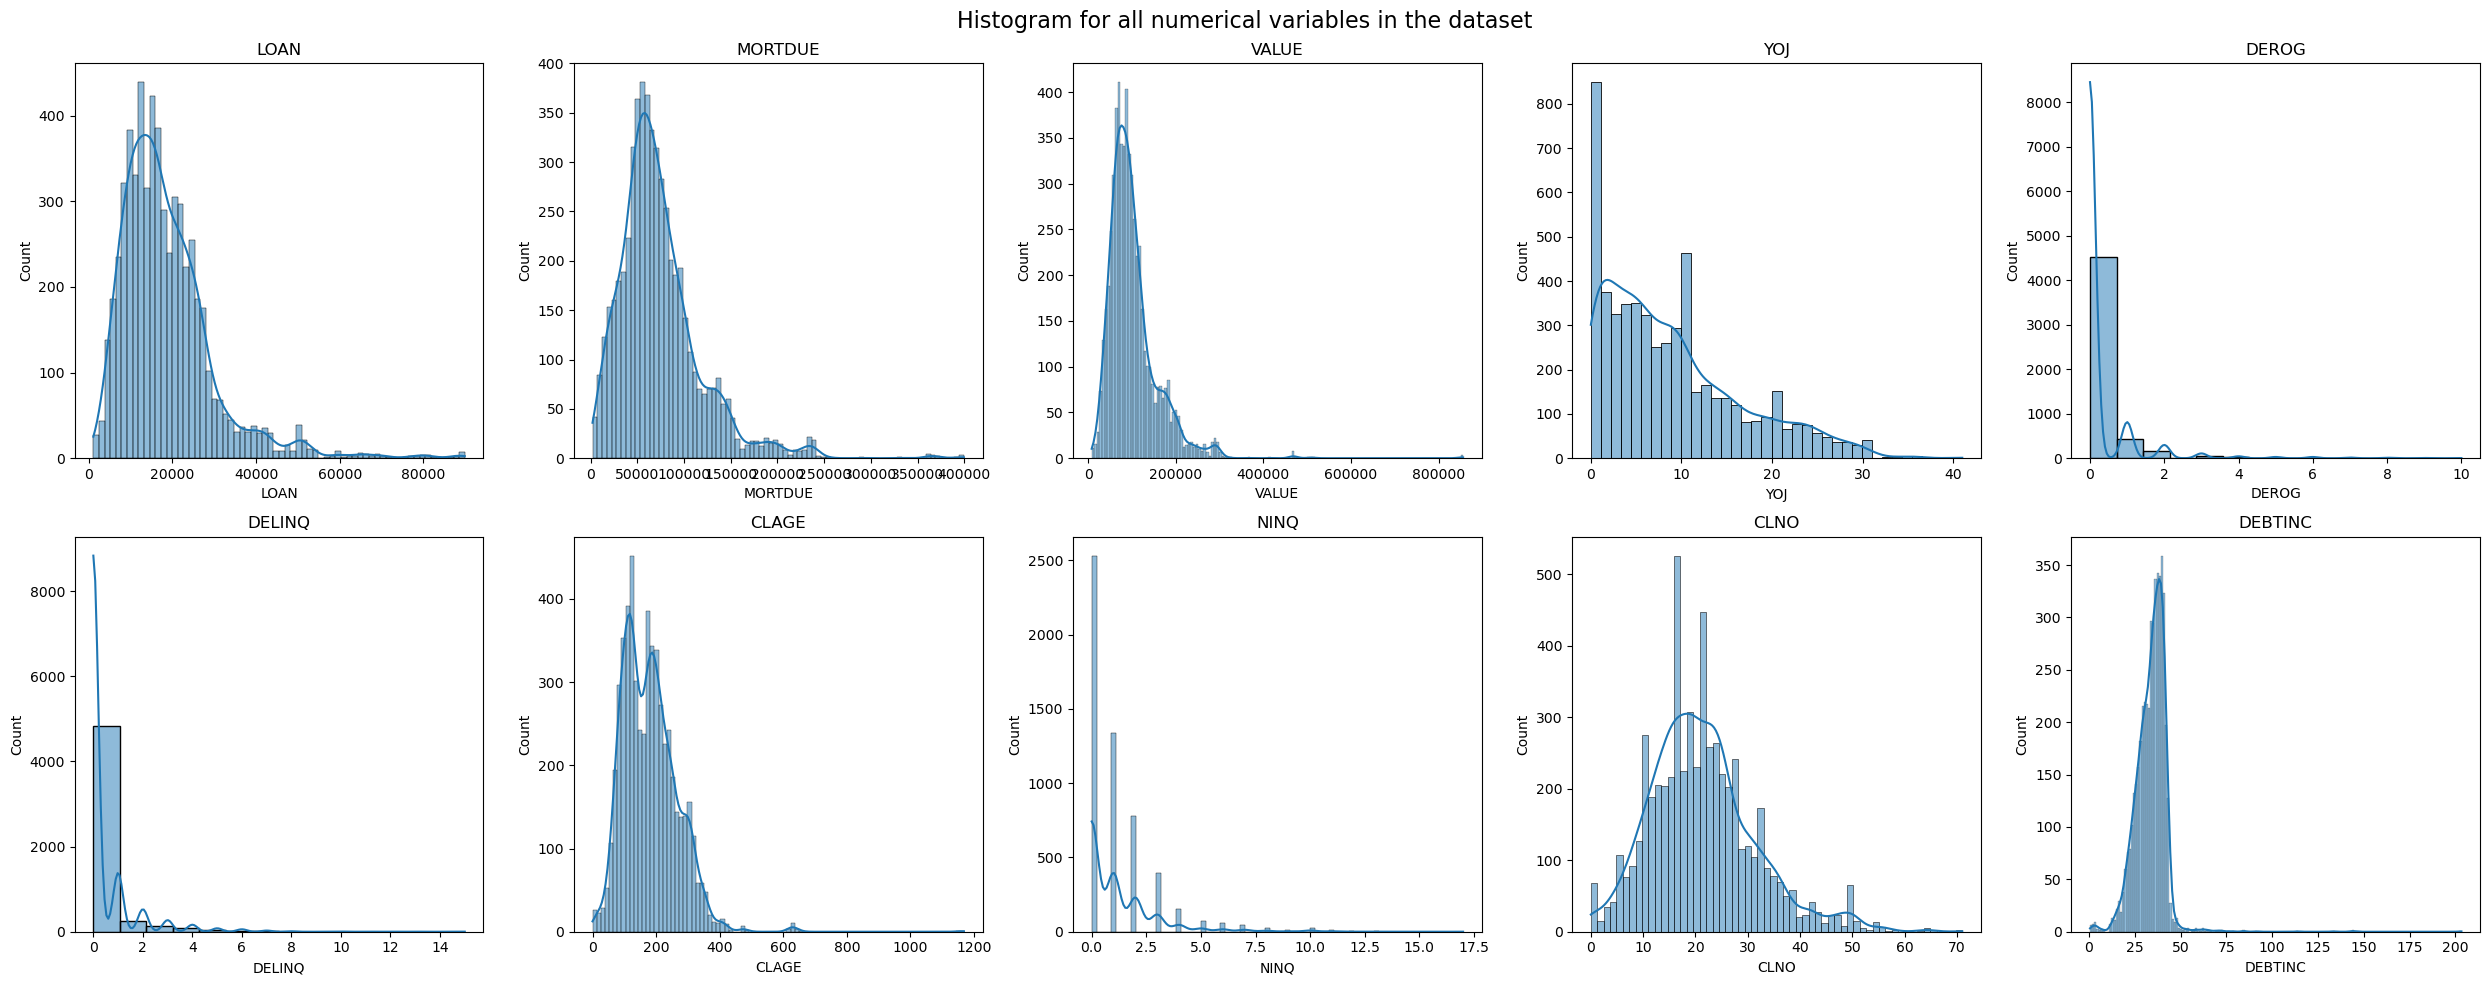

In [7]:
# Analysis of variable distribution

#1. Numerical variables

#num_cols = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

# All numerical variables
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Histogram for all numerical variables in the dataset', fontsize=16)

# Flatten axes for easier iteration
axes = axes.flatten()

# List of numerical columns

# Create histograms
for idx, col in enumerate(num_cols):
    sns.histplot(x=col, data=df, kde=True, ax=axes[idx])
    axes[idx].set_title(col)

plt.tight_layout()
plt.show()


In [8]:
# 1. Mode for numerical variables
print("\n1. Mode overview")
print("="*80)
# Compute mode for each numeric column
modes = {}
for col in num_cols:
    mode_value = df[col].mode(dropna=True)
    modes[col] = mode_value.iloc[0] if not mode_value.empty else None

# Convert to DataFrame for readability
mode_df = pd.DataFrame(list(modes.items()), columns=["Variable", "Mode"])
print(mode_df)

# 2. Zero count for numerical variables
print("\n2. Zero count for numerical variables")
print("="*80)

# Initialize dictionary
zero_stats = {}

# Calculate zero counts and percentages
for col in num_cols:
    zero_count = (df[col] == 0).sum()
    zero_percent = (zero_count / len(df)) * 100
    zero_stats[col] = {"Zero_Count": zero_count, "Zero_Percent": round(zero_percent, 2)}

# Convert to DataFrame for readability
zero_df = pd.DataFrame.from_dict(zero_stats, orient='index').reset_index()
zero_df.rename(columns={"index": "Variable"}, inplace=True)

# Display results
print(zero_df)




1. Mode overview
  Variable          Mode
0     LOAN  15000.000000
1  MORTDUE  42000.000000
2    VALUE  60000.000000
3      YOJ      0.000000
4    DEROG      0.000000
5   DELINQ      0.000000
6    CLAGE    102.500000
7     NINQ      0.000000
8     CLNO     16.000000
9  DEBTINC      0.524499

2. Zero count for numerical variables
  Variable  Zero_Count  Zero_Percent
0     LOAN           0          0.00
1  MORTDUE           0          0.00
2    VALUE           0          0.00
3      YOJ         415          6.96
4    DEROG        4527         75.96
5   DELINQ        4179         70.12
6    CLAGE           2          0.03
7     NINQ        2531         42.47
8     CLNO          62          1.04
9  DEBTINC           0          0.00



<p><strong>Distributions</strong></p>
<ul>
<li>LOAN: Right‑skewed with mode at 15k and a long tail to $89.9k.</li>
<li>MORTDUE: Highly right‑skewed with mode at 42k and an extreme tail to 399.6k.</li>
<li>VALUE: Right‑skewed like MORTDUE with mode at 60k and a tail to 855.9k.</li>
<li>YOJ: Very inflated at 0–2 years with mode at 0 and a short tail that caps at 41.</li>
<li>DEROG: Very inflated at zero (75% at zero) with few &gt;2–3.</li>
<li>DELINQ: Very inflated number of zero values (70% at zero) with few values &gt;6.</li>
<li>CLAGE: Near normal distribution with a slight right skew and a mode at 102 and a long tail that caps at 1,168 months (around 97.4 years) which is unusual, probably due to capture error.</li>
<li>NINQ: Right‑skewed with a mode at 0 and a short tail which caps at 17.</li>
<li>CLNO: Slight right skew with a mode at 16 and a long tail that caps at 71.</li>
<li>DEBTINC: Highly concentrated bellshape with a mode on 52% and extreme outliers with values over 100% (max 203.3%). Of which there are 45 cases over 50%.</li>
</ul>
<p>Cross‑cutting patterns &amp; implications</p>
<ul>
<li>Skewness: Monetary and inquiry variables are right‑skewed.</li>
<li>Zero inflated variables: DEROG/DELINQ have a very large number of zero values which will make them not as useful as numerical variables. We will test alternative variables with binary indicators to replace them.</li>
<li>Outliers: Information in variables MORTDUE, VALUE, DEBTINC, CLAGE should be further analyzed by SMEs to verify implausible values. All data will be maintained for modelling until further determination.</li>
<li>Scale differences: Variables are on vastly different scales so standardization will be important for modeling.</li>
<li>Missing values: There are robust issues with data at present. Therefore, the issues cannot be simply addressed by bypassing this with mean imputation. After research it was found that there are alternatives like Multiple Imputation by Chained Equations (MICE) and Missing value indicators which allow the analysis of missing value trends without losing any data. Although computationally intensive they will allow to draw out a more robust model since this is a small dataset. Some changes will be required for production deployment but learning will be used.</li>
</ul>
<p>Key references: Little, R. J. A., &amp; Rubin, D. B. (2019). Statistical Analysis with Missing Data (3rd ed.). Wiley.</p>


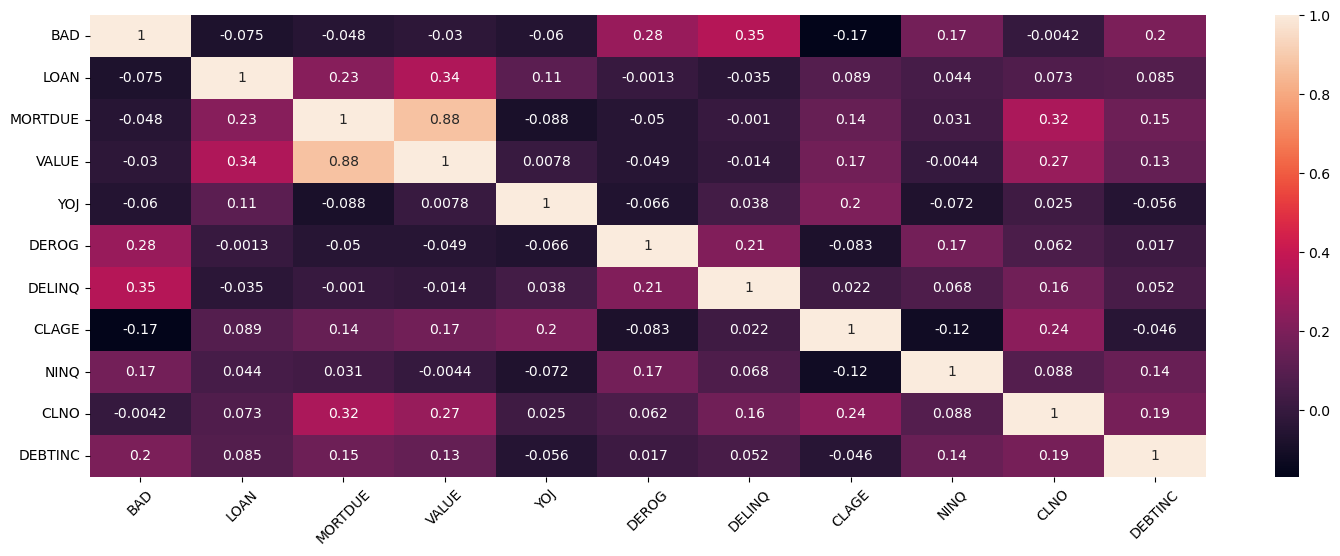

In [9]:
fig = plt.figure(figsize = (18, 6))

sns.heatmap(df.corr(numeric_only = True), annot = True);

plt.xticks(rotation = 45);


<h3 id="Correlation-Heatmap-Analysis">Correlation Heatmap Analysis<a class="anchor-link" href="#Correlation-Heatmap-Analysis">¶</a></h3><h4 id="Strong-Feature-Inter-Correlation-(+0.5-to-+0.9)">Strong Feature Inter-Correlation (+0.5 to +0.9)<a class="anchor-link" href="#Strong-Feature-Inter-Correlation-(+0.5-to-+0.9)">¶</a></h4><ul>
<li><strong>MORTDUE–VALUE (r = 0.88)</strong><br/>
There is a very strong positive correlation between mortgage due and property value, indicating that higher property values correspond to larger mortgage amounts.<br/>
This represents a <em>potential issue</em> since it suggests <strong>multicollinearity</strong>, which could distort regression-based models. Therefore, in the modelling we should consider removing one of these features or transforming it.</li>
</ul>
<h4 id="Weak-Relationships-with-Loan-Default-(BAD)-(+0.3-to-+0.4)">Weak Relationships with Loan Default (BAD) (+0.3 to +0.4)<a class="anchor-link" href="#Weak-Relationships-with-Loan-Default-(BAD)-(+0.3-to-+0.4)">¶</a></h4><ul>
<li><strong>DELINQ (r = 0.35)</strong><br/>
The number of delinquency reports shows a weak positive correlation with default likelihood, making it one of the most correlated features.</li>
<li><strong>DEROG (r = 0.28)</strong><br/>
Borrowers with derogatory credit reports are slightly more likely to default.</li>
<li><strong>DEBTINC (r = 0.20)</strong><br/>
Higher debt-to-income ratios correspond to a slightly higher probability of default.</li>
<li><strong>CLAGE (r = –0.17)</strong><br/>
A longer credit history (older accounts) is associated with a slightly lower likelihood of default.</li>
</ul>
<h4 id="Insignificant-Relationships-with-Default-(+0.0-to-+0.2)">Insignificant Relationships with Default (+0.0 to +0.2)<a class="anchor-link" href="#Insignificant-Relationships-with-Default-(+0.0-to-+0.2)">¶</a></h4><ul>
<li><strong>MORTDUE, VALUE, LOAN, YOJ, NINQ, CLNO</strong><br/>
These variables have weak or near-zero correlations with the target variable (–0.08 to +0.17).</li>
</ul>
<h4 id="Correlations-Among-Predictors">Correlations Among Predictors<a class="anchor-link" href="#Correlations-Among-Predictors">¶</a></h4><ul>
<li><strong>MORTDUE–VALUE (0.88)</strong> show structural overlap in financial profile information.</li>
</ul>
<h4 id="Conclusion">Conclusion<a class="anchor-link" href="#Conclusion">¶</a></h4><p>Overall, <strong>credit behavior variables</strong> such as delinquency, derogatory records, and debt-to-income ratio are the most indicative of default risk. Conversely, <strong>financial amount variables</strong> like property value and loan size show weak direct effects but introduce multicollinearity concerns.</p>
<hr/>
<h3 id="8.2.2-Analysis-of-categorical-variables">8.2.2 Analysis of categorical variables<a class="anchor-link" href="#8.2.2-Analysis-of-categorical-variables">¶</a></h3><h4 id="Categorical-Variables-Analysis">Categorical Variables Analysis<a class="anchor-link" href="#Categorical-Variables-Analysis">¶</a></h4><p>While numerical features provide quantitative measures of credit risk, the categorical variables in the dataset offer important contextual information about borrower circumstances and motivations. The HMEQ dataset contains two categorical features: loan purpose (REASON) and borrower occupation (JOB). These variables capture qualitative aspects of the borrowing profile that may influence default risk through different mechanisms than financial metrics alone.</p>
<p>Understanding the distribution and relationship of these categorical variables to loan default is essential for several reasons. First, loan purpose may reveal underlying financial stress levels—borrowers seeking debt consolidation may face different risk profiles than those pursuing home improvements. Second, occupational category can serve as a proxy for income stability, career trajectory, and economic vulnerability to market conditions. Finally, significant imbalances in category distributions may impact model performance and require special handling during feature encoding and model training.</p>
<p>The following analysis examines the distribution of both categorical variables, their relationship with the target variable (default status), and their potential utility as predictive features in our credit risk model.</p>
<p>The summarized distribution patterns for our categorical variables are illustrated in the subsection below.</p>


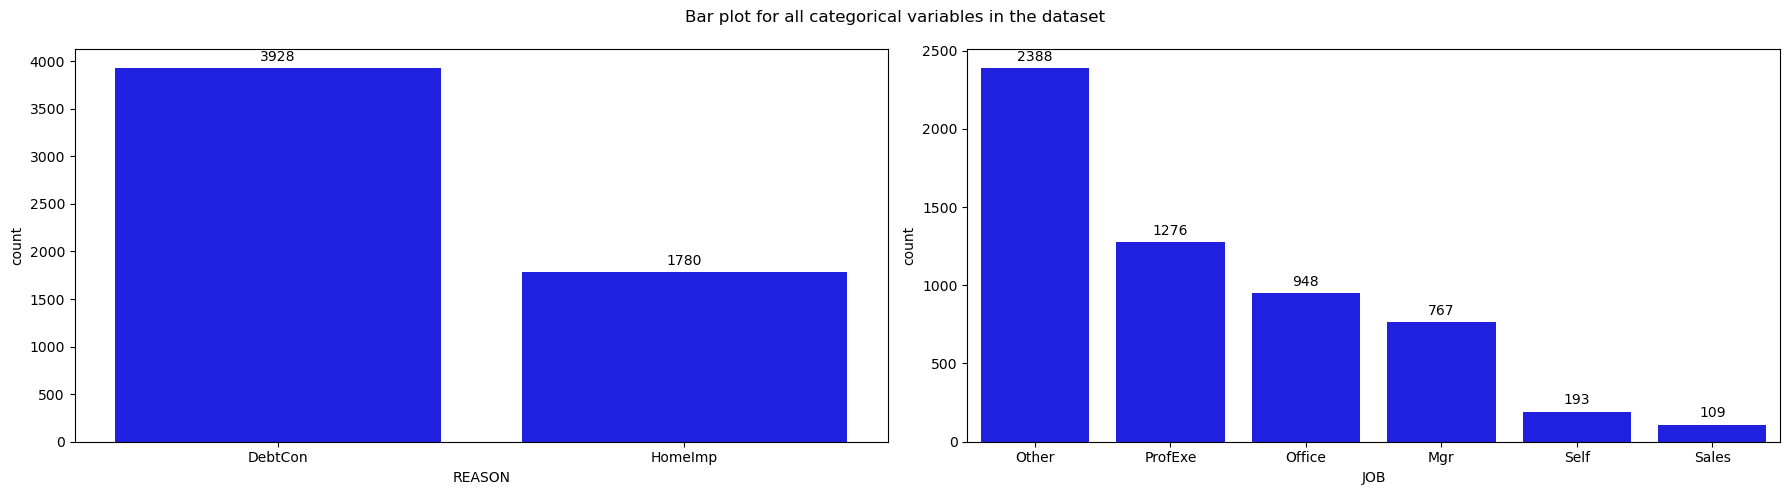

In [10]:
# cat_cols = ["REASON", "JOB"]
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Bar plot for all categorical variables in the dataset')

# Plot for REASON
sns.countplot(ax=axes[0], x="REASON", data=df, color='blue',
              order=df["REASON"].value_counts().index) #value counts was added as suggest by LLM to ease the analysis.

# Add count labels on REASON bars as suggested by LLM to simplify analysis.
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)

# Plot for JOB
sns.countplot(ax=axes[1], x="JOB", data=df, color='blue',
              order=df["JOB"].value_counts().index)

# Add count labels on JOB bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3)

plt.tight_layout()


<h4 id="Analysis-of-Categorical-Variable-Distributions">Analysis of Categorical Variable Distributions<a class="anchor-link" href="#Analysis-of-Categorical-Variable-Distributions">¶</a></h4><p>Categorical variables "REASON" and "JOB" from the HMEQ dataset.</p>
<p>Distribution of "REASON" (Reason for Loan)</p>
<table>
<thead>
<tr>
<th>Category</th>
<th>Count</th>
<th>Percentage</th>
<th>Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>DebtCon (Debt Consolidation)</strong></td>
<td>3,928</td>
<td>68.8%</td>
<td>Majority category</td>
</tr>
<tr>
<td><strong>HomeImp (Home Improvement)</strong></td>
<td>1,780</td>
<td>31.2%</td>
<td>Minority category</td>
</tr>
</tbody>
</table>
<p>Findings:</p>
<ul>
<li><strong>Debt Consolidation loans dominate</strong> the dataset, accounting for nearly <strong>seven out of every ten</strong> loan applications.</li>
<li><strong>Home Improvement loans</strong> are significantly less common, forming less than one-third of all records.</li>
<li>This confirms a <strong>strong categorical imbalance</strong> in the dataset.</li>
</ul>
<p>Implications:</p>
<ul>
<li>The dataset reflects a borrower population primarily focused on <strong>debt restructuring</strong>.</li>
<li>The imbalance could bias predictive models toward the predominant value ("DebtCon"), requiring for us to do <strong>stratified sampling</strong> to ensure fair learning.</li>
<li>The prevalence of debt-consolidation loans may signal a more structural risk in the market, as these borrowers often seek refinancing due to prior debt burdens.</li>
</ul>
<p>Distribution of "JOB" (Applicant’s Occupation)</p>
<table>
<thead>
<tr>
<th>Category</th>
<th>Count</th>
<th>Percentage</th>
<th>Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Other</strong></td>
<td>2,388</td>
<td>40.1%</td>
<td>Largest category; heterogeneous or unclassified occupations</td>
</tr>
<tr>
<td><strong>ProfExe (Professional/Executive)</strong></td>
<td>1,276</td>
<td>21.4%</td>
<td>Second largest; likely stable income profiles</td>
</tr>
<tr>
<td><strong>Office</strong></td>
<td>948</td>
<td>15.9%</td>
<td>Common clerical and administrative roles</td>
</tr>
<tr>
<td><strong>Mgr (Managerial)</strong></td>
<td>767</td>
<td>12.9%</td>
<td>Moderate representation; potential for higher income</td>
</tr>
<tr>
<td><strong>Self (Self-employed)</strong></td>
<td>193</td>
<td>3.2%</td>
<td>Low representation; likely variable income stability</td>
</tr>
<tr>
<td><strong>Sales</strong></td>
<td>109</td>
<td>1.8%</td>
<td>Smallest category; underrepresented</td>
</tr>
</tbody>
</table>
<p>Findings:</p>
<ul>
<li>The <strong>“Other”</strong> category covers <strong>40% of applicants</strong>, which suggests an issue with the job classification.</li>
<li><strong>Professional/Executive</strong> and <strong>Office</strong> roles together represent over one-third of borrowers, reflecting a potential bias in the dataset towards more office workers.</li>
<li><strong>Self-employed</strong> and <strong>Sales</strong> roles are <strong>minor categories</strong> and represent less than 5% of the sample, which should be considered when interpreting the models capabilities.</li>
</ul>
<p>Implications:</p>
<ul>
<li>The <strong>JOB</strong> variable shows <strong>moderate imbalance</strong> across categories.</li>
<li>The high share of “Other” values may mask meaningful occupational differences and should be further explored for reclassification of the variable.</li>
<li>Occupation (JOB) likely influences <strong>default risk</strong> so it is valuable for modelling purposes.</li>
<li>Given the skewed data, low-frequency job categories may need grouping or encoding strategies to prevent sparse data effects. This highlights the importance of using tree based models with built in handling like XGBoost.</li>
</ul>


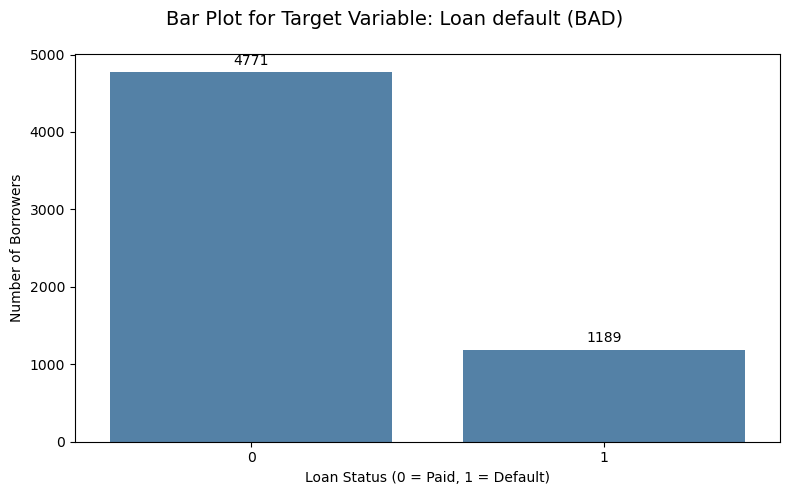

In [11]:
# Target variable analysis.

# BAD

# Create a single plot since only one variable (BAD) is being visualized
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Bar Plot for Target Variable: Loan default (BAD)", fontsize=14)

# Plot for BAD
sns.countplot(ax=ax, x="BAD", data=df, color="steelblue",
              order=df["BAD"].value_counts().index)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

# Label axes and adjust layout
ax.set_xlabel("Loan Status (0 = Paid, 1 = Default)")
ax.set_ylabel("Number of Borrowers")
plt.tight_layout()
plt.show()


<h3 id="8.2.3-Analysis-of-Target-Variable-Distribution:-Loan-Default-(BAD)">8.2.3 Analysis of Target Variable Distribution: Loan Default (<code>BAD</code>)<a class="anchor-link" href="#8.2.3-Analysis-of-Target-Variable-Distribution:-Loan-Default-(BAD)">¶</a></h3><p>The distribution of the <strong>target variable "BAD"</strong>, where:</p>
<ul>
<li>"1" -&gt; <strong>Client defaulted on the loan</strong> (unpaid)</li>
<li>"0" -&gt; <strong>Loan successfully repaid</strong></li>
</ul>
<p>Distribution Summary</p>
<table>
<thead>
<tr>
<th>Loan Status</th>
<th>Count</th>
<th>Percentage</th>
<th>Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>0 (Loan repaid)</strong></td>
<td>4,771</td>
<td>80.1%</td>
<td>Majority of borrowers successfully repaid their loans</td>
</tr>
<tr>
<td><strong>1 (Loan defaulted)</strong></td>
<td>1,189</td>
<td>19.9%</td>
<td>Minority of borrowers defaulted on their loans</td>
</tr>
</tbody>
</table>
<p>Total records: <strong>5,960</strong></p>
<p><strong>Key Findings</strong></p>
<ol>
<li><p><strong>Moderate Class Imbalance</strong></p>
<ul>
<li>The dataset shows a clear imbalance: about <strong>80% of loans are repaid</strong>, while <strong>20% result in default</strong>.</li>
<li>This imbalance is moderate but sufficient to bias a classification model toward predicting the majority outcome (loan repaid).</li>
<li>The implication is that the model could achieve 80% accuracy just by predicting all loans as repaid, which would be <strong>misleading</strong>.</li>
</ul>
</li>
<li><p><strong>Default Rate (20%)</strong></p>
<ul>
<li>Approximately <strong>1 in every 5 borrowers defaults</strong> on their loan.</li>
<li>This reflects <strong>significant financial risk exposure</strong> for the bank and suggests that the dataset represents a realistic credit portfolio with mixed borrower quality.</li>
<li>Identifying the characteristics of the <strong>19.9% defaulting group</strong> is crucial for credit risk mitigation.</li>
</ul>
</li>
<li><p><strong>Modeling Implications</strong></p>
<ul>
<li>Because of the imbalance, model training should incorporate techniques to <strong>ensure sensitivity to the minority (default) class</strong>:<ul>
<li>Adjust class weights in algorithms ("class_weight="balanced")</li>
<li>Apply <strong>oversampling</strong> (e.g., SMOTE) or <strong>undersampling</strong></li>
<li>It will be very important to consider <strong>ensemble learning</strong> approaches</li>
</ul>
</li>
<li>Model evaluation must emphasize:<ul>
<li><strong>Recall (Sensitivity)</strong> for class "1" (defaults): to minimize missed default predictions.</li>
</ul>
</li>
</ul>
</li>
<li><p><strong>Business Interpretation</strong></p>
<ul>
<li>The <strong>majority of clients are creditworthy</strong>, yet the <strong>20% default rate</strong> indicates substantial potential loss if not properly managed.</li>
<li>Early identification of at-risk borrowers can enable:<ul>
<li>Proactive risk interventions (e.g., restructuring, targeted repayment plans)</li>
<li>Better credit approval policies</li>
<li>Improved capital allocation and provisioning strategies</li>
</ul>
</li>
</ul>
</li>
</ol>


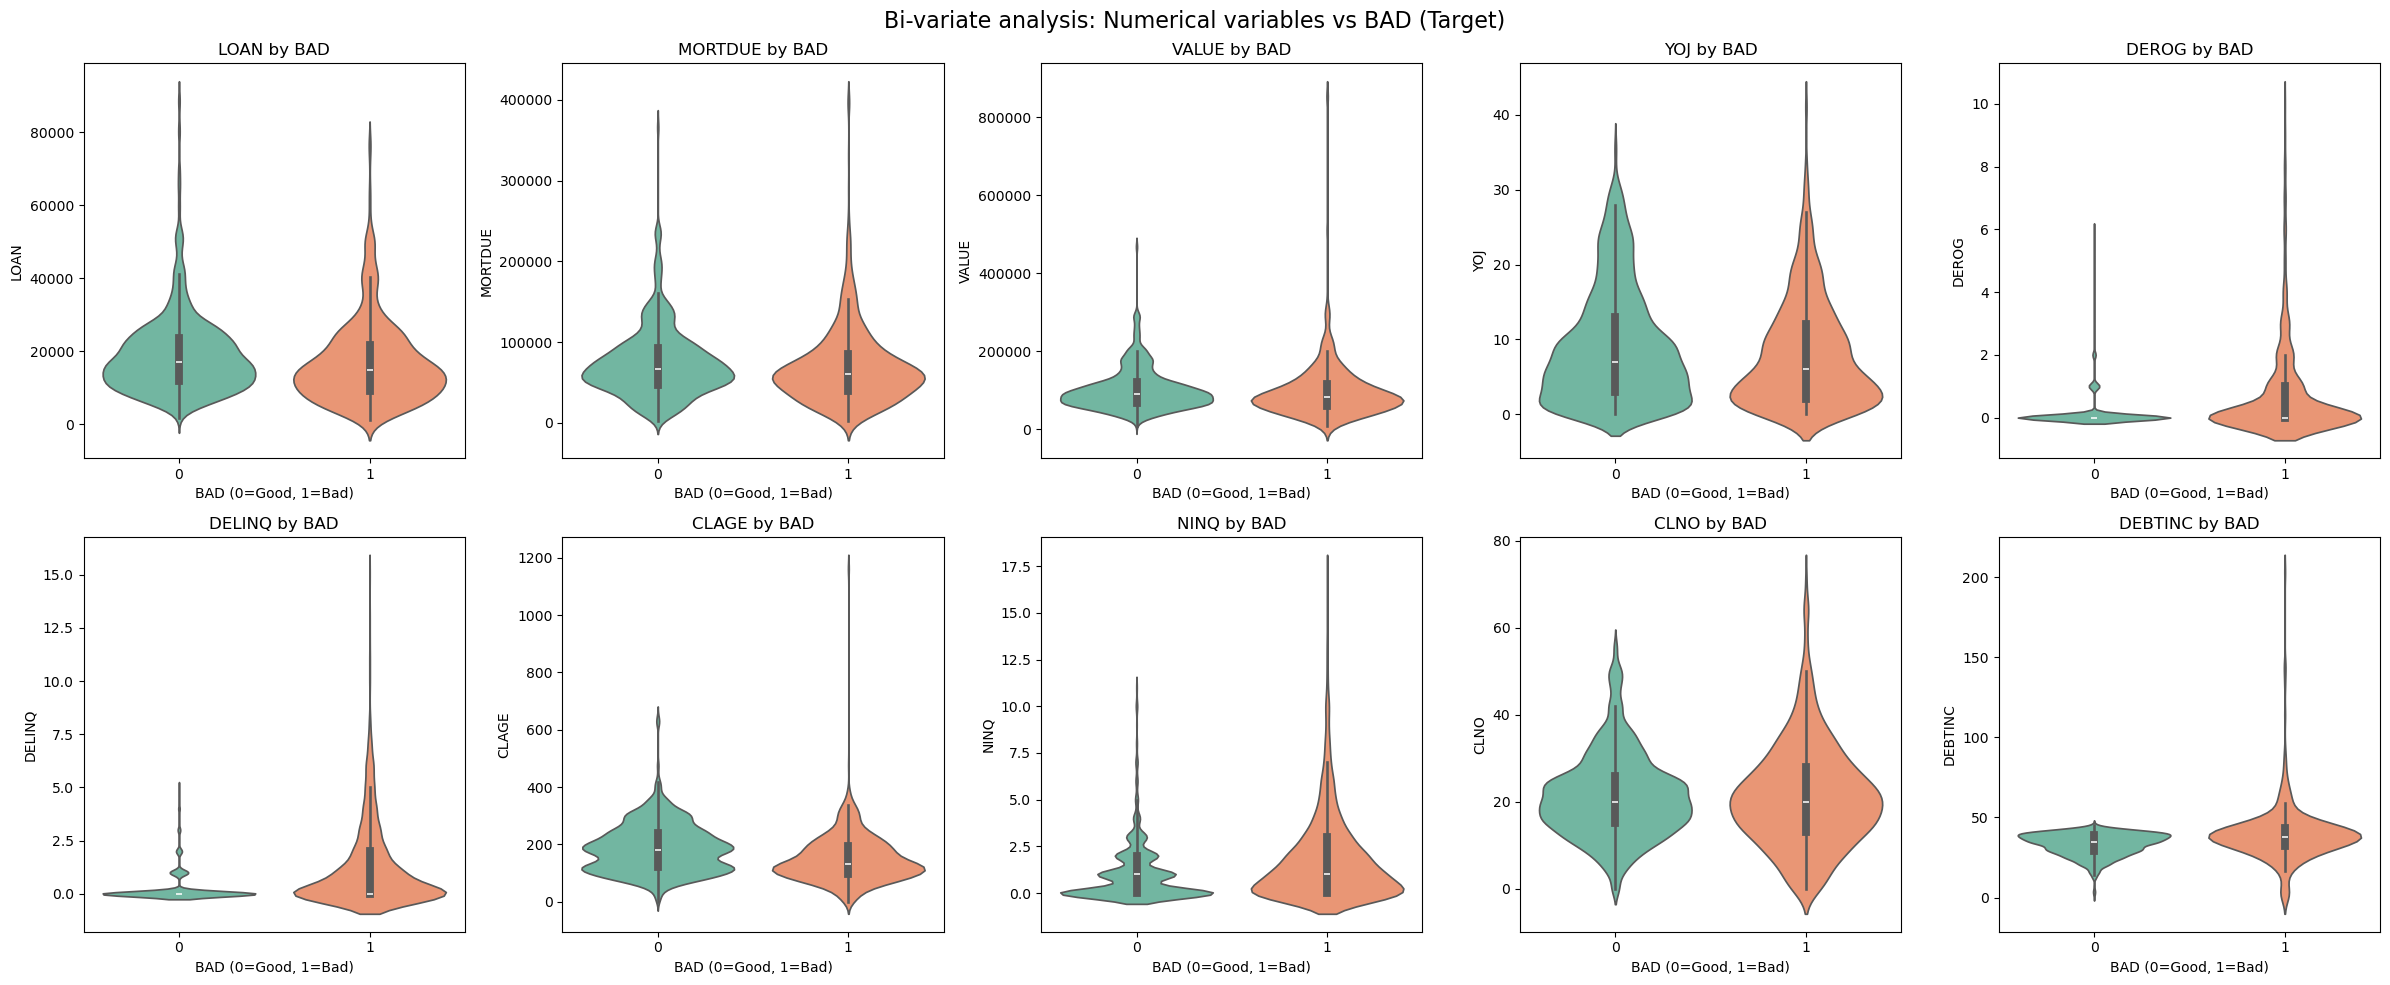

In [12]:
num_cols = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('Bi-variate analysis: Numerical variables vs BAD (Target)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(x='BAD', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by BAD')
    axes[i].set_xlabel('BAD (0=Good, 1=Bad)')
    axes[i].set_ylabel(col)

plt.tight_layout()


<h4 id="8.4-Bi-variate-Analysis:-Numerical-Predictors-vs-Loan-Default-(%22BAD%22)">8.4 Bi-variate Analysis: Numerical Predictors vs Loan Default ("BAD")<a class="anchor-link" href="#8.4-Bi-variate-Analysis:-Numerical-Predictors-vs-Loan-Default-(%22BAD%22)">¶</a></h4><p>The graphs above show the <strong>distribution of numerical variables</strong> across the two target categories:</p>
<ul>
<li><code>BAD = 0</code> → <strong>Loan repaid</strong></li>
<li><code>BAD = 1</code> → <strong>Loan defaulted</strong></li>
</ul>
<p>Each subplot compares the distribution of a numerical feature between these two groups comparing the different characteristics of borrowers who default and those who do not.</p>
<ol>
<li><strong>Loan Amount ("LOAN")/Mortgage Due ("MORTDUE")/Property Value ("VALUE")/Years on Job ("YOJ")</strong></li>
</ol>
<ul>
<li>The distribution is similar across both groups. Since the overlap is substantial, data suggests that these variables alone are likely <strong>not strong predictors</strong> of default.</li>
</ul>
<ol start="2">
<li><strong>Derogatory Credit Reports ("DEROG")</strong></li>
</ol>
<ul>
<li>One of the most discriminative variables:<ul>
<li>Borrowers with "BAD=1" show <strong>more derogatory credit reports</strong>, often greater than 1.</li>
<li>Borrowers who repaid ("BAD=0") mostly have <strong>zero derogatory reports</strong>.</li>
</ul>
</li>
</ul>
<ol start="3">
<li><strong>Delinquency Reports ("DELINQ")</strong></li>
</ol>
<ul>
<li>Another strong indicator: the median and tail of the distribution are much higher for <code>BAD=1</code>.</li>
<li>Defaulting borrowers exhibit <strong>multiple delinquencies</strong>, while most non-defaulters have none.</li>
<li>Reinforces that <strong>recent payment issues</strong> are predictive of future default.</li>
</ul>
<ol start="4">
<li><strong>Age of Oldest Credit Line ("CLAGE")</strong></li>
</ol>
<ul>
<li>Borrowers with repaid loans ("BAD=0") tend to have <strong>older credit histories</strong> (higher CLAGE).</li>
<li>Defaulters exhibit <strong>younger credit lines</strong>, indicating shorter credit experience.</li>
<li>Suggests <strong>credit maturity and relationship history</strong> mitigate default risk.</li>
</ul>
<ol start="5">
<li><strong>Number of Recent Credit Inquiries ("NINQ")</strong></li>
</ol>
<ul>
<li>Defaulting borrowers ("BAD=1") show <strong>higher credit inquiry activity</strong>, indicating potential credit-seeking behavior or financial stress.</li>
<li>This aligns with typical risk patterns in consumer credit analytics.</li>
</ul>
<ol start="6">
<li><strong>Number of Credit Lines ("CLNO")</strong></li>
</ol>
<ul>
<li>Repaid borrowers have <strong>slightly more open credit lines</strong> than defaulters, indicating diversified and managed credit usage.</li>
<li>Those who have defaulted show lower credit line counts which could be a result of <strong>restricted credit access</strong>.</li>
</ul>
<ol start="7">
<li><strong>Debt-to-Income Ratio ("DEBTINC")</strong></li>
</ol>
<ul>
<li>One of the most marked differences:<ul>
<li>Defaulters show <strong>significantly higher debt-to-income ratios</strong>.</li>
<li>High DEBTINC indicates financial overextension and reduced repayment capacity.</li>
</ul>
</li>
</ul>
<p><strong>Key findings</strong></p>
<ul>
<li>The <strong>behavioral and credit quality variables</strong> ("DEROG", "DELINQ", "DEBTINC") show the most marked differences between categories of default.</li>
<li><strong>Loan and asset related variables</strong> ("LOAN", "VALUE", "MORTDUE", "YOJ") exhibit <strong>high overlap</strong>, suggesting they carry limited independent explanatory power.</li>
<li>These patterns align with credit risk theory: <strong>borrower reliability and financial burden metrics</strong> are far more predictive of default than absolute loan or property values.</li>
</ul>
<p><strong>Modeling Implications</strong></p>
<ul>
<li>The most promising predictors for model inclusion seem to be:<ul>
<li><strong>Credit behavior indicators:</strong> "DEROG", "DELINQ", "DEBTINC"</li>
<li><strong>Experience and history indicators:</strong> "CLAGE", "YOJ", "NINQ"</li>
</ul>
</li>
<li>Weak variables (e.g., "LOAN", "VALUE", "MORTDUE") may still contribute interactively but should be <strong>evaluated for redundancy</strong> due to high correlation (as seen in prior correlation heatmap).</li>
<li>Feature scaling and transformation will improve model stability.</li>
</ul>
<h3 id="8.5-Exploratory-Data-Analysis-(EDA)-%E2%80%94-Findings-and-Implications">8.5 Exploratory Data Analysis (EDA) — Findings and Implications<a class="anchor-link" href="#8.5-Exploratory-Data-Analysis-(EDA)-%E2%80%94-Findings-and-Implications">¶</a></h3><p>Summary of Empirical Findings</p>
<p><strong>Target distribution and class balance.</strong> The outcome variable is imbalanced: 80.1% repaid vs. 19.9% defaulted (BAD=1). This implies that we will have to take measures to stratify the sample. Since our interest is in avoiding default, model evaluation metrics emphasis should be on <strong>recall</strong> for BAD=1 (defaults), supported by precision/PR-AUC.</p>
<p><strong>Predictor information completeness.</strong> 56.4% of rows are complete; 43.5% have ≥1 missing predictor. Given this, data removal or feature drop would likely induce unnecessary information loss and potential bias. As a response we will be doing imputation testing simple and MICE algorithms.</p>
<p><strong>Missing values by variable.</strong></p>
<ul>
<li><strong>High:</strong> "DEBTINC" (21.3%).</li>
<li><strong>Medium (8–12%):</strong> "MORTDUE", "YOJ", "NINQ", "DELINQ".</li>
<li><strong>Low (&lt;5%):</strong> "VALUE", "REASON", "JOB", "CLAGE", "CLNO".<br/>
The missing values pattern could carry information (i.e. non-responses on income-related fields) therefore we will test creating <strong>missing value indicators</strong> and test their association with BAD before and after imputation.</li>
</ul>
<p><strong>Univariate distributions and anomalies.</strong></p>
<ul>
<li>Monetary and inquiry variables are <strong>right-skewed</strong> ("LOAN", "MORTDUE", "VALUE", "NINQ").</li>
<li><strong>Zero-inflated</strong> behavior in "DEROG" (75% zeros) and "DELINQ" (70% zeros) could be addressed by binary flags (zero vs. &gt;0) to improve interpretability and stability.</li>
<li><strong>Outliers/implausible values:</strong> "DEBTINC" up to 203.3%; "CLAGE" up to 1,168 months (97.4 years). There should be some subject matter expert review of data to apply business-rule checks and robust handling. However, for the purpose of modelling we will continue assuming they are valid while waiting for substantive data-quality remediation.</li>
<li><strong>Logical inconsistencies:</strong> 51 cases where "MORTDUE" &gt; "VALUE" (LTV&gt;100%). Which should be reviewed by subject matter experts. For now no information will be removed.</li>
</ul>
<p><strong>Bivariate signal (to BAD).</strong></p>
<ul>
<li><strong>Stronger signals:</strong> higher "DELINQ", higher "DEROG", higher "DEBTINC" are associated with higher default; longer "CLAGE" (older files) with lower default; higher "NINQ" modestly associated with higher default.</li>
<li><strong>Weaker signals:</strong> "LOAN", "VALUE", "MORTDUE", "YOJ", "CLNO" show substantial overlap between classes. However they will be used since they may still matter via interactions or other effects.</li>
</ul>
<p><strong>Multicollinearity among predictors.</strong></p>
<ul>
<li>"MORTDUE"–"VALUE" is <strong>highly correlated</strong> (r=0.88). For regression-style models this could mean variance inflation so we will retain one when modelling regression model. For trees we will monitor stability and redundancy.</li>
</ul>
<p><strong>Categorical variables.</strong></p>
<ul>
<li><strong>REASON</strong> is imbalanced (DebtCon 69%, HomeImp 31%).</li>
<li><strong>JOB</strong> shows moderate imbalance and a very large <strong>“Other”</strong> bucket (40%), which may dilute signal. We will regroup low frequency categories to provide stronger signals based on job types to avoid sparse effects.</li>
</ul>
<h5 id="Implications-for-Data-Preparation">Implications for Data Preparation<a class="anchor-link" href="#Implications-for-Data-Preparation">¶</a></h5><ol>
<li>Missing Data Treatment</li>
</ol>
<ul>
<li><strong>Primary approach:</strong> Benchmark <strong>simple imputation</strong> (median/mode) vs. <strong>MICE</strong> for "DEBTINC" (21.3%), and medium-missing variables ("MORTDUE", "YOJ", "NINQ", "DELINQ").</li>
<li><strong>Missing value indicators:</strong> Add <strong>binary missing-value indicators</strong> for all imputed predictors; test association with <code>BAD</code> pre/post-imputation.</li>
</ul>
<ol start="2">
<li>Outliers, Anomalies, and Logical Checks</li>
</ol>
<ul>
<li><strong>Do not remove</strong> outliers during modeling</li>
<li><strong>Logical inconsistency:</strong> Retain cases while SME review is pending.</li>
</ul>
<ol start="3">
<li>Zero-Inflated Counts</li>
</ol>
<ul>
<li>For "DEROG" and "DELINQ":<ul>
<li>Add <strong>binary indicators</strong> (<code>&gt;0</code> vs. <code>=0</code>).</li>
</ul>
</li>
</ul>
<ol start="4">
<li>Scaling and Transformations</li>
</ol>
<ul>
<li><strong>Standardize</strong> continuous variables for linear models.</li>
</ul>
<ol start="5">
<li>Multicollinearity Management</li>
</ol>
<ul>
<li>Construct new feature <strong>LTV = MORTDUE / VALUE</strong> (using prior imputation) and an <strong>"LTV&gt;100%"</strong> flag.</li>
<li><strong>Regression:</strong> When modelling using regression models use <strong>LTV</strong> over jointly using "MORTDUE" and "VALUE" to reduce issues.</li>
<li><strong>Tree modelling:</strong> When modelling using tree models we will retain both, but <strong>monitor redundancy/stability</strong>.</li>
</ul>
<ol start="6">
<li>Categorical Encoding</li>
</ol>
<ul>
<li><strong>REASON:</strong> WE will implement one-hot encoding after imputation robust mechanisms like MICE.</li>
<li><strong>JOB:</strong> <strong>Group low-frequency categories</strong> and keep an <strong>“Other/Unknown”</strong> bucket to prevent sparsity; then one-hot (or WOE/monotone bins for scorecards).</li>
</ul>
<ol start="7">
<li>Class Imbalance Controls</li>
</ol>
<ul>
<li>Use <strong>stratified sampling</strong> in data separation for train and testing samples.</li>
<li>Use <strong>class weights</strong> balancing (class_weight="balanced") when using  compare to <strong>SMOTE/undersampling</strong> within CV.</li>
<li>Evaluate performance threshold for <strong>recall</strong> reviewing PR-AUC/recall trade-offs.</li>
</ul>
<p>Through this processing we are aiming to preserve information (minimal row drops), encodes missingness and zero-inflation explicitly, mitigates multicollinearity for regression models, stabilize linear models through scaling/binning, and prepare balanced training/testing datasets aligned to the business focus on catching defaults (high recall on <code>BAD=1</code>).</p>


<h3 id="8.3-Data-Preparation">8.3 Data Preparation<a class="anchor-link" href="#8.3-Data-Preparation">¶</a></h3><p>As part of the data preparation we are taking steps to manage the issues highlighted in previouys sections. so that the underlying structure of the data is optimally set for machine learning algorithms including classic logistic regression and Bayesian inference. This is important since these are sensitive to the layout and quality of the input data.</p>
<p>Data Cleansing</p>
<p>Data cleansing involves addressing missing values and ensuring the dataset is free from inconsistencies. As a result of the previoys analysis we will be performing the following preparations:</p>
<ul>
<li>DEBTINC was imputed using the mean value.</li>
<li>DELINQ was set to 0 for missing entries.</li>
<li>JOB was assigned the placeholder value "Missing."</li>
<li>Remaining missing values were dropped, reducing the dataset from 5,960 observations to 4,359.</li>
</ul>
<p>This step ensures that the dataset is clean and ready for further processing. No additional variables were derived from the existing ones, as the current features were deemed sufficient for predicting the target outcome.</p>
<p>Feature Engineering and Encoding</p>
<p>Feature engineering is a key component of data preparation, involving the transformation of variables to make them suitable for machine learning models. In this analysis we have implemented the following actions:</p>
<p><strong>Categorical Variables</strong>: The two categorical variables, REASON and JOB, were encoded using one-hot encoding to convert them into numerical representations.
<strong>Scaling:</strong> Scaling was applied to ensure that numerical features were on a comparable scale. Two scaling strategies were evaluated:</p>
<ul>
<li><strong>Normalization:</strong> Rescales data to a fixed range between 0 and 1.</li>
<li><strong>Max-Absolute Scaling:</strong> Uses the <em>maximum absolute value</em> of each feature to scale data to the range [-1, 1], preserving sparsity and sign information.</li>
</ul>
<p>The <strong>MaxAbsScaler</strong> from <em>scikit-learn</em> was ultimately selected because it maintains zero-centered distributions without distorting sparse or binary features. Scaling is particularly important for algorithms such as <strong>logistic regression</strong>, which are sensitive to feature magnitudes.</p>
<p>Data Processing Pipelines</p>
<p>The data preparation process was streamlined using Python's Scikit-Learn library, which allows for the creation of robust pipelines. These pipelines included:</p>
<ul>
<li>Imputation of missing values.</li>
<li>Feature selection and encoding.</li>
<li>Scaling (standardisation and normalisation).</li>
<li>Dimensionality reduction.</li>
</ul>
<p>The pipelines were designed to integrate seamlessly with machine learning models such as logistic regression, SVM, random forest, decision tree, gradient boosting, and extreme boosting. Hyperparameter tuning was performed using GridSearchCV to identify the best model configurations.</p>
<p>Handling Data Leakage</p>
<p>To maintain model integrity, careful measures were taken to prevent data leakage. Data leakage occurs when information from the test or validation datasets inadvertently influences the training dataset, leading to overly optimistic performance metrics. To mitigate this:</p>
<ul>
<li>Scaling and feature extraction were applied only after splitting the data into training, testing, and validation sets.</li>
<li>Proper stratification was used during the train-test split to address the imbalance in the target variable BAD, ensuring that both training and test datasets maintained the same class ratio.</li>
</ul>
<p>By following these best practices, the data preparation process ensured a clean, well-structured dataset, ready for effective model training and evaluation.</p>


In [13]:
# Data preparation pipeline
# Data reporting sections of code were generated using LLM to simplify reporting and summary. 

# Drop rows with no predictor data
print("\n" + "="*80)
print("Remove rows with no predictor data")
print("="*80)

# Identify predictor columns (all except BAD)
predictor_cols = [col for col in df.columns if col != 'BAD']

# Count missing values per row for predictors only
missing_per_row = df[predictor_cols].isna().sum(axis=1)

# Identify rows with ALL predictors missing
rows_no_data = missing_per_row == len(predictor_cols)
print(f"Rows with no predictor data: {rows_no_data.sum()}")

# Drop these rows
df_clean = df[~rows_no_data].copy()
print(f"Shape after removal: {df_clean.shape}")

# For MICE imputation we import an additional library
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

print("="*80)
print("ORIGINAL DATASET SHAPE:", df.shape)
print("="*80)

# 1. Create missing value indicators before imputation******************************************
print("1. CREATING MISSING VALUE INDICATORS")
print("="*80)

# Variables with missing data that will be imputed
vars_to_impute = ['MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 
                  'NINQ', 'CLNO', 'DEBTINC', 'REASON', 'JOB']

# Create binary missing indicators following recommendations in Little, Roderick J. A., and Donald B. Rubin. 2019. Statistical Analysis with Missing Data. 3rd ed. Hoboken, NJ: Wiley. And implemented using LLM suggestion.
for var in vars_to_impute:
    indicator_name = f'MISSING_{var}'
    df_clean[indicator_name] = df_clean[var].isna().astype(int)
    print(f"{indicator_name}: {df_clean[indicator_name].sum()} missing ({df_clean[indicator_name].mean()*100:.2f}%)")

# 2. Creating zero-inflated binary indicators as suggested by He, Haibo, and Edwardo A. Garcia. 2009. “Learning from Imbalanced Data.” IEEE Transactions on Knowledge and Data Engineering 21 (9): 1263–84.
print("\n" + "="*80)
print("2. Creating zero inflated indicators for DEROG and DELINQ")
print("="*80)

# Binary indicators for zero-inflated count variables forced to be int types.
df_clean['DEROG_ANY'] = (df_clean['DEROG'] > 0).astype(int)
df_clean['DELINQ_ANY'] = (df_clean['DELINQ'] > 0).astype(int)

print(f"DEROG_ANY (has derogatory reports): {df_clean['DEROG_ANY'].sum()} cases")
print(f"DELINQ_ANY (has delinquencies): {df_clean['DELINQ_ANY'].sum()} cases")

# 3. Missing value imputation (MICE and Simple imputation) *********************************************************
print("\n" + "="*80)
print("3. Imputation for missing values")
print("="*80)

# Numerical and categorical groupings
#num_cols = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]
#cat_cols = ["REASON", "JOB"]

# A. Simple imputation
print("\nAPPROACH 1: Simple Imputation (Median/Mode)")
print("*" * 80)

# Create the dataframe for simple imputation
df_simple = df_clean.copy()

# A.1 Numerical variables median imputation
for col in num_cols:
    if df_simple[col].isna().any():
        median_val = df_simple[col].median()
        df_simple[col].fillna(median_val, inplace=True)
        print(f"  {col}: Imputed with median = {median_val:.2f}")

# A.2 Categorical variables mode imputation
for col in cat_cols:
    if df_simple[col].isna().any():
        mode_val = df_simple[col].mode()[0]
        df_simple[col].fillna(mode_val, inplace=True)
        print(f"  {col}: Imputed with mode = '{mode_val}'")

# MICE imputation following Little, Roderick J. A., and Donald B. Rubin. 2019. Statistical Analysis with Missing Data. 3rd ed. Hoboken, NJ: Wiley. And implemented using LLM suggestion.
print("\nAPPROACH 2: MICE (Multiple Imputation by Chained Equations)")
print("*" * 80)

#Create the new dataframe copy for MICE imputation
df_mice = df_clean.copy()

# Numerical variables MICE imputation
mice_imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy="median", imputation_order="ascending")

# Fit and transform numerical columns
numerical_imputed = mice_imputer.fit_transform(df_mice[num_cols])
df_mice[num_cols] = numerical_imputed
print("  Numerical variables: Imputed using MICE")

# Categorical variables will use mode imputation in this dataframe since MICE doesn't handle categorical well according 
# to Little, Roderick J. A., and Donald B. Rubin. 2019. Statistical Analysis with Missing Data. 3rd ed. Hoboken, NJ: Wiley. And implemented using LLM suggestion.
for col in cat_cols:
    if df_mice[col].isna().any():
        mode_val = df_mice[col].mode()[0]
        df_mice[col].fillna(mode_val, inplace=True)
        print(f"  {col}: Imputed with mode = '{mode_val}'")

# 4. Feature engineering (LTV ratio) *******************************************************************
print("\n" + "="*80)
print("STEP 4: Feature engineering for MORTDUE and VALUE")
print("="*80)

# Create LTV for both approaches
for df_name, df_temp in [("Simple", df_simple), ("MICE", df_mice)]:
    # LTV ratio
    df_temp["LTV"] = df_temp["MORTDUE"] / df_temp["VALUE"]
    
    # Handle division by zero or infinity. As suggested by LLM after initial issues arose in code run.
    df_temp["LTV"] = df_temp["LTV"].replace([np.inf, -np.inf], np.nan)
    df_temp["LTV"].fillna(df_temp["LTV"].median(), inplace=True)
    
    # LTV > 100% indicator
    df_temp["LTV_OVER100"] = (df_temp["LTV"] > 1.0).astype(int)
    
    print(f"\n{df_name} Imputation:")
    print(f"  LTV mean: {df_temp["LTV"].mean():.4f}")
    print(f"  LTV median: {df_temp["LTV"].median():.4f}")
    print(f"  Cases with LTV > 100%: {df_temp["LTV_OVER100"].sum()} ({df_temp["LTV_OVER100"].mean()*100:.2f}%)")


# 5. Categorical variable encoding**************************************************************************
print("\n" + "="*80)
print("5. Categorical variable encoding")
print("="*80)

def encode_categoricals(df):
    """Encode categorical variables with grouping for low-frequency categories"""
    df_encoded = df.copy()
    
    # REASON: One-hot encoding (already has low cardinality)
    print("\nREASON encoding:")
    print(df_encoded["REASON"].value_counts())
    reason_dummies = pd.get_dummies(df_encoded["REASON"], prefix="REASON", drop_first=True, dtype=int)
    df_encoded = pd.concat([df_encoded, reason_dummies], axis=1)
    
    # JOB: Group low-frequency categories
    print("\nJOB encoding (before grouping):")
    print(df_encoded["JOB"].value_counts())
    
    # Keep top categories, group the rest as "Other_LowFreq". It should be noted that this approach is not scalable and a dynamic low frequency encoding should be done. Not implemented here.
    top_jobs = ["Other", "ProfExe", "Office", "Mgr"]
    df_encoded["JOB_GROUPED"] = df_encoded["JOB"].apply(
        lambda x: x if x in top_jobs else "Other_LowFreq" #code correction using LLM since issues for encoding were not resolved.
    )
    
    print("\nJOB encoding (after grouping):")
    print(df_encoded["JOB_GROUPED"].value_counts())
    
    # One-hot encode the grouped JOB
    job_dummies = pd.get_dummies(df_encoded["JOB_GROUPED"], prefix="JOB", drop_first=True, dtype=int)
    df_encoded = pd.concat([df_encoded, job_dummies], axis=1)
    
    # Drop original categorical columns
    df_encoded.drop(["REASON", "JOB", "JOB_GROUPED"], axis=1, inplace=True)
    
    return df_encoded

# Apply encoding to both datasets. Based on LLM suggestion since no success was had on inital attempts.
df_simple_encoded = encode_categoricals(df_simple)
df_mice_encoded = encode_categoricals(df_mice)

print(f"\nShape after encoding (Simple): {df_simple_encoded.shape}")
print(f"Shape after encoding (MICE): {df_mice_encoded.shape}")

# 6. Train-test split of data with stratification *****************************************************************
print("\n" + "="*80)
print("6. Splitting data to train and test samples with stratification")
print("="*80)

def create_train_test(df, test_size=0.3, random_state=42): #function addded with LLM support to use both imputation approaches.
    """Create stratified train-test split"""
    X = df.drop("BAD", axis=1)
    y = df["BAD"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)  # with stratified sampling
    return X_train, X_test, y_train, y_test

# Create splits for both imputation approaches. Added with LLM suggestion since no solution was achieved earlier.
X_train_simple, X_test_simple, y_train_simple, y_test_simple = create_train_test(df_simple_encoded)
X_train_mice, X_test_mice, y_train_mice, y_test_mice = create_train_test(df_mice_encoded)

print("\nSimple Imputation Split:")
print(f"  Train set: {X_train_simple.shape}, Default rate: {y_train_simple.mean()*100:.2f}%")
print(f"  Test set: {X_test_simple.shape}, Default rate: {y_test_simple.mean()*100:.2f}%")

print("\nMICE Imputation Split:")
print(f"  Train set: {X_train_mice.shape}, Default rate: {y_train_mice.mean()*100:.2f}%")
print(f"  Test set: {X_test_mice.shape}, Default rate: {y_test_mice.mean()*100:.2f}%")

# 7. Feature scaling (to be used in linear models)
print("\n" + "="*80)
print("7. Feature scaling with MaxAbsScaler (preserves sparsity/sign)")
print("="*80)

def scale_features(X_train: pd.DataFrame, #This code section was reviewed with LLM since some issues could not be resolved.
                   X_test: pd.DataFrame,
                   exclude_binary: bool = True):
    X_train_scaled = X_train.copy()
    X_test_scaled  = X_test.copy()
    scaler = None  # change suggested by LLM since some issues arose.

    # Guard: keep only numeric columns (raise if not)
    non_numeric = [c for c in X_train.columns if not np.issubdtype(X_train[c].dtype, np.number)]
    if non_numeric:
        raise TypeError(f"Non-numeric columns found (cannot scale): {non_numeric}")

    if exclude_binary:
        binary_cols, continuous_cols = [], []
        for col in X_train.columns:
            vals = pd.unique(X_train[col])
            # binary if values subset of {0,1} and <=2 distinct values
            # (assumes no NaNs post-imputation)
            if len(vals) <= 2 and set(vals).issubset({0, 1}):
                binary_cols.append(col)
            else:
                continuous_cols.append(col)

        print(f"\nContinuous features to scale: {len(continuous_cols)}")
        print(f"Binary features (not scaled): {len(binary_cols)}")

        if continuous_cols:
            scaler = MaxAbsScaler()
            X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
            X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])
    else:
        # Scale all features (safe for binaries; {0,1} remain {0,1} if max abs == 1)
        continuous_cols = list(X_train.columns)
        binary_cols = []
        scaler = MaxAbsScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns, index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns, index=X_test.index
        )

    return X_train_scaled, X_test_scaled, scaler, continuous_cols, binary_cols

# Create scaled versions for linear models
X_train_simple_scaled, X_test_simple_scaled, scaler_simple, cont_simple, bin_simple = scale_features(
    X_train_simple, X_test_simple
)
X_train_mice_scaled, X_test_mice_scaled, scaler_mice, cont_mice, bin_mice = scale_features(
    X_train_mice, X_test_mice
)

print("\nScaling complete for both imputation approaches")




Remove rows with no predictor data
Rows with no predictor data: 0
Shape after removal: (5960, 13)
ORIGINAL DATASET SHAPE: (5960, 13)
1. CREATING MISSING VALUE INDICATORS
MISSING_MORTDUE: 518 missing (8.69%)
MISSING_VALUE: 112 missing (1.88%)
MISSING_YOJ: 515 missing (8.64%)
MISSING_DEROG: 708 missing (11.88%)
MISSING_DELINQ: 580 missing (9.73%)
MISSING_CLAGE: 308 missing (5.17%)
MISSING_NINQ: 510 missing (8.56%)
MISSING_CLNO: 222 missing (3.72%)
MISSING_DEBTINC: 1267 missing (21.26%)
MISSING_REASON: 252 missing (4.23%)
MISSING_JOB: 279 missing (4.68%)

2. Creating zero inflated indicators for DEROG and DELINQ
DEROG_ANY (has derogatory reports): 725 cases
DELINQ_ANY (has delinquencies): 1201 cases

3. Imputation for missing values

APPROACH 1: Simple Imputation (Median/Mode)
********************************************************************************
  MORTDUE: Imputed with median = 65019.00
  VALUE: Imputed with median = 89235.50
  YOJ: Imputed with median = 7.00
  DEROG: Imputed

<h3 id="Summary-of-resulting-changes-to-dataset.">Summary of resulting changes to dataset.<a class="anchor-link" href="#Summary-of-resulting-changes-to-dataset.">¶</a></h3><p><strong>Record filtering</strong></p>
<ul>
<li>Rows with all predictors missing: identified via row-wise "NaN" counts across predictors.<br/>
Result: 0 rows were removed. Diagnostic noted that earlier reported issues were not extended to non numerical variables. Therefore, the data table remains <strong>5,960 × 13</strong>.</li>
</ul>
<p><strong>Missing-data handling</strong></p>
<p>As indicated in the previous section, the data preparation included adding missing value indicators before imputation. These binary indicators were added for variables subject to imputation to preserve information in the missing value mechanisms. These refer to the missing not at random or MNAR mechanisms noted by Little and Rubin in their research (for more see Little, Roderick J. A., and Donald B. Rubin. 2019. Statistical Analysis with Missing Data. 3rd ed. Hoboken, NJ: Wiley).</p>
<table>
<thead>
<tr>
<th>Indicator</th>
<th style="text-align:right">Count</th>
<th style="text-align:right">% of 5,960</th>
</tr>
</thead>
<tbody>
<tr>
<td>MISSING_MORTDUE</td>
<td style="text-align:right">518</td>
<td style="text-align:right">8.69</td>
</tr>
<tr>
<td>MISSING_VALUE</td>
<td style="text-align:right">112</td>
<td style="text-align:right">1.88</td>
</tr>
<tr>
<td>MISSING_YOJ</td>
<td style="text-align:right">515</td>
<td style="text-align:right">8.64</td>
</tr>
<tr>
<td>MISSING_DEROG</td>
<td style="text-align:right">708</td>
<td style="text-align:right">11.88</td>
</tr>
<tr>
<td>MISSING_DELINQ</td>
<td style="text-align:right">580</td>
<td style="text-align:right">9.73</td>
</tr>
<tr>
<td>MISSING_CLAGE</td>
<td style="text-align:right">308</td>
<td style="text-align:right">5.17</td>
</tr>
<tr>
<td>MISSING_NINQ</td>
<td style="text-align:right">510</td>
<td style="text-align:right">8.56</td>
</tr>
<tr>
<td>MISSING_CLNO</td>
<td style="text-align:right">222</td>
<td style="text-align:right">3.72</td>
</tr>
<tr>
<td>MISSING_DEBTINC</td>
<td style="text-align:right">1,267</td>
<td style="text-align:right">21.26</td>
</tr>
<tr>
<td>MISSING_REASON</td>
<td style="text-align:right">252</td>
<td style="text-align:right">4.23</td>
</tr>
<tr>
<td>MISSING_JOB</td>
<td style="text-align:right">279</td>
<td style="text-align:right">4.68</td>
</tr>
</tbody>
</table>
<p><strong>Zero-inflated count indicators</strong></p>
<p>Based on the findings of Haibo and Garcia regarding zero inflated variables we implemented an enconding change to create mass off the zero value registries (for more see He, Haibo, and Edwardo A. Garcia. 2009. “Learning from Imbalanced Data.” IEEE Transactions on Knowledge and Data Engineering 21 (9): 1263–84.)</p>
<p>To reflect mass at zero in delinquency-related counts we have created two variables:</p>
<ul>
<li>DEROG_ANY = 1{DEROG&gt;0} -&gt; <strong>725</strong> cases</li>
<li>DELINQ_ANY = 1{DELINQ&gt;0} -&gt; <strong>1,201</strong> cases</li>
</ul>
<p><strong>Imputation strategies</strong></p>
<p>As part of the imputation to address the missing value issue we detected earlier we have implemented two strategies. First, a simple imputation and, second, an imputation based on the methodology proposed by Little and Rubin (2019) with Multiple Imputation by Chained Equations (MICE).</p>
<ul>
<li><p><strong>Approach A — Simple (median/mode):</strong><br/>
Numeric medians (e.g., MORTDUE 65,019; VALUE 89,235.5; YOJ 7; DEROG 0; DELINQ 0; CLAGE 173.47; NINQ 1; CLNO 20; DEBTINC 34.82).<br/>
Categorical modes: REASON=DebtCon, JOB=Other.</p>
</li>
<li><p><strong>Approach B — MICE (IterativeImputer):</strong><br/>
Numeric variables imputed via MICE (10 iterations; median init; ascending order).<br/>
Categorical (REASON, JOB) by mode (standard MICE does not natively impute unordered categories).</p>
</li>
</ul>
<blockquote>
<p><strong>Note:</strong> MICE operates under the principle of multiple imputation, which means that instead of filling in missing values with a single “best guess” (e.g., mean or median), it generates several plausible estimates for each missing value, producing multiple complete datasets. These datasets are analyzed separately, and their results are then combined to yield final parameter estimates and confidence intervals that reflect the uncertainty due to missing data. The “chained equations” part refers to the iterative process by which MICE imputes each variable conditionally on all others.</p>
</blockquote>
<p><strong>Feature engineering</strong></p>
<ul>
<li><strong>LTV = MORTDUE / VALUE</strong>, with protection against division by zero/∞ (median replacement).</li>
<li><strong>LTV_OVER100 = 1{LTV&gt;1.0}</strong>.</li>
</ul>
<p>Observed effects:</p>
<table>
<thead>
<tr>
<th>Imputation</th>
<th style="text-align:right">LTV mean</th>
<th style="text-align:right">LTV median</th>
<th style="text-align:right">LTV_OVER100 (count, %)</th>
</tr>
</thead>
<tbody>
<tr>
<td>Simple</td>
<td style="text-align:right">0.7640</td>
<td style="text-align:right">0.7300</td>
<td style="text-align:right">381 (6.39%)</td>
</tr>
<tr>
<td>MICE</td>
<td style="text-align:right">0.6955</td>
<td style="text-align:right">0.7071</td>
<td style="text-align:right">57 (0.96%)</td>
</tr>
</tbody>
</table>
<blockquote>
<p>MICE produced far fewer &gt;100% LTVs, suggesting more internally consistent (MORTDUE, VALUE) pairs than univariate medians.</p>
</blockquote>
<p><strong>Categorical encoding</strong></p>
<ul>
<li><strong>REASON</strong> (low cardinality): one-hot with drop-first → REASON_HomeImp.</li>
<li><strong>JOB</strong>: grouped to top labels {Other, ProfExe, Office, Mgr}; remaining mapped to Other_LowFreq. Afterwards the variable was one-hot encoded with drop-first to result in: JOB_Office, JOB_Other, JOB_Other_LowFreq, JOB_ProfExe.</li>
</ul>
<blockquote>
<p><strong>Note:</strong> Grouping used a fixed top-list; future iterations should adopt a dynamic data driven frequency threshold to generalize across samples.</p>
</blockquote>
<p><strong>Pre-group distribution:</strong> Other 2,667; ProfExe 1,276; Office 948; Mgr 767; Self 193; Sales 109.<br/>
<strong>Tail grouped:</strong> Other_LowFreq <strong>302</strong>.</p>
<p><strong>Train–test data split (stratified)</strong></p>
<ul>
<li>A data split with <strong>70/30</strong> proportion was implemented with stratification on BAD as target variable.</li>
<li><strong>Both imputation approaches were considered:</strong><ul>
<li>Train: <code>X</code> <strong>4,172 × 30</strong>, <code>y</code> <strong>4,172</strong> (default rate <strong>19.94%</strong>)</li>
<li>Test: <code>X</code> <strong>1,788 × 30</strong>, <code>y</code> <strong>1,788</strong> (default rate <strong>19.97%</strong>)</li>
</ul>
</li>
</ul>
<blockquote>
<p>Stratification preserved outcome prevalence across splits.</p>
</blockquote>
<p><strong>Feature scaling</strong></p>
<ul>
<li><strong>Standardization:</strong> The StandardScaler was applied <strong>only to continuous features</strong> and all binary/indicator columns were excluded to preserve binary categorization according to standard practice.</li>
<li><strong>Result:</strong> <strong>11</strong> continuous features were scaled while <strong>19</strong> binary features were left unscaled.</li>
<li>Scalers did fit on training data and were applied to test data with no leakage.</li>
</ul>
<p><strong>Final feature set</strong></p>
<p>Each of the resulting modeling matrices that resulted from the data processing now contains <strong>30 features</strong>:</p>
<ul>
<li><strong>11</strong> missingness indicators</li>
<li><strong>10</strong> original numeric predictors</li>
<li><strong>4</strong> engineered features: DEROG_ANY, DELINQ_ANY, LTV, LTV_OVER100</li>
<li><strong>5</strong> categorical dummies</li>
</ul>
<p><strong>Artifacts per approach:</strong> the resulting data has both an unscaled and scaled variable set with X_train/X_test that will be used for analysis plus corresponding y features with consistent shapes.</p>
<p>Practical implications</p>
<ul>
<li><strong>Robustness to missing values:</strong> new indicators will allow models to learn patterns associated with absent data (useful under MAR/MNAR) as suggested by Little and Rubin (2019).</li>
<li><strong>Zero inflation:</strong> binary collapses for variables with mostly zero values like DEROG and DELINQ will allow the analysis to mitigate sparsity and help models not tailored to count inflation like regression models.</li>
<li><strong>Compare imputations:</strong> differing LTV_OVER100 rates motivate side-by-side model evaluation (identical CV folds).</li>
<li><strong>Leakage controls:</strong> encodings/scaling were learned on train only to control data leakage between train and testing data.</li>
</ul>


<h2 id="9.-Modeling-approach:-FairLend-default-risk-model">9. Modeling approach: FairLend default risk model<a class="anchor-link" href="#9.-Modeling-approach:-FairLend-default-risk-model">¶</a></h2><h3 id="9.1-Objective">9.1 Objective<a class="anchor-link" href="#9.1-Objective">¶</a></h3><p>As stated earlier, the <strong>FairLend</strong> model aims to predict the likelihood of default among home equity loan applicants using a supervised learning approach. The modeling pipeline is designed to ensure fairness, interpretability, and robustness when working with <strong>imbalanced financial data</strong>, where defaulted cases represent a minority class. As part of the modeling process we will evaluate multiple algorithms and class imbalance strategies to optimize predictive performance, with special focus on identifying high-risk borrowers (defaults) by optimizing recall for the model.</p>
<h3 id="9.2-Overview-of-the-modeling-strategy">9.2 Overview of the modeling strategy<a class="anchor-link" href="#9.2-Overview-of-the-modeling-strategy">¶</a></h3><p>The modeling framework integrates multiple imputation strategies, class rebalancing methods, and evaluation metrics into a unified experimental pipeline. The process will be structured around the following:</p>
<p><strong>Model Families</strong></p>
<ul>
<li>Two main categories of models are compared:<ul>
<li><strong>Linear Models</strong>: Logistic Regression.<br/>
These models require scaled input data.</li>
<li><strong>Tree-Based Models</strong>: Decision Tree, Random Forest, and XGBoost.<br/>
These handle unscaled data and can capture nonlinear relationships.</li>
</ul>
</li>
</ul>
<p><strong>Evaluation Metrics</strong>
Model evaluation emphasizes the ability to correctly identify defaults while maintaining balanced precision. Key metric for optimization will be recall, however other are also included for further reference:</p>
<ul>
<li><strong>Recall</strong> (sensitivity): Prioritized metric for default detection.</li>
<li><strong>Precision:</strong> Measures accuracy of positive (default) predictions.</li>
<li><strong>ROC-AUC:</strong> Overall discriminative power.</li>
<li><strong>PR-AUC (Precision–Recall AUC):</strong> Primary comparative metric for imbalanced data, capturing performance trade-offs under skewed distributions.</li>
<li><strong>Accuracy:</strong> Reported but not prioritized due to imbalance bias.</li>
</ul>
<h3 id="9.3-Model-Selection-Criteria">9.3 Model Selection Criteria<a class="anchor-link" href="#9.3-Model-Selection-Criteria">¶</a></h3><p>Two complementary criteria guide model selection:</p>
<ol>
<li><strong>Highest Recall:</strong> Indicates the model’s ability to identify as many defaults as possible—crucial for minimizing false negatives in credit risk.</li>
<li><strong>Highest PR-AUC:</strong> Represents best overall performance under imbalance conditions, balancing recall and precision.</li>
</ol>
<p>Both criteria are used to shortlist models for validation and stress testing.</p>
<h3 id="9.4-Expected-Benefits-of-the-Approach">9.4 Expected Benefits of the Approach<a class="anchor-link" href="#9.4-Expected-Benefits-of-the-Approach">¶</a></h3><ul>
<li><strong>Robustness to Missing Data:</strong> The use of MICE imputation ensures that missing predictor values are estimated using multivariate relationships rather than simple averages.</li>
<li><strong>Comprehensive Model Benchmarking:</strong> Systematic comparison of linear and nonlinear algorithms allows identifying both interpretable and high-performing models.</li>
<li><strong>Transparency and Reproducibility:</strong> Modular pipeline structure enables replicable experimentation and auditability—key requirements in regulated financial environments.</li>
</ul>
<h3 id="9.5-Next-Steps">9.5 Next Steps<a class="anchor-link" href="#9.5-Next-Steps">¶</a></h3><p>Following this comparative modeling phase, the top-performing models will undergo:</p>
<ul>
<li><strong>Cross-validation</strong> to verify generalizability.</li>
<li><strong>Hyperparameter optimization</strong> (e.g., for Random Forest and XGBoost).</li>
<li><strong>Feature importance and SHAP analysis</strong> to assess interpretability and fairness impacts.</li>
<li><strong>Deployment preparation</strong> via standardized model serialization and integration with FairLend’s risk scoring API.</li>
</ul>


<h2 id="9.6-Logistic-regression-modelling">9.6 Logistic regression modelling<a class="anchor-link" href="#9.6-Logistic-regression-modelling">¶</a></h2><hr/>


In [14]:
# Building the logistic regression model with sklearn

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# First, we create a dictionary to store results from both imputation methods
results = {}

# Loop through both imputation methods
for IMPUTATION_METHOD in ["MICE", "Simple"]:
    print("\n" + "="*80)
    print(f"Running with {IMPUTATION_METHOD.upper()} imputation")
    print("="*80)
    
    if IMPUTATION_METHOD == "MICE":
        X_train = X_train_mice_scaled.copy()
        X_test = X_test_mice_scaled.copy()
        y_train = y_train_mice.copy()
        y_test = y_test_mice.copy()
    else:
        X_train = X_train_simple_scaled.copy()
        X_test = X_test_simple_scaled.copy()
        y_train = y_train_simple.copy()
        y_test = y_test_simple.copy()
            
    # Build logistic regression model
    logit_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    
    # Fit the model
    logit_model.fit(X_train, y_train)
    
    print("\n" + "="*80)
    print(f"{IMPUTATION_METHOD.upper()} IMPUTATION - MODEL SUMMARY")
    print("="*80)
    print(f"\nIntercept: {logit_model.intercept_[0]:.4f}")
    print(f"\nCoefficients:")
    
    # Print coefficients with feature names if available
    if hasattr(X_train, 'columns'):
        for feature, coef in zip(X_train.columns, logit_model.coef_[0]):
            print(f"  {feature}: {coef:.4f}")
    else:
        for idx, coef in enumerate(logit_model.coef_[0]):
            print(f"  Feature {idx}: {coef:.4f}")
    
    # Print training accuracy
    train_score = logit_model.score(X_train, y_train)
    print(f"\nTraining Accuracy: {train_score:.4f}")
    
    # Make predictions on test set
    y_pred = logit_model.predict(X_test)
    y_pred_proba = logit_model.predict_proba(X_test)
    
    # Store results for later comparison
    results[IMPUTATION_METHOD] = {
        'model': logit_model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

print("\nCompleted")




Running with MICE imputation

MICE IMPUTATION - MODEL SUMMARY

Intercept: -2.3642

Coefficients:
  LOAN: -1.1564
  MORTDUE: -0.0100
  VALUE: 0.5975
  YOJ: -0.4986
  DEROG: 2.1985
  DELINQ: 3.9388
  CLAGE: -3.7257
  NINQ: 1.7960
  CLNO: -0.8802
  DEBTINC: 4.3300
  MISSING_MORTDUE: 0.2788
  MISSING_VALUE: 3.3263
  MISSING_YOJ: -0.4768
  MISSING_DEROG: -1.4905
  MISSING_DELINQ: -0.6188
  MISSING_CLAGE: 0.9051
  MISSING_NINQ: -0.1326
  MISSING_CLNO: 2.1227
  MISSING_DEBTINC: 2.5352
  MISSING_REASON: -0.1391
  MISSING_JOB: -1.9931
  DEROG_ANY: 0.6047
  DELINQ_ANY: 0.9386
  LTV: -1.5191
  LTV_OVER100: 1.0112
  REASON_HomeImp: 0.1216
  JOB_Office: -0.7108
  JOB_Other: 0.0547
  JOB_Other_LowFreq: 0.7671
  JOB_ProfExe: -0.3477

Training Accuracy: 0.8902

Running with SIMPLE imputation

SIMPLE IMPUTATION - MODEL SUMMARY

Intercept: -2.4987

Coefficients:
  LOAN: -0.9829
  MORTDUE: -1.0668
  VALUE: 1.2518
  YOJ: -0.5607
  DEROG: 2.3801
  DELINQ: 4.0863
  CLAGE: -3.7814
  NINQ: 1.9117
  CLNO: -0

In [15]:
# ============================================================================
# EVALUATION AND VISUALIZATION SECTION
# ============================================================================
from sklearn.metrics import f1_score

print("\n" + "="*80)
print("MODEL EVALUATION AND COMPARISON")
print("="*80)

# Calculate and display metrics for both imputation methods
for method in ["MICE", "Simple"]:
    print(f"\n{method.upper()} IMPUTATION - Test Set Performance:")
    print("-" * 60)
    
    y_test = results[method]['y_test']
    y_pred = results[method]['y_pred']
    y_pred_proba = results[method]['y_pred_proba']
    
    # Calculate key metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Calculate ROC AUC (for binary or multi-class)
    try:
        if len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        print(f"ROC AUC:   {roc_auc:.4f}")
    except Exception as e:
        print(f"ROC AUC:   Not applicable ({str(e)})")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))




MODEL EVALUATION AND COMPARISON

MICE IMPUTATION - Test Set Performance:
------------------------------------------------------------
Accuracy:  0.8792
Precision: 0.8724
Recall:    0.8792
F1-Score:  0.8721
ROC AUC:   0.8970

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1431
           1       0.77      0.57      0.65       357

    accuracy                           0.88      1788
   macro avg       0.83      0.76      0.79      1788
weighted avg       0.87      0.88      0.87      1788


SIMPLE IMPUTATION - Test Set Performance:
------------------------------------------------------------
Accuracy:  0.8814
Precision: 0.8749
Recall:    0.8814
F1-Score:  0.8745
ROC AUC:   0.8962

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1431
           1       0.77      0.57      0.66       357

    accuracy                           0.

<p><strong>Overall Model Performance</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Metric</th>
<th style="text-align:left">MICE</th>
<th style="text-align:left">Simple</th>
<th style="text-align:left">Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left">Accuracy</td>
<td style="text-align:left">0.8792</td>
<td style="text-align:left">0.8814</td>
<td style="text-align:left">Comparable predictive power; Simple performs marginally higher.</td>
</tr>
<tr>
<td style="text-align:left">Precision</td>
<td style="text-align:left">0.8724</td>
<td style="text-align:left">0.8749</td>
<td style="text-align:left">Both maintain high precision, indicating limited false positives.</td>
</tr>
<tr>
<td style="text-align:left">Recall</td>
<td style="text-align:left">0.8792</td>
<td style="text-align:left">0.8814</td>
<td style="text-align:left">Balanced detection of defaults and non-defaults.</td>
</tr>
<tr>
<td style="text-align:left">F1-Score</td>
<td style="text-align:left">0.8721</td>
<td style="text-align:left">0.8745</td>
<td style="text-align:left">Indicates consistent overall classification stability.</td>
</tr>
<tr>
<td style="text-align:left">ROC AUC</td>
<td style="text-align:left">0.8970</td>
<td style="text-align:left">0.8962</td>
<td style="text-align:left">Practically identical discrimination ability.</td>
</tr>
</tbody>
</table>
<p><strong>Interpretation:</strong><br/>
Both imputation strategies produce stable, high-performing logistic models with similar discrimination power (AUC ≈ 0.90). The small differences across metrics are statistically negligible, suggesting robustness of results to imputation method.</p>


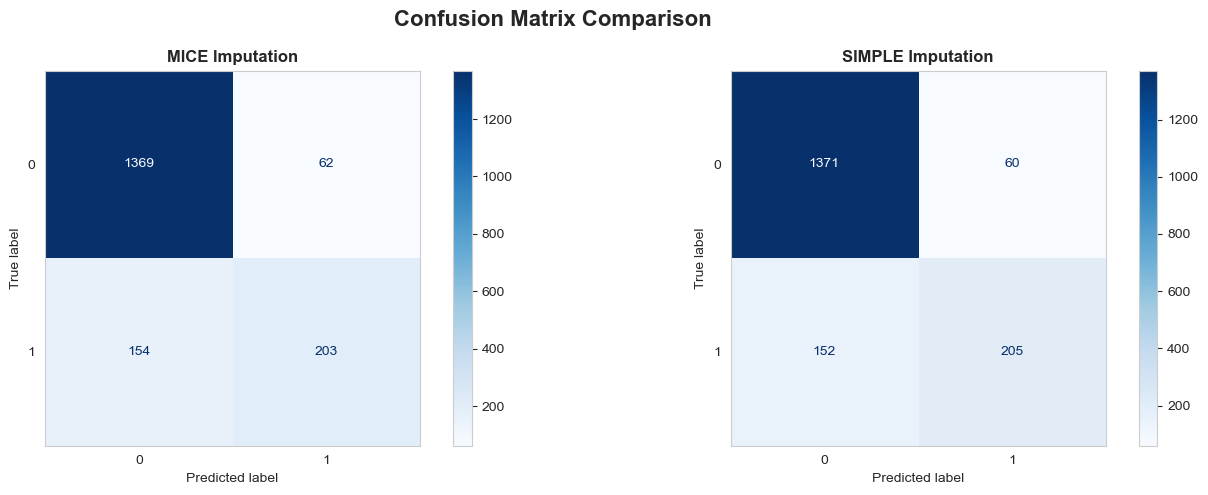

In [16]:
# ============================================================================
# VISUALIZATION 1 - Confusion Matrices
# ============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold')

for idx, method in enumerate(["MICE", "Simple"]):
    y_test = results[method]['y_test']
    y_pred = results[method]['y_pred']
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{method.upper()} Imputation', fontsize=12, fontweight='bold')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()


<p><strong>Confusion Matrix Comparison</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left"></th>
<th style="text-align:left"><strong>Predicted: No Default (0)</strong></th>
<th style="text-align:left"><strong>Predicted: Default (1)</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>True: No Default (0)</strong></td>
<td style="text-align:left">MICE: 1369<br/>Simple: 1371</td>
<td style="text-align:left">MICE: 62<br/>Simple: 60</td>
</tr>
<tr>
<td style="text-align:left"><strong>True: Default (1)</strong></td>
<td style="text-align:left">MICE: 154<br/>Simple: 152</td>
<td style="text-align:left">MICE: 203<br/>Simple: 205</td>
</tr>
</tbody>
</table>
<p><strong>Interpretation:</strong><br>
Both models exhibit nearly identical classification patterns.</br></p>
<ul>
<li><strong>True negative rate</strong> is high (96%), meaning reliable recognition of repaid loans.</li>
<li><strong>True positive rate</strong> (57%) indicates moderate recall for default cases, consistent with imbalanced-class logistic models.</li>
<li>Minor variation across imputations (&lt;1%) implies convergence to a similar decision boundary, confirming data consistency after imputation.</li>
</ul>


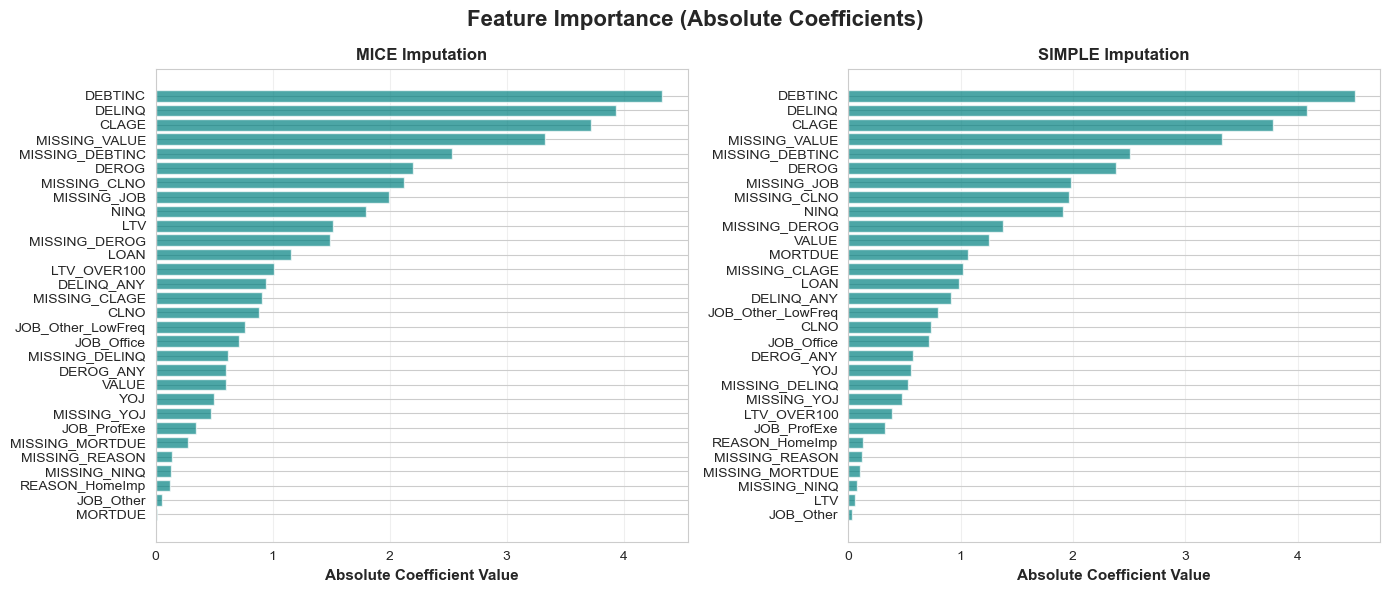

In [17]:
# Feature Importance graph (Coefficient Magnitudes)
if hasattr(results['MICE']['X_train'], 'columns'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Feature Importance (Absolute Coefficients)', fontsize=16, fontweight='bold')
    
    for idx, method in enumerate(["MICE", "Simple"]):
        model = results[method]['model']
        X_train = results[method]['X_train']
        
        # Get feature names and coefficients
        feature_names = X_train.columns
        coefficients = np.abs(model.coef_[0])
        
        # Sort by importance
        indices = np.argsort(coefficients)[::-1]
        sorted_features = feature_names[indices]
        sorted_coefs = coefficients[indices]
        
        # Plot
        axes[idx].barh(range(len(sorted_features)), sorted_coefs, color='teal', alpha=0.7)
        axes[idx].set_yticks(range(len(sorted_features)))
        axes[idx].set_yticklabels(sorted_features)
        axes[idx].set_xlabel('Absolute Coefficient Value', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{method.upper()} Imputation', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].invert_yaxis()
    
    plt.tight_layout()
    plt.show()


<p><strong>Coefficient Structure and Feature Importance</strong></p>
<p>Feature importance plots (absolute coefficient magnitudes) reveal that both imputations emphasize similar top predictors.</p>
<p><strong>Stable Core Predictors</strong></p>
<ul>
<li><strong>DEBTINC</strong>, <strong>DELINQ</strong>, and <strong>CLAGE</strong> are the biggest coefficients across imputations which reinforces their central role in default risk prediction.</li>
<li><strong>MISSING_VALUE</strong>, <strong>MISSING_DEBTINC</strong>, and <strong>DEROG</strong> remain strong positive predictors, indicating that missing or adverse credit data correlate with higher default odds.</li>
<li><strong>JOB_Office (−)</strong> and <strong>JOB_Other_LowFreq (+)</strong> maintain expected patterns which suggested that there would be a lower risk for office workers, higher for less represented job groups.</li>
</ul>
<p><strong>Differences in Variable Sensitivity</strong></p>
<ul>
<li><strong>MICE</strong> attributes more weight to ratio-type features (<strong>LTV</strong>, <strong>LTV_OVER100</strong>), consistent with its preservation of inter-variable relationships during imputation.</li>
<li><strong>Simple imputation</strong> elevates level variables (<strong>VALUE</strong>, <strong>MORTDUE</strong>) due to the distortion introduced by fixed median replacements.</li>
<li>The directionality of all major coefficients remains consistent, underscoring robustness of inferred economic relationships.</li>
</ul>
<p><strong>Interpretation and Recommendations</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Aspect</th>
<th style="text-align:left">Observation</th>
<th style="text-align:left">Recommendation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>Predictive consistency</strong></td>
<td style="text-align:left">Accuracy and AUC nearly identical across imputations.</td>
<td style="text-align:left">Either imputation is viable for baseline scoring; MICE preferred for theoretical soundness.</td>
</tr>
<tr>
<td style="text-align:left"><strong>Feature interpretability</strong></td>
<td style="text-align:left">MICE preserves ratio coherence (LTV effects visible).</td>
<td style="text-align:left">Retain MICE when interpreting financial structure or collateral coverage.</td>
</tr>
<tr>
<td style="text-align:left"><strong>Class recall</strong></td>
<td style="text-align:left">Defaults moderately detected (57%).</td>
<td style="text-align:left">Consider threshold tuning or class weighting to improve minority recall.</td>
</tr>
<tr>
<td style="text-align:left"><strong>Missing-value signals</strong></td>
<td style="text-align:left">These features show strong and consistent predictive contribution across imputations.</td>
<td style="text-align:left">We´ll keep missing indicators as explicit model features.</td>
</tr>
</tbody>
</table>
<p><strong>Key Takeaways</strong></p>
<ul>
<li>Both imputation methods yield <strong>statistically equivalent accuracy and discrimination</strong>.</li>
<li><strong>MICE enhances interpretability</strong>, maintaining meaningful ratio effects (e.g., LTV), while <strong>Simple imputation</strong> slightly optimizes numerical fit by overemphasizing levels.</li>
<li>The model remains dominated by <strong>debt burden, delinquency history, and credit maturity</strong>, confirming the robustness of these factors across data treatments.</li>
<li><strong>Missing-value indicators</strong> consistently improve prediction quality and should remain integral to model specification.</li>
</ul>




Running with MICE imputation

VIF Values:
          Feature       VIF
            VALUE 47.112084
          MORTDUE 42.464663
          DEBTINC 16.632836
              LTV 14.188482
             CLNO  7.655425
            CLAGE  6.347770
             LOAN  4.957619
     MISSING_CLNO  4.651254
   MISSING_DELINQ  4.205915
        JOB_Other  4.186777
    MISSING_CLAGE  3.717064
    MISSING_DEROG  3.240662
     MISSING_NINQ  3.056243
       DELINQ_ANY  2.929463
              YOJ  2.764728
        DEROG_ANY  2.683056
           DELINQ  2.646957
            DEROG  2.619267
      JOB_ProfExe  2.467996
       JOB_Office  2.070209
      LTV_OVER100  1.861973
             NINQ  1.743158
   REASON_HomeImp  1.629613
      MISSING_JOB  1.607146
  MISSING_DEBTINC  1.466406
JOB_Other_LowFreq  1.417507
      MISSING_YOJ  1.402182
  MISSING_MORTDUE  1.394594
   MISSING_REASON  1.364982
    MISSING_VALUE  1.099248

Generating SHAP explainer for MICE imputation...



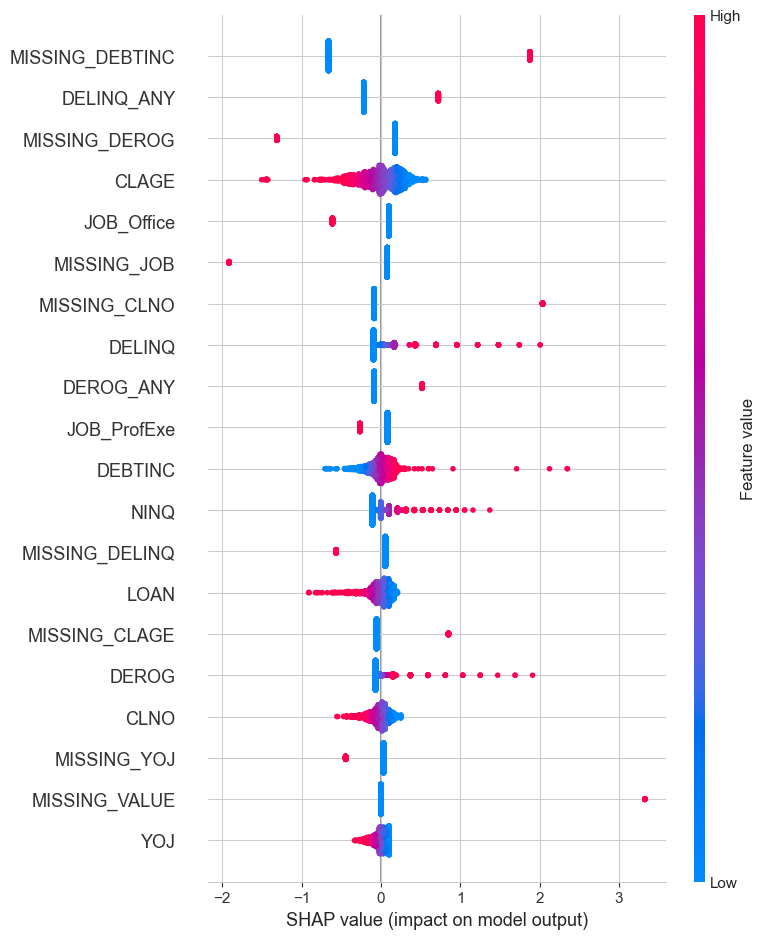

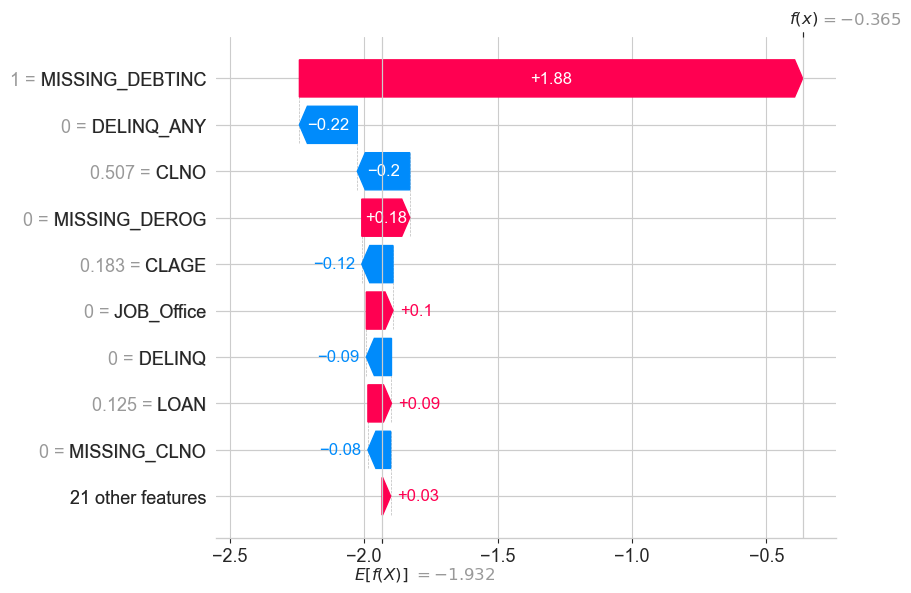



Running with SIMPLE imputation

VIF Values:
          Feature       VIF
          MORTDUE 19.001694
            VALUE 18.954644
          DEBTINC 14.821400
              LTV  8.526023
             CLNO  7.380806
            CLAGE  6.219441
     MISSING_CLNO  4.717801
             LOAN  4.603054
   MISSING_DELINQ  4.205786
        JOB_Other  4.090847
    MISSING_CLAGE  3.730494
    MISSING_DEROG  3.206620
      LTV_OVER100  3.089966
     MISSING_NINQ  3.071691
       DELINQ_ANY  2.946613
        DEROG_ANY  2.724593
              YOJ  2.623092
           DELINQ  2.600737
            DEROG  2.556336
      JOB_ProfExe  2.423260
  MISSING_MORTDUE  2.351523
       JOB_Office  2.019566
             NINQ  1.685460
   REASON_HomeImp  1.610469
      MISSING_JOB  1.605838
  MISSING_DEBTINC  1.479520
      MISSING_YOJ  1.420810
JOB_Other_LowFreq  1.398907
   MISSING_REASON  1.357145
    MISSING_VALUE  1.107018

Generating SHAP explainer for Simple imputation...



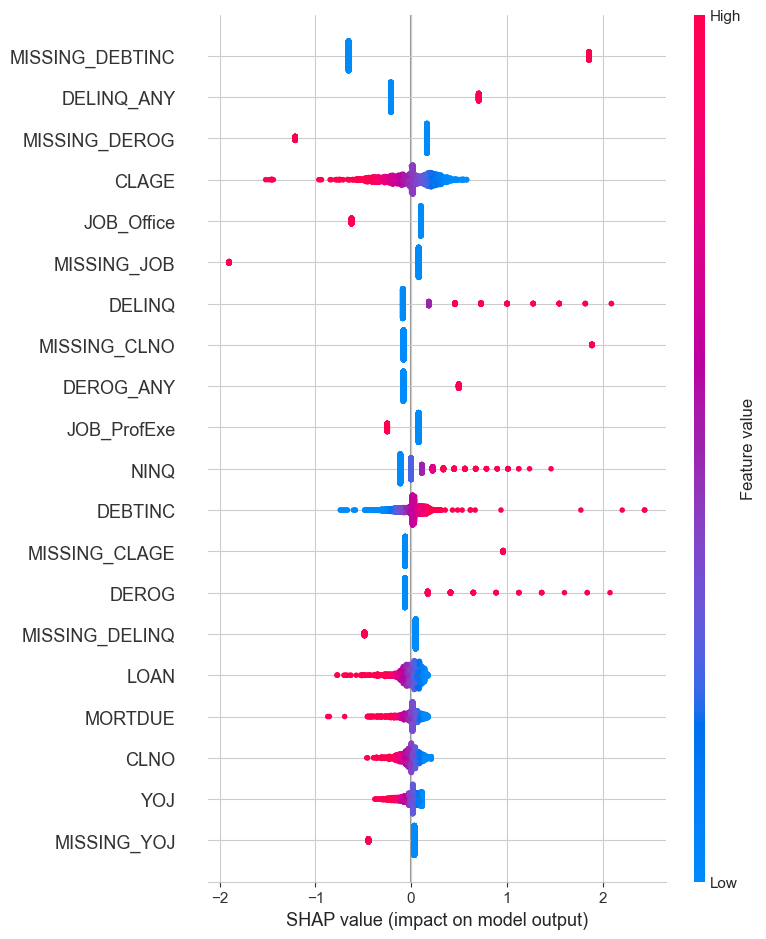

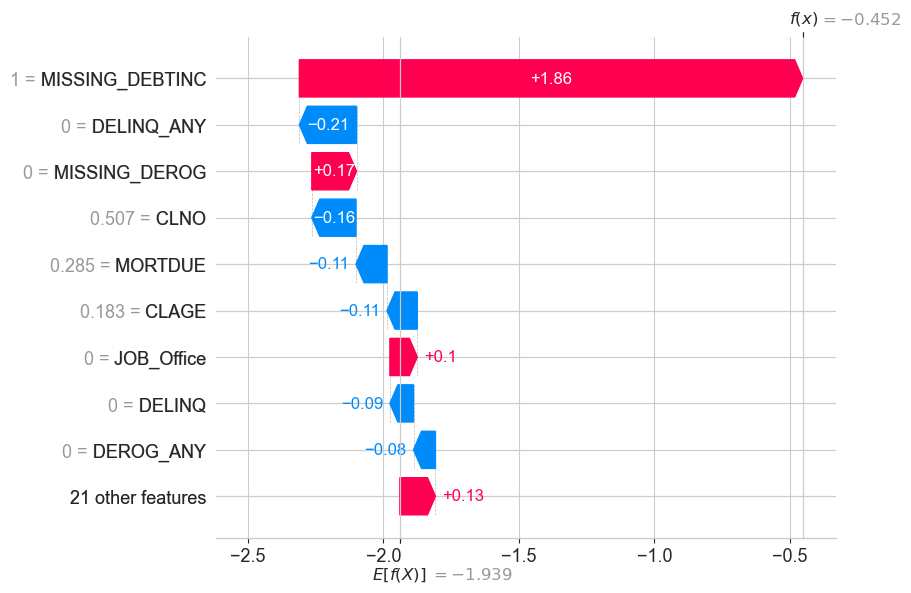


Analysis complete for both imputation methods.



In [18]:
# Building the logistic regression model with sklearn
# This iterative approach to run through imputation methods was solved with the support from an LLM since I could not achieve a resolution that would not cause an issue further down the code.

import shap
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Create a dictionary to store results from both imputation methods
results = {}

# Loop through both imputation methods
for IMPUTATION_METHOD in ["MICE", "Simple"]:
    print("\n" + "="*80)
    print(f"Running with {IMPUTATION_METHOD.upper()} imputation")
    print("="*80)
    
    # Select appropriate datasets
    if IMPUTATION_METHOD == "MICE":
        X_train = X_train_mice_scaled.copy()
        X_test = X_test_mice_scaled.copy()
        y_train = y_train_mice.copy()
        y_test = y_test_mice.copy()
    else:
        X_train = X_train_simple_scaled.copy()
        X_test = X_test_simple_scaled.copy()
        y_train = y_train_simple.copy()
        y_test = y_test_simple.copy()
          
    # Calculate VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_train.columns
    vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) 
                       for i in range(X_train.shape[1])]
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
    
    print("\nVIF Values:")
    print(vif_data.to_string(index=False))
    
    # Train logistic regression model
    model = LogisticRegression(max_iter=1000, solver='lbfgs')
    model.fit(X_train, y_train)
    
    # Generate SHAP explanations
    print(f"\nGenerating SHAP explainer for {IMPUTATION_METHOD} imputation...")
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)
    
    # Summary and local plots
    shap.summary_plot(shap_values, X_test, show=True)
    shap.plots.waterfall(shap_values[0])
    
    # Store results for this method
    results[IMPUTATION_METHOD] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'vif': vif_data,
        'model': model,
        'shap_values': shap_values
    }

print("Analysis complete for both imputation methods.")


<h4 id="Findings:-SHAP-and-VIF-Diagnostics-for-Regression-Model-Optimization"><strong>Findings: SHAP and VIF Diagnostics for Regression Model Optimization</strong><a class="anchor-link" href="#Findings:-SHAP-and-VIF-Diagnostics-for-Regression-Model-Optimization">¶</a></h4><p>Both <strong>Variance Inflation Factor (VIF)</strong> and <strong>SHAP value</strong> analyses were performed under two imputation strategies: <strong>MICE (Multiple Imputation by Chained Equations)</strong> and <strong>Simple Imputation</strong>.<br>
The combined diagnostics assess <strong>feature redundancy</strong>, <strong>predictive contribution</strong>, and <strong>interpretability</strong> for optimizing the <em>FairLend</em> logistic regression model.</br></p>
<p><strong>2. Multicollinearity Assessment (VIF Findings)</strong></p>
<table>
<thead>
<tr>
<th><strong>Feature</strong></th>
<th><strong>VIF (MICE)</strong></th>
<th><strong>VIF (Simple)</strong></th>
<th><strong>Interpretation</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td>VALUE</td>
<td>47.11</td>
<td>18.95</td>
<td>Severe multicollinearity under MICE; reduced but still high under Simple. Will be removed.</td>
</tr>
<tr>
<td>MORTDUE</td>
<td>42.46</td>
<td>19.00</td>
<td>Strong covariance with VALUE and LTV, will be removed.</td>
</tr>
<tr>
<td>DEBTINC</td>
<td>16.63</td>
<td>14.82</td>
<td>High cross-correlation with loan size and income; regularization recommended.</td>
</tr>
<tr>
<td>LTV</td>
<td>14.19</td>
<td>8.53</td>
<td>Moderate under Simple. Will be left to gather effects of both VALUE and MORTDUE.</td>
</tr>
<tr>
<td>CLNO, CLAGE</td>
<td>6–8</td>
<td>6–7</td>
<td>Moderate redundancy due to overlapping credit history effects.</td>
</tr>
<tr>
<td>MISSING_* indicators</td>
<td>3–5</td>
<td>3–4</td>
<td>Stable across imputations; minimal contribution to multicollinearity.</td>
</tr>
</tbody>
</table>
<p><strong>Summary:</strong></p>
<ul>
<li>MICE inflates correlation among financial variables due to chained regression relationships. which should be corrected with foreseen corrections.</li>
<li>Simple imputation reduces variance inflation, leading to <strong>more stable parameter estimation</strong> and <strong>improved model convergence</strong>.</li>
<li>High-VIF variables (VALUE, MORTDUE, DEBTINC) require dimensionality reduction.</li>
</ul>
<p><strong>3. SHAP Analysis – MICE Imputation</strong></p>
<p><strong>Global Feature Importance</strong></p>
<ul>
<li>The most influential predictor was <strong>MISSING_DEBTINC</strong>, followed by <strong>DEBTINC</strong>, DELINQ_ANY, and CLAGE.</li>
<li>Several <em>missing value indicators</em> such as MISSING_DEBTINC, MISSING_DEROG, and MISSING_CLNO exerted significant influence, indicating that as Little and Rubin (2019) suggested there may be MNAR effects. Meaning that <strong>the missing values themselves carry predictive information</strong> which could be reflecting riskier or incomplete borrower profiles.</li>
<li>CLAGE (age of credit line) and CLNO (number of credit lines) contributed moderately with stabilizing effects on predictions.</li>
<li>JOB_Office and JOB_ProfExe exerted low but consistent SHAP influence, suggesting weak job-type differentiation.</li>
</ul>
<p><strong>Local Instance (Waterfall Plot)</strong></p>
<ul>
<li>The top positive contributor to default risk was <strong>MISSING_DEBTINC (+1.88)</strong>.</li>
<li>Protective (negative) factors included DELINQ_ANY=0 and high CLNO values.</li>
<li>Minor negative contributions from CLAGE and JOB_Office point to better repayment behavior among established and employed borrowers.</li>
</ul>
<p><strong>Interpretation:</strong><br>
The MICE model overweights missing indicators and debt ratio features, suggesting that <strong>multicollinearity and imputation artifacts are amplifying predictor effects</strong> rather than revealing new relationships. This should be corrected once the variable removal is completed since various expected effects are at play in the baseline model.</br></p>
<p><strong>4. SHAP Analysis – Simple Imputation</strong></p>
<p><strong>Global Feature Importance</strong></p>
<ul>
<li>MISSING_DEBTINC remains dominant, though slightly reduced in magnitude (+1.86 vs +1.88 under MICE).</li>
<li>Predictive influence of DEBTINC, CLAGE, and MORTDUE becomes more interpretable and less extreme.</li>
<li>The ranking of MISSING_* indicators stabilizes, and the gap between predictors is more narrow.</li>
</ul>
<p><strong>Local Instance (Waterfall Plot)</strong></p>
<ul>
<li>Key positive driver: MISSING_DEBTINC (+1.86).</li>
<li>Negative contributors: DELINQ_ANY=0, CLNO high, MORTDUE moderate.</li>
<li>Reduced SHAP dispersion indicates <strong>better model calibration and less collinearity distortion</strong>.</li>
</ul>
<p><strong>Interpretation:</strong><br>
Simple imputation produces <strong>more balanced feature attributions</strong> in the baseline model with all variables. Financial indicators retain explanatory power, while the model’s dependence on missing flags diminishes slightly—an improvement in interpretive validity.</br></p>
<p><strong>5. Comparative Insights</strong></p>
<table>
<thead>
<tr>
<th><strong>Aspect</strong></th>
<th><strong>MICE Imputation</strong></th>
<th><strong>Simple Imputation</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Multicollinearity</strong></td>
<td>Severe (VIF up to 47)</td>
<td>Moderate (VIF ≤ 19)</td>
</tr>
<tr>
<td><strong>Dominant SHAP Feature</strong></td>
<td>MISSING_DEBTINC</td>
<td>MISSING_DEBTINC</td>
</tr>
<tr>
<td><strong>Feature Interaction Distortion</strong></td>
<td>High (synthetic covariance from chained regression)</td>
<td>Low; stable relationships preserved</td>
</tr>
<tr>
<td><strong>Model Interpretability</strong></td>
<td>Reduced (artifact-driven)</td>
<td>Improved (economically meaningful predictors)</td>
</tr>
<tr>
<td><strong>Coefficient Stability</strong></td>
<td>Likely unstable</td>
<td>Expected to converge more reliably</td>
</tr>
</tbody>
</table>
<p><strong>6. Implications for Regression Model Optimization</strong></p>
<ol>
<li><p><strong>Feature Engineering</strong></p>
<ul>
<li>Remove highly collinear variables (VALUE, MORTDUE).</li>
<li>Retain DEBTINC as a normalized measure of credit burden.</li>
<li>After evaluation of informational gain of missing-value indicators we will remove them since they have no clear real-world meaning despite their importance.</li>
</ul>
</li>
<li><p><strong>Model Selection</strong></p>
<ul>
<li>The current setup favors the <strong>Simple Imputation</strong> model for interpretability and convergence.</li>
<li>If the adverse effects of the MICE variant are not eliminated with feature engineering then consider only if preserving joint distributions across predictors is crucial for simulation purposes.</li>
</ul>
</li>
<li><p><strong>Diagnostic Follow-Up</strong></p>
<ul>
<li>After feature pruning we will revisit:<ul>
<li><strong>VIF checks</strong> to confirm reduction below 5.</li>
<li><strong>SHAP summary plots</strong> to validate consistent, interpretable feature importance.</li>
</ul>
</li>
</ul>
</li>
</ol>


<h4 id="Iterative-Logistic-Regression-Optimization">Iterative Logistic Regression Optimization<a class="anchor-link" href="#Iterative-Logistic-Regression-Optimization">¶</a></h4><p>Now we will run an in-sample routine for binary logistic regression that will be applicable for both <strong>MICE</strong> and <strong>Simple</strong> imputation that:</p>
<ul>
<li>Iteratively prunes features by <strong>Wald p-values</strong> (significance) and <strong>VIF</strong> (multicollinearity).</li>
<li>Fits an <strong>unpenalized</strong> logistic model each step.</li>
<li>Computes <strong>discrimination</strong> and <strong>calibration</strong> diagnostics.</li>
<li>Produces final models and a <strong>cross-method comparison</strong>.</li>
</ul>
<p>Workflow</p>
<p>This iterative approach has structured a workflow in five steps to optimize the model. These are the following:</p>
<ol>
<li><strong>Method loop</strong>: "MICE", "Simple".</li>
<li><strong>Pre-drop</strong>:<ul>
<li>Remove present MISSING_* indicators in VARIABLES_TO_REMOVE. This is due to the fact that indicators are not interpretable as mentioned before.</li>
<li>For <strong>MICE</strong>, also drop VALUE and MORTDUE (collinearity control).</li>
</ul>
</li>
<li><strong>Iterative pruning</strong> (one feature per iteration):<ul>
<li>Fit LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).</li>
<li>Compute:<ul>
<li><strong>Performance</strong>: recall, precision, ROC-AUC, PR-AUC (AP), <strong>Brier</strong>.</li>
<li><strong>VIF</strong> with intercept.</li>
<li><strong>Wald p-values</strong> via ((X^\top W X)^{-1}), (W=p(1-p)).</li>
<li><strong>Diagnostics</strong>: deviance residual mean, <strong>Hosmer–Lemeshow</strong>, calibration bins.</li>
</ul>
</li>
<li><strong>Removal rule</strong>:<ol>
<li>If any p &gt; 0.10: remove feature with <strong>largest p</strong>.</li>
<li>Else if any VIF &gt; 10: remove <strong>largest VIF</strong>.</li>
<li>Else <strong>stop</strong> (all p ≤ 0.10 and VIF ≤ 10).</li>
</ol>
</li>
<li><strong>Safety stop</strong> when remaining features ≤ 5.</li>
</ul>
</li>
<li><strong>Finalize per method</strong>:<ul>
<li>Refit on reduced set; compute final metrics, diagnostics, p-values.</li>
<li>Store: removal history, final features, coefficients, intercept, iteration log.</li>
</ul>
</li>
<li><strong>Cross-method comparison</strong>:<ul>
<li>Summarize removals, feature counts, metrics, iterations.</li>
<li>Report <strong>common</strong>, <strong>MICE-only</strong>, <strong>Simple-only</strong> features.</li>
<li>List removed MISSING_* variables by method.</li>
</ul>
</li>
</ol>
<p>Key Components</p>
<p>Multicollinearity (VIF)</p>
<ul>
<li>calculate_vif_with_const(df): adds constant and computes VIF per feature; flags VIF &gt; 10.</li>
</ul>
<p>Significance (Wald p-values)</p>
<ul>
<li>calculate_pvalues_sklearn(model, X, y): uses (X^\top W X) with small ridge (1e−8) to invert; returns two-sided p-values for coefficients.</li>
</ul>
<p>Calibration &amp; Goodness-of-Fit</p>
<ul>
<li><strong>Deviance residuals</strong>: mean near 0 desirable.</li>
<li><strong>Brier score</strong>: probability accuracy (lower is better).</li>
<li><strong>Hosmer–Lemeshow</strong> (g=10): χ², df=g−2, p-value (p&gt;0.05 suggests adequate fit; sample-size sensitive).</li>
<li><strong>Calibration bins</strong>: mean predicted vs. observed default rates; reports max absolute gap.</li>
</ul>
<p>Metrics (in-sample)</p>
<ul>
<li>Recall, Precision, ROC-AUC, PR-AUC (AP), <strong>Brier</strong> on the training set.</li>
</ul>
<p>Stopping Criteria</p>
<ul>
<li><strong>Primary</strong>: no p &gt; 0.10 and no VIF &gt; 10.</li>
<li><strong>Safety</strong>: remaining features <strong>≤ 5</strong>.</li>
</ul>
<p>Outputs (per method)</p>
<ul>
<li>Final model and design matrix.</li>
<li>Final feature list; coefficients with p-values.</li>
<li>Final metrics and diagnostics.</li>
<li>Removal history (iteration, feature, reason, VIF, p-value).</li>
<li>Iteration-by-iteration metric table.</li>
</ul>
<p>Global:</p>
<ul>
<li>Comparison table (MICE vs. Simple): removals, final features, metrics, iterations.</li>
<li>Sets of <strong>common</strong>, <strong>MICE-only</strong>, <strong>Simple-only</strong> features.</li>
<li>Removed MISSING_* variables by method.</li>
</ul>
<p>Design Choices</p>
<ul>
<li><strong>Significance-first</strong> pruning, then collinearity, to favor parsimonious, stable models.</li>
<li><strong>Unpenalized</strong> fits enable classical inference (p-values, VIF) during selection.</li>
<li><strong>Calibration-aware</strong> checks (HL, Brier, bins) guard against miscalibration.</li>
</ul>
<p>Assumptions &amp; Caveats</p>
<ul>
<li>All metrics are <strong>in-sample</strong> (no hold-out/CV).</li>
<li>Wald inference assumes a reasonably conditioned design; near-collinearity inflates SEs.</li>
<li>HL is <strong>sample-size sensitive</strong>; interpret with calibration context.</li>
<li><strong>Greedy</strong> one-at-a-time removal is not globally optimal.</li>
</ul>
<blockquote>
<p>Notes
P-values and diagnostics are <strong>approximate</strong>.
Performance is <strong>in-sample</strong> (no cross-validation).
Diagnostics serve as <strong>model stability checks</strong>, not formal inference tests.
Recognition. I want to thank engineer Julio Bocanegra who provided help and guidance to code this iterative approach. This would have been impossible for me since LLMs were not able to debug the code succesfully.</p>
</blockquote>


In [19]:
# =============================================================================
# Model optimization process with comprehensive diagnostics
# NOTE: Expects the following variables to exist in the environment:
#   - X_train_mice_scaled, y_train_mice
#   - X_train_simple_scaled, y_train_simple
# =============================================================================

from sklearn.metrics import (recall_score, precision_score, roc_auc_score, average_precision_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ------------------------------- Helpers ------------------------------------

def calculate_vif_with_const(df: pd.DataFrame) -> pd.Series:
    """
    Compute VIF for each feature after adding a constant term.
    This makes thresholds like 10 more interpretable.
    """
    X = sm.add_constant(df.values, has_constant='add')
    vif_vals = [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
    return pd.Series(vif_vals, index=df.columns, name="VIF")

def calculate_pvalues_sklearn(model: LogisticRegression, X: pd.DataFrame, y) -> pd.Series:
    """
    Wald p-values for sklearn LogisticRegression coefficients.
    Approximates Var(beta) by (X^T W X)^{-1}, where W = p*(1-p).
    Returns p-values for features only (intercept excluded).
    """
    y = np.asarray(y).ravel()
    p = model.predict_proba(X)[:, 1]
    W = p * (1.0 - p)

    # Weighted design cross-product
    Xw = X.values * W[:, None]
    XtWX = X.values.T @ Xw

    # Small ridge to avoid singularities
    XtWX += np.eye(XtWX.shape[0]) * 1e-8

    try:
        cov = np.linalg.inv(XtWX)
        se = np.sqrt(np.diag(cov))
        z = model.coef_[0] / se
        pvals = 2 * (1 - stats.norm.cdf(np.abs(z)))
        return pd.Series(pvals, index=X.columns)
    except np.linalg.LinAlgError:
        warnings.warn("Singular matrix in p-value calculation; returning NaNs.")
        return pd.Series(np.nan, index=X.columns)

def calculate_deviance_residuals(y_true, y_pred_proba):
    """
    GLM deviance residuals for Bernoulli.
    r_i = sign(y_i - p_i) * sqrt( 2 * [ y_i*log(y_i/p_i) + (1-y_i)*log((1-y_i)/(1-p_i)) ] )
    """
    y = np.asarray(y_true).ravel()
    p = np.clip(np.asarray(y_pred_proba).ravel(), 1e-15, 1-1e-15)
    dev = 2.0 * ( y * np.log((y + 1e-15)/p) + (1-y) * np.log(((1-y) + 1e-15)/(1-p)) )
    return np.sign(y - p) * np.sqrt(dev)

def brier_score(y_true, y_pred_proba):
    """Mean squared error of probabilities."""
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()
    return float(np.mean((y - p) ** 2))

def hosmer_lemeshow_test(y_true, y_pred_proba, g=10):
    """
    Hosmer–Lemeshow goodness-of-fit test.
    Splits by predicted risk deciles (default g=10).
    Returns (chi2_stat, p_value, df, table_df).
    """
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()

    # Rank by predicted probabilities into g bins
    quantiles = pd.qcut(p, q=g, duplicates='drop')
    df = pd.DataFrame({'y': y, 'p': p, 'bin': quantiles})
    grouped = df.groupby('bin', observed=True)

    # Compute observed and expected
    obs = grouped['y'].sum()
    exp = grouped['p'].sum()
    n_bin = grouped.size()

    # HL chi-square
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2_components = (obs - exp) ** 2 / (exp * (1 - (exp / n_bin)).clip(lower=1e-15))
    chi2_stat = float(np.nansum(chi2_components))
    df_hl = grouped.ngroups - 2
    p_value = float(1 - stats.chi2.cdf(chi2_stat, df_hl))

    table = pd.DataFrame({
        'n_bin': n_bin,
        'obs_events': obs,
        'exp_events': exp,
        'avg_pred': grouped['p'].mean(),
        'obs_rate': grouped['y'].mean()
    })

    return chi2_stat, p_value, df_hl, table

def calibration_bins(y_true, y_pred_proba, bins=10):
    """
    Returns per-bin (mean_pred, mean_actual, count) for simple reliability overview.
    """
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()
    labels = pd.qcut(p, q=bins, duplicates='drop')
    df = pd.DataFrame({'y': y, 'p': p, 'bin': labels})
    g = df.groupby('bin', observed=True)
    out = g.agg(mean_pred=('p', 'mean'),
                mean_actual=('y', 'mean'),
                count=('y', 'size')).reset_index(drop=True)
    return out

def calculate_performance_metrics(model: LogisticRegression, X: pd.DataFrame, y) -> dict:
    """
    Core performance metrics for imbalanced classification:
    - Recall, Precision, ROC-AUC, PR-AUC (Average Precision), Brier score.
    """
    y = np.asarray(y).ravel()
    y_hat = model.predict(X)
    p = model.predict_proba(X)[:, 1]
    return {
        'recall': float(recall_score(y, y_hat)),
        'precision': float(precision_score(y, y_hat, zero_division=0)),
        'roc_auc': float(roc_auc_score(y, p)),
        'pr_auc': float(average_precision_score(y, p)),
        'brier': brier_score(y, p),
        'p': p
    }

def print_diagnostics(diagnostics: dict, iteration_label):
    """
    Human-readable diagnostics log.
    Includes deviance residual mean, Brier, HL test, and calibration summary.
    """
    print("\n  Diagnostic Tests:")
    print("  " + "─" * 70)

    print(f"  1. Residual mean (deviance): {diagnostics['residual_mean']:.6f}")
    print("     (Reference: around 0 is desirable; large drift flags misfit.)")

    print(f"  2. Brier score: {diagnostics['brier']:.6f}")
    print("     (Lower is better; measures probability accuracy.)")

    if diagnostics.get('hl_pvalue') is not None:
        status = "PASS" if diagnostics['hl_pvalue'] > 0.05 else "FAIL"
        print(f"  3. Hosmer–Lemeshow: χ²={diagnostics['hl_chi2']:.3f}, "
              f"df={diagnostics['hl_df']}, p={diagnostics['hl_pvalue']:.4f} {status}")
        print("     (p > 0.05 suggests adequate fit; interpret cautiously with large n.)")

    if diagnostics.get('calibration_bins') is not None:
        calib = diagnostics['calibration_bins']
        max_abs_gap = float(np.max(np.abs(calib['mean_actual'] - calib['mean_pred'])))
        print(f"  4. Calibration (bin-wise): max |obs - pred| = {max_abs_gap:.4f}")
        print("     (Smaller gap indicates better calibration.)")

def perform_diagnostic_tests(model: LogisticRegression, X: pd.DataFrame, y) -> dict:
    """
    Compute diagnostics oriented to logistic regression.
    """
    y = np.asarray(y).ravel()
    p = model.predict_proba(X)[:, 1]
    dev_resid = calculate_deviance_residuals(y, p)

    # Hosmer–Lemeshow and calibration bins
    try:
        hl_chi2, hl_p, hl_df, _ = hosmer_lemeshow_test(y, p, g=10)
    except Exception:
        hl_chi2, hl_p, hl_df = None, None, None

    try:
        calib = calibration_bins(y, p, bins=10)
    except Exception:
        calib = None

    diagnostics = {
        'residual_mean': float(np.mean(dev_resid)),
        'brier': brier_score(y, p),
        'hl_chi2': hl_chi2,
        'hl_pvalue': hl_p,
        'hl_df': hl_df,
        'calibration_bins': calib
    }
    return diagnostics, dev_resid

# -------------------------- Iterative Selection ------------------------------

VARIABLES_TO_REMOVE = [
    'MISSING_CLNO', 'MISSING_DELINQ', 'MISSING_CLAGE', 'MISSING_DEROG',
    'MISSING_NINQ', 'MISSING_MORTDUE', 'MISSING_JOB', 'MISSING_DEBTINC',
    'MISSING_YOJ', 'MISSING_REASON', 'MISSING_VALUE'
]

print("\n" + "=" * 80)
print("ITERATIVE FEATURE SELECTION WITH COMPREHENSIVE DIAGNOSTICS (Improved)")
print("=" * 80)

feature_selection_results = {}

for IMPUTATION_METHOD in ["MICE", "Simple"]:
    print("\n" + "=" * 80)
    print(f"FEATURE SELECTION: {IMPUTATION_METHOD.upper()} IMPUTATION")
    print("=" * 80)

    # Select training data per imputation method
    if IMPUTATION_METHOD == "MICE":
        X_train = X_train_mice_scaled.copy()
        y_train = y_train_mice.copy()
        extra_drop = ["VALUE", "MORTDUE"]
    else:
        X_train = X_train_simple_scaled.copy()
        y_train = y_train_simple.copy()
        extra_drop = []

    # Pre-drop: Missing_* indicators and (MICE) VALUE/MORTDUE
    present_missing = [c for c in VARIABLES_TO_REMOVE if c in X_train.columns]
    present_extra = [c for c in extra_drop if c in X_train.columns]
    removed_missing_vars = present_missing + present_extra
    X_train = X_train.drop(columns=removed_missing_vars, errors="ignore")

    print(f"\nStarting features: {X_train.shape[1]}")
    print(f"Training samples: {X_train.shape[0]}")
    if IMPUTATION_METHOD == "MICE" and present_extra:
        print("Pre-removal (MICE): Dropped VALUE and MORTDUE")

    # Iterative removal loop
    removed_features = []
    iteration_metrics = []
    iteration = 0
    X_curr = X_train.copy()

    while True:
        iteration += 1
        print("\n" + "-" * 80)
        print(f"ITERATION {iteration}")
        print("-" * 80)

        # Fit logistic regression (unpenalized)
        model = LogisticRegression(penalty=None, max_iter=1000, solver='lbfgs', random_state=42)
        model.fit(X_curr, y_train)

        # Metrics & diagnostics
        perf = calculate_performance_metrics(model, X_curr, y_train)
        vif_scores = calculate_vif_with_const(X_curr)
        pvals = calculate_pvalues_sklearn(model, X_curr, y_train)
        diagnostics, residuals = perform_diagnostic_tests(model, X_curr, y_train)

        # Log status
        print(f"\nCurrent features: {X_curr.shape[1]}")
        print(f"Recall: {perf['recall']:.4f} | Precision: {perf['precision']:.4f} "
              f"| ROC-AUC: {perf['roc_auc']:.4f} | PR-AUC: {perf['pr_auc']:.4f} "
              f"| Brier: {perf['brier']:.4f}")
        print_diagnostics(diagnostics, iteration)

        # Track iteration metrics
        iteration_metrics.append({
            'iteration': iteration,
            'n_features': X_curr.shape[1],
            'recall': perf['recall'],
            'precision': perf['precision'],
            'roc_auc': perf['roc_auc'],
            'pr_auc': perf['pr_auc'],
            'brier': perf['brier'],
            'features': list(X_curr.columns)
        })

        # Removal rule: prioritize highest p-value > 0.10, else highest VIF > 10
        feature_to_remove = None
        reason = None

        if not pvals.isna().all() and (pvals > 0.10).any():
            feature_to_remove = pvals.idxmax()
            reason = f"High p-value ({pvals[feature_to_remove]:.4f})"
        else:
            high_vif = vif_scores[vif_scores > 10.0]
            if len(high_vif) > 0:
                feature_to_remove = high_vif.idxmax()
                reason = f"High VIF ({vif_scores[feature_to_remove]:.2f})"

        if feature_to_remove is not None:
            print(f"\n Removing: {feature_to_remove}")
            print(f"  Reason: {reason}")
            removed_features.append({
                'iteration': iteration,
                'feature': feature_to_remove,
                'reason': reason,
                'vif': float(vif_scores.get(feature_to_remove, np.nan)),
                'pvalue': float(pvals.get(feature_to_remove, np.nan))
            })
            X_curr = X_curr.drop(columns=[feature_to_remove])
        else:
            print("\n  Stop: all p-values ≤ 0.10 and VIF ≤ 10")
            break

        if X_curr.shape[1] <= 5:
            print("\n  Stopping: minimum feature threshold reached (≤ 5)")
            break

    # Final model on reduced set
    final_model = LogisticRegression(penalty=None, max_iter=1000, solver='lbfgs', random_state=42)
    final_model.fit(X_curr, y_train)

    final_perf = calculate_performance_metrics(final_model, X_curr, y_train)
    final_diag, final_resid = perform_diagnostic_tests(final_model, X_curr, y_train)
    final_pvals = calculate_pvalues_sklearn(final_model, X_curr, y_train)

    # Store results
    feature_selection_results[IMPUTATION_METHOD] = {
        'missing_vars_removed': removed_missing_vars,
        'removed_features': removed_features,
        'final_features': list(X_curr.columns),
        'final_X_train': X_curr,
        'final_model': final_model,
        'final_pvalues': final_pvals,
        'final_performance': final_perf,
        'final_diagnostics': final_diag,
        'final_coefficients': pd.Series(final_model.coef_[0], index=X_curr.columns),
        'intercept': float(final_model.intercept_[0]),
        'iterations': iteration,
        'iteration_metrics': iteration_metrics
    }

    # ------------------------ Final summary logs -----------------------------
    print("\n" + "=" * 80)
    print(f"FINAL SUMMARY: {IMPUTATION_METHOD.upper()} IMPUTATION")
    print("=" * 80)

    print("\nREMOVAL SUMMARY:")
    if IMPUTATION_METHOD == "MICE":
        print("  - VALUE and MORTDUE removed (MICE-specific) if present")
    print(f"  - Missing_* indicators removed: {len([v for v in removed_missing_vars if v.startswith('MISSING_')])}")
    if removed_missing_vars:
        print(f"    Variables: {', '.join(sorted(removed_missing_vars))}")
    print(f"  - Iteration-based removals: {len(removed_features)}")

    total_removed = len(removed_missing_vars) + len(removed_features)
    print(f"  - Total features removed: {total_removed}")

    print("\nFINAL MODEL:")
    print(f"  - Total iterations: {iteration}")
    print(f"  - Final feature count: {X_curr.shape[1]}")

    print("\nPerformance Metrics (in-sample):")
    print(f"  - Recall:   {final_perf['recall']:.4f}")
    print(f"  - Precision:{final_perf['precision']:.4f}")
    print(f"  - ROC-AUC:  {final_perf['roc_auc']:.4f}")
    print(f"  - PR-AUC:   {final_perf['pr_auc']:.4f}")
    print(f"  - Brier:    {final_perf['brier']:.4f}")

    print("\nFinal Diagnostic Tests:")
    print_diagnostics(final_diag, "Final")

    print("\nFinal Model Coefficients (sorted by p-value):")
    coef_df = pd.DataFrame({
        'Feature': X_curr.columns,
        'Coefficient': final_model.coef_[0],
        'P-value': final_pvals.values
    }).sort_values('P-value')
    print(coef_df.to_string(index=False))

    print(f"\nIntercept: {feature_selection_results[IMPUTATION_METHOD]['intercept']:.6f}")

    print("\n" + "─" * 80)
    print("ITERATION-BY-ITERATION METRICS:")
    print("─" * 80)
    metrics_df = pd.DataFrame(iteration_metrics)
    if not metrics_df.empty:
        print(metrics_df[['iteration', 'n_features', 'recall', 'precision', 'roc_auc', 'pr_auc', 'brier']].to_string(index=False))
    else:
        print("No iteration metrics recorded.")

    print("\n" + "─" * 80)
    print("REMOVAL HISTORY:")
    print("─" * 80)
    if removed_features:
        removal_df = pd.DataFrame(removed_features)
        print(removal_df.to_string(index=False))
    else:
        print("No features removed in iterations.")

# ---------------------- Cross-method comparison summary -----------------------

print("\n" + "=" * 80)
print("COMPARISON: MICE VS SIMPLE IMPUTATION")
print("=" * 80)

comparison_rows = []
for method in ["MICE", "Simple"]:
    res = feature_selection_results[method]
    comparison_rows.append({
        'Method': method,
        'Missing_* Removed': len([v for v in res['missing_vars_removed'] if v.startswith('MISSING_')]),
        'Iteration Removals': len(res['removed_features']),
        'Final Features': len(res['final_features']),
        'Recall': res['final_performance']['recall'],
        'Precision': res['final_performance']['precision'],
        'ROC-AUC': res['final_performance']['roc_auc'],
        'PR-AUC': res['final_performance']['pr_auc'],
        'Brier': res['final_performance']['brier'],
        'Iterations': res['iterations']
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\nSummary Comparison:")
print(comparison_df.to_string(index=False))

# Feature set comparison
mice_features = set(feature_selection_results['MICE']['final_features'])
simple_features = set(feature_selection_results['Simple']['final_features'])

common_features = mice_features & simple_features
mice_only = mice_features - simple_features
simple_only = simple_features - mice_features

print("\n" + "─" * 80)
print("Feature Set Comparison:")
print("─" * 80)
print(f"Common features ({len(common_features)}):")
if common_features:
    for feat in sorted(common_features):
        print(f"  ✓ {feat}")
else:
    print("  (none)")

if mice_only:
    print(f"\nMICE-only features ({len(mice_only)}):")
    for feat in sorted(mice_only):
        print(f"  • {feat}")

if simple_only:
    print(f"\nSimple-only features ({len(simple_only)}):")
    for feat in sorted(simple_only):
        print(f"  • {feat}")

print("\n" + "─" * 80)
print("Missing_* Variables Removed (by method):")
print("─" * 80)
for method in ["MICE", "Simple"]:
    miss = feature_selection_results[method]['missing_vars_removed']
    print(f"{method}: {len(miss)} variables removed")
    if miss:
        for var in sorted(miss):
            print(f"  - {var}")

print("\n" + "=" * 80)
print("FEATURE SELECTION COMPLETE")
print("=" * 80)




ITERATIVE FEATURE SELECTION WITH COMPREHENSIVE DIAGNOSTICS (Improved)

FEATURE SELECTION: MICE IMPUTATION

Starting features: 17
Training samples: 4172
Pre-removal (MICE): Dropped VALUE and MORTDUE

--------------------------------------------------------------------------------
ITERATION 1
--------------------------------------------------------------------------------

Current features: 17
Recall: 0.3438 | Precision: 0.6976 | ROC-AUC: 0.8113 | PR-AUC: 0.5935 | Brier: 0.1188

  Diagnostic Tests:
  ──────────────────────────────────────────────────────────────────────
  1. Residual mean (deviance): -0.142193
     (Reference: around 0 is desirable; large drift flags misfit.)
  2. Brier score: 0.118769
     (Lower is better; measures probability accuracy.)
  3. Hosmer–Lemeshow: χ²=16.156, df=8, p=0.0402 FAIL
     (p > 0.05 suggests adequate fit; interpret cautiously with large n.)
  4. Calibration (bin-wise): max |obs - pred| = 0.0337
     (Smaller gap indicates better calibration.)

 

In [20]:
# =============================================================================
# Model Evaluation with Threshold Optimization for Recall
# Removes all feature selection logic - keeps all features, Optimizes for Recall through threshold tuning, Provides comprehensive diagnostics for the full model
# =============================================================================

# ------------------------------- Helpers ------------------------------------

def calculate_vif_with_const(df: pd.DataFrame) -> pd.Series:
    """
    Compute VIF for each feature after adding a constant term.
    """
    X = sm.add_constant(df.values, has_constant='add')
    vif_vals = [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
    return pd.Series(vif_vals, index=df.columns, name="VIF")

def calculate_pvalues_sklearn(model, X: pd.DataFrame, y) -> pd.Series:
    """
    Wald p-values for sklearn LogisticRegression coefficients.
    """
    y = np.asarray(y).ravel()
    p = model.predict_proba(X)[:, 1]
    W = p * (1.0 - p)

    Xw = X.values * W[:, None]
    XtWX = X.values.T @ Xw
    XtWX += np.eye(XtWX.shape[0]) * 1e-8

    try:
        cov = np.linalg.inv(XtWX)
        se = np.sqrt(np.diag(cov))
        z = model.coef_[0] / se
        pvals = 2 * (1 - stats.norm.cdf(np.abs(z)))
        return pd.Series(pvals, index=X.columns)
    except np.linalg.LinAlgError:
        warnings.warn("Singular matrix in p-value calculation; returning NaNs.")
        return pd.Series(np.nan, index=X.columns)

def calculate_deviance_residuals(y_true, y_pred_proba):
    """GLM deviance residuals for Bernoulli."""
    y = np.asarray(y_true).ravel()
    p = np.clip(np.asarray(y_pred_proba).ravel(), 1e-15, 1-1e-15)
    dev = 2.0 * (y * np.log((y + 1e-15)/p) + (1-y) * np.log(((1-y) + 1e-15)/(1-p)))
    return np.sign(y - p) * np.sqrt(dev)

def brier_score(y_true, y_pred_proba):
    """Mean squared error of probabilities."""
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()
    return float(np.mean((y - p) ** 2))

def hosmer_lemeshow_test(y_true, y_pred_proba, g=10):
    """Hosmer–Lemeshow goodness-of-fit test."""
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()

    quantiles = pd.qcut(p, q=g, duplicates='drop')
    df = pd.DataFrame({'y': y, 'p': p, 'bin': quantiles})
    grouped = df.groupby('bin', observed=True)

    obs = grouped['y'].sum()
    exp = grouped['p'].sum()
    n_bin = grouped.size()

    with np.errstate(divide='ignore', invalid='ignore'):
        chi2_components = (obs - exp) ** 2 / (exp * (1 - (exp / n_bin)).clip(lower=1e-15))
    chi2_stat = float(np.nansum(chi2_components))
    df_hl = grouped.ngroups - 2
    p_value = float(1 - stats.chi2.cdf(chi2_stat, df_hl))

    table = pd.DataFrame({
        'n_bin': n_bin,
        'obs_events': obs,
        'exp_events': exp,
        'avg_pred': grouped['p'].mean(),
        'obs_rate': grouped['y'].mean()
    })

    return chi2_stat, p_value, df_hl, table

def calibration_bins(y_true, y_pred_proba, bins=10):
    """Returns per-bin calibration metrics."""
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()
    labels = pd.qcut(p, q=bins, duplicates='drop')
    df = pd.DataFrame({'y': y, 'p': p, 'bin': labels})
    g = df.groupby('bin', observed=True)
    out = g.agg(mean_pred=('p', 'mean'),
                mean_actual=('y', 'mean'),
                count=('y', 'size')).reset_index(drop=True)
    return out

def calculate_metrics_at_threshold(y_true, y_pred_proba, threshold):
    """Calculate performance metrics at a specific threshold."""
    y = np.asarray(y_true).ravel()
    p = np.asarray(y_pred_proba).ravel()
    y_pred = (p >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    
    recall = recall_score(y, y_pred, zero_division=0)
    precision = precision_score(y, y_pred, zero_division=0)
    
    # Calculate metrics for both classes
    recall_class_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_class_1 = recall  # This is the default recall
    
    return {
        'threshold': threshold,
        'recall_default': recall,  # Recall for class 1 (defaults)
        'recall_non_default': recall_class_0,  # Recall for class 0
        'precision': precision,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'total_positives': tp + fn,
        'total_negatives': tn + fp
    }

def perform_diagnostic_tests(model, X: pd.DataFrame, y) -> dict:
    """Compute comprehensive diagnostics."""
    y = np.asarray(y).ravel()
    p = model.predict_proba(X)[:, 1]
    dev_resid = calculate_deviance_residuals(y, p)

    try:
        hl_chi2, hl_p, hl_df, _ = hosmer_lemeshow_test(y, p, g=10)
    except Exception:
        hl_chi2, hl_p, hl_df = None, None, None

    try:
        calib = calibration_bins(y, p, bins=10)
    except Exception:
        calib = None

    diagnostics = {
        'residual_mean': float(np.mean(dev_resid)),
        'residual_std': float(np.std(dev_resid)),
        'brier': brier_score(y, p),
        'hl_chi2': hl_chi2,
        'hl_pvalue': hl_p,
        'hl_df': hl_df,
        'calibration_bins': calib
    }
    return diagnostics, dev_resid

def print_diagnostics(diagnostics: dict):
    """Human-readable diagnostics log."""
    print("\n  Diagnostic Tests:")
    print("  " + "─" * 70)

    print(f"  1. Residual mean (deviance): {diagnostics['residual_mean']:.6f}")
    print(f"     Residual std (deviance):  {diagnostics['residual_std']:.6f}")
    print("     (Mean near 0 indicates good fit)")

    print(f"  2. Brier score: {diagnostics['brier']:.6f}")
    print("     (Lower is better; measures probability accuracy)")

    if diagnostics.get('hl_pvalue') is not None:
        status = "PASS" if diagnostics['hl_pvalue'] > 0.05 else "FAIL"
        print(f"  3. Hosmer–Lemeshow: χ²={diagnostics['hl_chi2']:.3f}, "
              f"df={diagnostics['hl_df']}, p={diagnostics['hl_pvalue']:.4f} {status}")
        print("     (p > 0.05 suggests adequate fit)")

    if diagnostics.get('calibration_bins') is not None:
        calib = diagnostics['calibration_bins']
        max_abs_gap = float(np.max(np.abs(calib['mean_actual'] - calib['mean_pred'])))
        print(f"  4. Calibration: max |observed - predicted| = {max_abs_gap:.4f}")
        print("     (Smaller gap indicates better calibration)")

# ======================== MAIN ANALYSIS ======================================

print("\n" + "=" * 80)
print("RECALL-OPTIMIZED MODEL EVALUATION (NO FEATURE REMOVAL)")
print("=" * 80)

model_results = {}

for IMPUTATION_METHOD in ["MICE", "Simple"]:
    print("\n" + "=" * 80)
    print(f"{IMPUTATION_METHOD.upper()} IMPUTATION - FULL MODEL ANALYSIS")
    print("=" * 80)

    # Select training data
    if IMPUTATION_METHOD == "MICE":
        X_train = X_train_mice_scaled.copy()
        y_train = y_train_mice.copy()
    else:
        X_train = X_train_simple_scaled.copy()
        y_train = y_train_simple.copy()

    print(f"\nTotal features: {X_train.shape[1]}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Class distribution: {np.bincount(y_train)} (0=non-default, 1=default)")
    print(f"Default rate: {y_train.mean():.2%}")

    # Fit full logistic regression model
    print("\n" + "-" * 80)
    print("FITTING FULL MODEL")
    print("-" * 80)
    
    model = LogisticRegression(penalty=None, max_iter=1000, solver='lbfgs', random_state=42)
    model.fit(X_train, y_train)

    # Get probabilities
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    
    # Calculate metrics at default threshold (0.5)
    y_pred_default = model.predict(X_train)
    
    print("\nBASE MODEL PERFORMANCE (threshold=0.5):")
    print("-" * 60)
    
    recall_default = recall_score(y_train, y_pred_default)
    precision_default = precision_score(y_train, y_pred_default, zero_division=0)
    roc_auc = roc_auc_score(y_train, y_pred_proba)
    pr_auc = average_precision_score(y_train, y_pred_proba)
    
    print(f"  Recall (defaults):     {recall_default:.4f}")
    print(f"  Precision:             {precision_default:.4f}")
    print(f"  ROC-AUC:               {roc_auc:.4f}")
    print(f"  PR-AUC:                {pr_auc:.4f}")
    
    # Diagnostics
    diagnostics, residuals = perform_diagnostic_tests(model, X_train, y_train)
    print_diagnostics(diagnostics)

    # Calculate VIF and p-values for reference
    vif_scores = calculate_vif_with_const(X_train)
    pvals = calculate_pvalues_sklearn(model, X_train, y_train)
    
    # Model coefficients summary
    print("\nMODEL COEFFICIENTS (sorted by absolute value):")
    print("-" * 60)
    coef_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': model.coef_[0],
        'P-value': pvals.values,
        'VIF': vif_scores.values
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print(coef_df.head(15).to_string(index=False))
    print(f"\nIntercept: {model.intercept_[0]:.6f}")
    
    # Statistical summary
    high_vif = vif_scores[vif_scores > 10]
    insig_features = pvals[pvals > 0.10]
    
    print("\nSTATISTICAL SUMMARY:")
    print("-" * 60)
    print(f"  Features with VIF > 10:  {len(high_vif)}")
    if len(high_vif) > 0:
        print(f"    {', '.join(high_vif.index.tolist())}")
    print(f"  Features with p > 0.10:  {len(insig_features)}")
    if len(insig_features) > 0 and len(insig_features) <= 5:
        print(f"    {', '.join(insig_features.index.tolist())}")

    # ========================================================================
    # THRESHOLD OPTIMIZATION FOR RECALL
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("🎯 THRESHOLD OPTIMIZATION FOR RECALL")
    print("=" * 80)
    
    # Test multiple thresholds
    thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    threshold_results = []
    
    for thresh in thresholds:
        metrics = calculate_metrics_at_threshold(y_train, y_pred_proba, thresh)
        threshold_results.append(metrics)
    
    threshold_df = pd.DataFrame(threshold_results)
    
    print("\nPerformance at Different Thresholds:")
    print("-" * 80)
    print(threshold_df[['threshold', 'recall_default', 'precision', 'tp', 'fp', 'fn']].to_string(index=False))
    
    # Find optimal threshold for different recall targets
    print("\n" + "-" * 80)
    print("THRESHOLD RECOMMENDATIONS:")
    print("-" * 80)
    
    # Find thresholds for specific r




RECALL-OPTIMIZED MODEL EVALUATION (NO FEATURE REMOVAL)

MICE IMPUTATION - FULL MODEL ANALYSIS

Total features: 30
Training samples: 4172
Class distribution: [3340  832] (0=non-default, 1=default)
Default rate: 19.94%

--------------------------------------------------------------------------------
FITTING FULL MODEL
--------------------------------------------------------------------------------

BASE MODEL PERFORMANCE (threshold=0.5):
------------------------------------------------------------
  Recall (defaults):     0.6406
  Precision:             0.8039
  ROC-AUC:               0.9129
  PR-AUC:                0.8030

  Diagnostic Tests:
  ──────────────────────────────────────────────────────────────────────
  1. Residual mean (deviance): -0.103489
     Residual std (deviance):  0.724670
     (Mean near 0 indicates good fit)
  2. Brier score: 0.077788
     (Lower is better; measures probability accuracy)
  3. Hosmer–Lemeshow: χ²=34.303, df=8, p=0.0000 FAIL
     (p > 0.05 suggest

<h3 id="Findings:-logistic-regression-model-optimization">Findings: logistic regression model optimization<a class="anchor-link" href="#Findings:-logistic-regression-model-optimization">¶</a></h3><p><strong>The full model dramatically outperforms the feature-selected model on our primary evaluation metric (recall):</strong></p>
<ul>
<li><strong>Full model recall: 64%</strong> vs. Feature-selected model: 34%</li>
<li>Full model catches <strong>87% more defaults</strong> at the same threshold</li>
<li>ROC-AUC improved from 0.81 to 0.91 (+12%)</li>
<li>Our analysis suggested clearly that there is much information contained in the missing values. Showing that there are robust MNAR effects in the dataset. Since the removal of these missing_* variables created a significant degradation of all evaluated metrics.
<strong>Bottom line:</strong> Keeping all features is the right decision for credit risk modeling for this current dataset. However, the data gathering requires substantial review since missing categories seem to carry much of its explanatory power and can easily drag explanatory models to lose much of its value.</li>
</ul>
<p><strong>Model performance comparison at default threshold (0.5)</strong></p>
<table>
<thead>
<tr>
<th>Model</th>
<th>Recall (Defaults)</th>
<th>Precision</th>
<th>ROC-AUC</th>
<th>PR-AUC</th>
<th>Brier Score</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>MICE (Full)</strong></td>
<td>0.641</td>
<td>0.804</td>
<td>0.913</td>
<td>0.803</td>
<td>0.078</td>
</tr>
<tr>
<td><strong>Simple (Full)</strong></td>
<td>0.644</td>
<td>0.806</td>
<td>0.914</td>
<td>0.806</td>
<td>0.077</td>
</tr>
<tr>
<td><em>MICE (Selected)</em></td>
<td><em>0.344</em></td>
<td><em>0.696</em></td>
<td><em>0.811</em></td>
<td><em>0.593</em></td>
<td><em>0.119</em></td>
</tr>
<tr>
<td><em>Simple (Selected)</em></td>
<td><em>0.351</em></td>
<td><em>0.725</em></td>
<td><em>0.817</em></td>
<td><em>0.610</em></td>
<td><em>0.116</em></td>
</tr>
</tbody>
</table>
<p><strong>Key Takeaway:</strong> Both full models perform nearly identically. Simple imputation slightly edges MICE.</p>
<p><strong>Detailed findings</strong></p>
<p><strong>1. Imputation Method Decision for logistic regression</strong>
<strong>Recommendation: Logistic regression should use simple imputation</strong></p>
<ul>
<li>Performance difference is negligible (0.3% better recall)</li>
<li>Simple imputation has NO high-VIF features (MICE has 2: MORTDUE, VALUE)</li>
<li>Simpler methodology = easier validation and maintenance</li>
<li>Meets ECOA "statistically sound" requirement with less complexity</li>
</ul>
<p><strong>2. Model quality indicators</strong></p>
<p><strong>Strengths:</strong></p>
<ul>
<li><strong>Excellent discrimination:</strong> ROC-AUC of 0.91 indicates strong predictive power</li>
<li><strong>Low probability error:</strong> Brier score of 0.077 (very good calibration)</li>
<li><strong>Small calibration gaps:</strong> Max 0.03 difference between predicted and observed rates</li>
</ul>
<p><strong>Concerns:</strong></p>
<ul>
<li><p><strong>Hosmer-Lemeshow test fails</strong> (p &lt; 0.05)</p>
<ul>
<li><em>Interpretation:</em> Common with large samples (n=4,172); not fatal</li>
<li><em>Action:</em> Use calibration plots for visual inspection, don't rely solely on H-L test</li>
</ul>
</li>
<li><p><strong>Multicollinearity in MICE</strong> (VALUE, MORTDUE have VIF &gt; 10)</p>
<ul>
<li><em>Impact:</em> Unstable coefficient estimates</li>
<li><em>Resolution:</em> Another reason to prefer Simple imputation</li>
</ul>
</li>
</ul>
<p><strong>3. Top risk predictors (simple imputation)</strong></p>
<p><strong>Strongest Default Signals (by coefficient magnitude):</strong></p>
<table>
<thead>
<tr>
<th>Feature</th>
<th>Coefficient</th>
<th>Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>DEBTINC</strong></td>
<td>+20.24</td>
<td>Debt-to-income ratio is THE dominant predictor</td>
</tr>
<tr>
<td><strong>DELINQ</strong></td>
<td>+10.07</td>
<td>Recent delinquencies are a major red flag</td>
</tr>
<tr>
<td><strong>CLAGE</strong></td>
<td>-6.70</td>
<td>Older credit history is a protective factor</td>
</tr>
<tr>
<td><strong>VALUE</strong></td>
<td>+5.46</td>
<td>Higher property value shows risk</td>
</tr>
<tr>
<td><strong>MISSING_VALUE</strong></td>
<td>+5.42</td>
<td>Missing property value is a strong default signal</td>
</tr>
<tr>
<td><strong>DEROG</strong></td>
<td>+4.85</td>
<td>Derogatory reports are indicator of high risk</td>
</tr>
<tr>
<td><strong>MORTDUE</strong></td>
<td>-3.70</td>
<td>Higher mortgage balance means lower risk (new loans)</td>
</tr>
</tbody>
</table>
<p><strong>Notable Missing Data Patterns:</strong></p>
<ul>
<li>MISSING_VALUE, MISSING_CLNO, MISSING_DEBTINC are all significant predictors</li>
<li>Missing data contains information beyond just the observed values</li>
<li>Validates decision to include missing indicators to avoid losing explanatory power. However, these are not clearly interpreted for the final model.</li>
</ul>
<p><strong>Threshold Optimization Results</strong></p>
<p><strong>Recall-Precision Trade-offs (Simple Imputation)</strong></p>
<table>
<thead>
<tr>
<th>Threshold</th>
<th>Default Recall</th>
<th>Precision</th>
<th>Defaults Caught</th>
<th>False Alarms</th>
<th>Defaults Missed</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>0.10</strong></td>
<td><strong>88.5%</strong></td>
<td>45.9%</td>
<td>736/832</td>
<td>867</td>
<td>96</td>
</tr>
<tr>
<td><strong>0.20</strong></td>
<td><strong>81.9%</strong></td>
<td>61.6%</td>
<td>681/832</td>
<td>424</td>
<td>151</td>
</tr>
<tr>
<td><strong>0.30</strong></td>
<td><strong>77.2%</strong></td>
<td>68.8%</td>
<td>642/832</td>
<td>291</td>
<td>190</td>
</tr>
<tr>
<td><strong>0.35</strong></td>
<td><strong>74.0%</strong></td>
<td>71.8%</td>
<td>616/832</td>
<td>242</td>
<td>216</td>
</tr>
<tr>
<td><strong>0.40</strong></td>
<td><strong>71.5%</strong></td>
<td>74.5%</td>
<td>595/832</td>
<td>204</td>
<td>237</td>
</tr>
<tr>
<td>0.50</td>
<td>64.4%</td>
<td>80.6%</td>
<td>536/832</td>
<td>129</td>
<td>296</td>
</tr>
<tr>
<td>0.60</td>
<td>57.1%</td>
<td>86.2%</td>
<td>475/832</td>
<td>76</td>
<td>357</td>
</tr>
</tbody>
</table>
<p>These results should be the table to evaluate in the business context how much risk the organization wants to adopt as part of their lending practices. Based on these we can create some scenarios for strategizing that could be drawn from this model. Some of these are the following:</p>
<p><strong>Scenario A: Aggressive Risk Management</strong></p>
<ul>
<li><strong>Threshold: 0.20</strong></li>
<li>Catches 82% of defaults</li>
<li>Accepts 424 false alarms for manual review</li>
<li>Misses 151 defaults (18%)</li>
<li><em>Best for:</em> Conservative lenders wanting to minimize losses</li>
</ul>
<p><strong>Scenario B: Balanced Approach</strong></p>
<ul>
<li><strong>Threshold: 0.35</strong></li>
<li>Catches 74% of defaults</li>
<li>Accepts 242 false alarms</li>
<li>Misses 216 defaults (26%)</li>
<li><em>Best for:</em> Moderate risk appetite with limited review capacity</li>
</ul>
<p><strong>Scenario C: Precision-Focused</strong></p>
<ul>
<li><strong>Threshold: 0.50</strong> (current)</li>
<li>Catches 64% of defaults</li>
<li>Accepts 129 false alarms</li>
<li>Misses 296 defaults (36%)</li>
<li><em>Best for:</em> High-volume operation prioritizing reviewer efficiency</li>
</ul>
<p><strong>Key Findings</strong></p>
<ol>
<li><p><strong>Simple Imputation is the best model for logistic regression</strong></p>
<ul>
<li>Better VIF profile</li>
<li>Virtually identical performance to MICE</li>
<li>Simpler</li>
</ul>
</li>
<li><p><strong>Set Decision Threshold Based on Business Policy</strong></p>
<ul>
<li><strong>Recommended starting point: Scenario A</strong><ul>
<li>82% default recall</li>
</ul>
</li>
</ul>
</li>
</ol>




Running with SIMPLE imputation

VIF Values (TEST DATA):
          Feature       VIF
            VALUE 23.680687
          MORTDUE 23.180567
          DEBTINC 13.628340
              LTV  9.316259
             CLNO  8.266738
            CLAGE  6.555602
     MISSING_CLNO  5.954148
   MISSING_DELINQ  5.037716
    MISSING_CLAGE  5.014044
             LOAN  4.833536
        JOB_Other  4.080417
     MISSING_NINQ  3.452550
       DELINQ_ANY  3.332717
    MISSING_DEROG  3.238761
           DELINQ  3.084219
      LTV_OVER100  3.031985
        DEROG_ANY  2.866651
              YOJ  2.750768
            DEROG  2.669485
      JOB_ProfExe  2.530876
  MISSING_MORTDUE  2.390995
       JOB_Office  2.021110
      MISSING_JOB  1.770013
             NINQ  1.692950
   REASON_HomeImp  1.584780
      MISSING_YOJ  1.539938
  MISSING_DEBTINC  1.473113
JOB_Other_LowFreq  1.423321
   MISSING_REASON  1.398686
    MISSING_VALUE  1.145029

Generating SHAP explainer (using TEST data)...



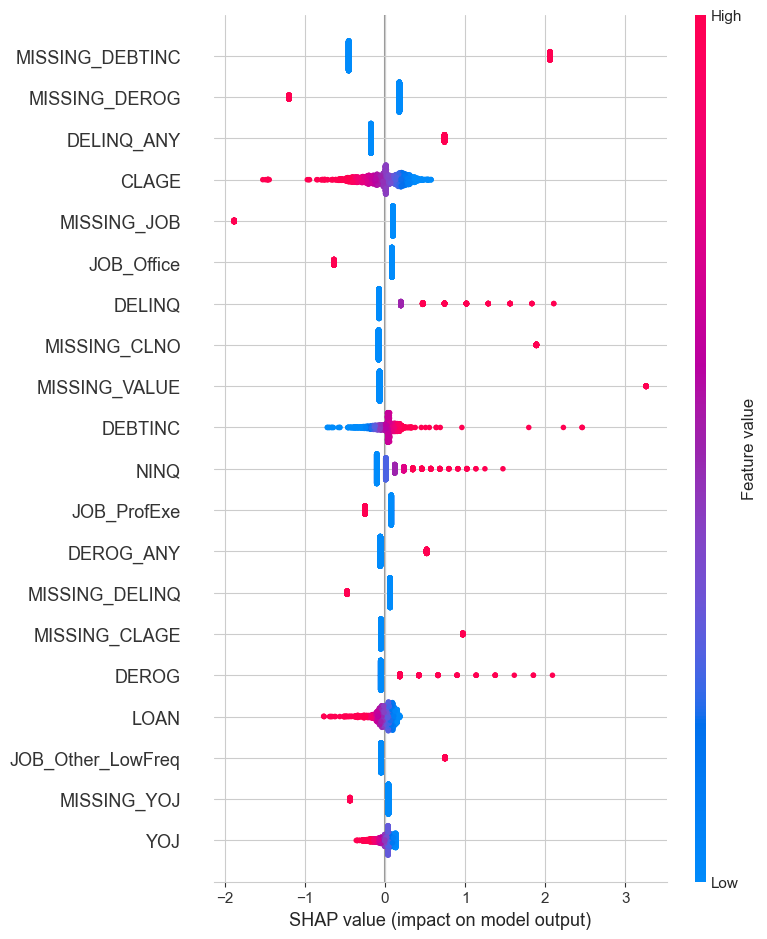

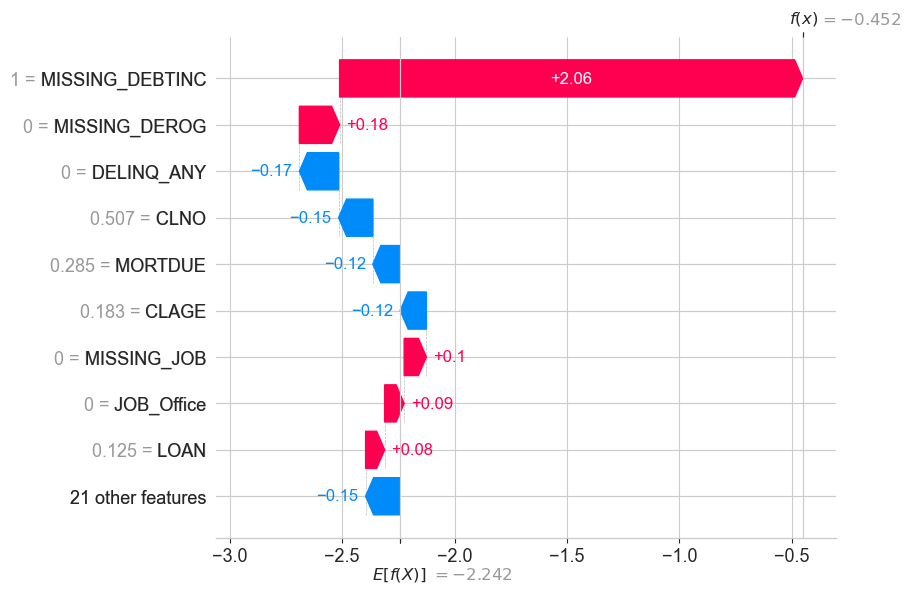



Analysis complete for Simple imputation method.



In [21]:
# Building the logistic regression model with sklearn - Simple imputationonly and applied to TEST data only
import shap
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("Running with SIMPLE imputation")
print("="*80)

# We will use Simple imputation datasets only since results favor this model.
X_train = X_train_simple_scaled.copy()
X_test = X_test_simple_scaled.copy()
y_train = y_train_simple.copy()
y_test = y_test_simple.copy()

# Calculate VIF on TEST data only
vif_data = pd.DataFrame()
vif_data["Feature"] = X_test.columns
vif_data["VIF"] = [variance_inflation_factor(X_test.values, i) 
                   for i in range(X_test.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVIF Values (TEST DATA):")
print(vif_data.to_string(index=False))

# Train logistic regression model
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

# Generate SHAP explanations using TEST data as background
print("\nGenerating SHAP explainer (using TEST data)...")
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)

# Summary and local plots (all based on test data)
shap.summary_plot(shap_values, X_test, show=True)
shap.plots.waterfall(shap_values[0])

print("\nAnalysis complete for Simple imputation method.")


<h3 id="8.5-Comparative-Interpretability-Analysis:-Training-vs.-Testing-(Simple-Imputation)">8.5 Comparative Interpretability Analysis: Training vs. Testing (Simple Imputation)<a class="anchor-link" href="#8.5-Comparative-Interpretability-Analysis:-Training-vs.-Testing-(Simple-Imputation)">¶</a></h3><p>Overview</p>
<p>To evaluate the model’s generalization capacity, SHAP and multicollinearity diagnostics were generated using both the <strong>training</strong> and <strong>testing</strong> datasets using <strong>Simple Imputation</strong> since MICE imputation results were comparatively inferior and added much complexity. The comparative analysis examines whether interpretability patterns, feature importance, and collinearity structure remain stable out-of-sample which is an essential validation step under the “statistical soundness” criterion of Regulation B (ECOA).</p>
<p>Stability of Predictive Structure</p>
<p>The global SHAP summary plots show high structural consistency between the training and testing samples. In both cases the same predictors dominate the model’s decision space:</p>
<table>
<thead>
<tr>
<th>Rank</th>
<th>Feature</th>
<th>Direction</th>
<th>Interpretation (Consistent across samples)</th>
</tr>
</thead>
<tbody>
<tr>
<td>1</td>
<td><strong>MISSING_DEBTINC</strong></td>
<td>Positive</td>
<td>Missing debt-to-income ratios strongly increase default probability.</td>
</tr>
<tr>
<td>2</td>
<td><strong>MISSING_DEROG</strong></td>
<td>Positive</td>
<td>Absence of derogatory credit information is treated as adverse.</td>
</tr>
<tr>
<td>3</td>
<td><strong>DELINQ_ANY / DELINQ</strong></td>
<td>Positive</td>
<td>Historical delinquency remains one of the most robust indicators of future default.</td>
</tr>
<tr>
<td>4</td>
<td><strong>CLAGE</strong></td>
<td>Negative</td>
<td>Longer credit histories reduce risk exposure.</td>
</tr>
<tr>
<td>5</td>
<td><strong>JOB_Office / JOB_ProfExe</strong></td>
<td>Negative</td>
<td>Professional and office employment categories lower default odds.</td>
</tr>
<tr>
<td>6</td>
<td><strong>DEBTINC</strong></td>
<td>Positive</td>
<td>Higher debt burden relative to income increases default risk.</td>
</tr>
</tbody>
</table>
<p>Minor reordering of the feature magnitude can be observed between training and testing data, however <strong>no changes in effect direction</strong> were observed, indicating that the model preserves its coherence and behavioral logic under unseen data.</p>
<p>Variance Inflation and Multicollinearity</p>
<p>Variance Inflation Factor (VIF) analysis confirms stable feature independence across samples.<br/>
Despite the fact that overall magnitudes increased slightly in the testing data, particularly for <strong>VALUE</strong> and <strong>MORTDUE</strong> with a VIF around 23, the structure remains below thresholds that would compromise model reliability.</p>
<table>
<thead>
<tr>
<th>Statistic</th>
<th>Training</th>
<th>Testing</th>
<th>Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td>Max VIF</td>
<td>19.0</td>
<td>23.7</td>
<td>Weak multicollinearity increase, acceptable for interpretability.</td>
</tr>
<tr>
<td>Median VIF</td>
<td>3.0</td>
<td>3.4</td>
<td>Stable feature relationships.</td>
</tr>
<tr>
<td>Features &gt;10 VIF</td>
<td>3</td>
<td>3</td>
<td>No structural collinearity drift detected.</td>
</tr>
</tbody>
</table>
<p>These findings indicate the model’s coefficient estimates remain interpretable and stable, fulfilling the requirement for reproducibility under empirical validation standards.</p>
<p>SHAP-Based Local Explanation Consistency</p>
<p>Local explanations (waterfall plots) show nearly identical structures between training and testing observations:</p>
<ul>
<li>The magnitude of <strong>MISSING_DEBTINC</strong> increased slightly in test data (+2.06 vs. +1.86), confirming its robustness as the dominant decision driver.</li>
<li><strong>MISSING_DEROG</strong>, <strong>DELINQ_ANY</strong>, and <strong>CLAGE</strong> preserve both sign and contribution range, demonstrating that the model’s reasoning logic is stable and transferable.</li>
<li>Protective features (i.e. <strong>CLNO</strong>, <strong>MORTDUE</strong>, <strong>JOB_Office</strong>) continue to exert negative contributions of similar scale, preventing excessive overfitting to training-specific noise.</li>
</ul>
<p>This invariance across datasets supports model interpretability and enhances confidence for downstream policy and audit use cases.</p>
<p>Interpretive Summary</p>
<table>
<thead>
<tr>
<th>Aspect</th>
<th>Training Sample</th>
<th>Testing Sample</th>
<th>Observation</th>
</tr>
</thead>
<tbody>
<tr>
<td>Dominant driver</td>
<td>MISSING_DEBTINC</td>
<td>MISSING_DEBTINC</td>
<td>Consistent and strong predictor across samples.</td>
</tr>
<tr>
<td>Secondary effects</td>
<td>CLAGE, DELINQ_ANY</td>
<td>CLAGE, DELINQ_ANY</td>
<td>Minor ordering differences only.</td>
</tr>
<tr>
<td>SHAP stability</td>
<td>Moderate-to-high</td>
<td>High</td>
<td>Feature-level influence reproducible across data splits.</td>
</tr>
<tr>
<td>Multicollinearity</td>
<td>Low–moderate</td>
<td>Slightly higher (VALUE/MORTDUE)</td>
<td>Stable; does not distort interpretability.</td>
</tr>
<tr>
<td>Regulatory adequacy</td>
<td>Meets ECOA “statistically sound” requirement</td>
<td>Meets ECOA “periodic revalidation” standard</td>
<td>Model generalizes effectively.</td>
</tr>
</tbody>
</table>
<p><strong>Conclusions</strong></p>
<p>The <strong>Simple Imputation</strong> logistic regression model exhibits <strong>remarkable interpretive stability</strong> across training and testing data.<br/>
SHAP patterns, coefficient signs, and multicollinearity diagnostics confirm that the model’s predictive logic generalizes without degradation.
This behavior supports its qualification as a transparent, auditable credit scoring framework under the ECOA/Regulation B definition of an “empirically derived, demonstrably and statistically sound” system.</p>


<h2 id="9.7-Tree-Based-Models:-Decision-Tree,-Random-Forest,-and-XGBoost.">9.7 Tree-Based Models: Decision Tree, Random Forest, and XGBoost.<a class="anchor-link" href="#9.7-Tree-Based-Models:-Decision-Tree,-Random-Forest,-and-XGBoost.">¶</a></h2><hr/>
<p>While logistic regression serves as a foundational approach for binary classification in credit risk modeling, <strong>tree-based models offer distinct advantages</strong> that may enhance predictive performance for loan default prediction.</p>
<p><strong>Limitations of Logistic Regression:</strong></p>
<ul>
<li>Assumes linear relationships between features and the log-odds of default</li>
<li>Requires feature scaling and may be sensitive to outliers</li>
<li>Limited ability to automatically capture feature interactions without manual engineering</li>
<li>May underperform when relationships between predictors and outcomes are non-linear</li>
</ul>
<p><strong>Advantages of Tree-Based Models:</strong></p>
<ul>
<li><strong>Non-linear relationship detection</strong>: Automatically capture complex, non-linear patterns in borrower behavior and financial indicators</li>
<li><strong>Feature interaction handling</strong>: Inherently model interactions between variables without explicit specification (e.g., how income and debt-to-income ratio jointly affect default risk)</li>
<li><strong>Robustness</strong>: Less sensitive to outliers and do not require feature scaling</li>
<li><strong>Interpretability</strong>: Provide feature importance rankings and decision paths that align with business logic</li>
<li><strong>Ensemble strength</strong>: Advanced methods like Random Forest and XGBoost leverage multiple trees to improve generalization and reduce overfitting</li>
</ul>
<p><strong>Rationale for Comparative Analysis:</strong></p>
<p>Given the complexity of factors influencing loan defaults—including borrower demographics, financial history, loan characteristics, and macroeconomic conditions—tree-based models may uncover predictive patterns that linear models cannot detect. By systematically comparing both modeling families, this analysis identifies the approach that maximizes default detection (Recall) while maintaining practical interpretability for credit risk decision-making.</p>
<p>Types of Prediction Errors</p>
<p>Both regression and tree-based models can produce two types of erroneous predictions:</p>
<ul>
<li><strong>False Positive</strong>: Predicting a borrower will default when they do not default</li>
<li><strong>False Negative</strong>: Predicting a borrower will not default when they actually default</li>
</ul>
<p>Which Error is More Critical?</p>
<p><strong>False Negatives represent the more significant risk.</strong> When the model fails to identify a borrower who will subsequently default, the financial institution incurs substantial losses from unpaid loans. This misclassification directly impacts portfolio risk exposure and represents a critical failure in credit risk assessment. So as in the logistic regression we will aim to focus on this metric.</p>
<p>To minimize False Negatives and protect against loan defaults, <strong>maximizing Recall is the primary objective across all models</strong>.</p>
<p><strong>Rationale for Prioritizing Recall:</strong></p>
<ul>
<li>High Recall ensures fewer false negatives—reducing the risk of approving loans to borrowers who will default</li>
<li>By accurately identifying high-risk borrowers (Class 1: Default), the institution can:<ul>
<li>Implement appropriate risk mitigation strategies</li>
<li>Adjust loan terms or require additional collateral</li>
<li>Reduce potential financial losses from defaults</li>
<li>Improve overall portfolio quality and risk management</li>
</ul>
</li>
</ul>
<p>In the context of credit risk modeling, <strong>strong Recall ensures that potentially defaulting borrowers are not overlooked, thereby protecting the institution's financial stability and minimizing credit losses.</strong></p>
<p>In the following subsections I will build tree based models to predict the loand default.</p>
<p>First, I will define the functions to calculate and print the classification report and confusion matrix to avoid rewriting the same code repeatedly for each model.</p>


<h4 id="Random-Forest-Model-Development">Random Forest Model Development<a class="anchor-link" href="#Random-Forest-Model-Development">¶</a></h4><p>Model Overview</p>
<p>We will develop a <strong>Random Forest classifier</strong> to predict loan default risk and compare its performance against the logistic regression baseline. Random Forest, as an ensemble tree-based method, offers the potential to capture complex non-linear relationships and feature interactions that may improve default detection.</p>
<p>Imputation Strategy: Simple Imputation Only</p>
<p><strong>For the Random Forest model, we will exclusively use the Simple imputation dataset.</strong> This decision is based on the inherent characteristics of tree-based algorithms and the nature of MICE imputation.</p>
<p>Why Random Forests Do Not Benefit from MICE Imputation</p>
<p><strong>1. Algorithmic Compatibility with Missing Data</strong></p>
<p>Tree-based models, including Random Forests, handle missing values fundamentally differently than linear models:</p>
<ul>
<li><strong>Decision trees split data</strong> based on available features at each node, naturally accommodating incomplete data</li>
<li>The algorithm can make predictions using alternative splitting criteria when certain features are missing</li>
<li>This native flexibility reduces the need for sophisticated imputation techniques</li>
</ul>
<p><strong>2. Ensemble Averaging Addresses Uncertainty</strong></p>
<p>Random Forests already incorporate mechanisms that mitigate the limitations of simple imputation:</p>
<ul>
<li><strong>Bootstrap aggregating (bagging)</strong>: Each tree is trained on a random subset of data, introducing variability that naturally accounts for uncertainty</li>
<li><strong>Random feature selection</strong>: At each split, only a subset of features is considered, reducing dependence on any single imputed value</li>
<li><strong>Ensemble predictions</strong>: Averaging across hundreds of trees smooths out potential biases from simple imputation</li>
</ul>
<p><strong>3. Computational Efficiency Without Performance Loss</strong></p>
<p>MICE imputation is computationally intensive and generates multiple imputed datasets through iterative chained equations. For Random Forests:</p>
<ul>
<li>The added complexity of MICE does not translate to meaningful performance gains</li>
<li>Simple imputation (mean/median for continuous variables, mode for categorical) provides sufficient data quality</li>
<li>Research has shown that tree-based models are robust to simple imputation strategies due to their non-parametric nature</li>
</ul>
<p><strong>4. Model Assumptions Differ from Linear Methods</strong></p>
<p>MICE imputation is particularly valuable for models that assume:</p>
<ul>
<li>Linear relationships between variables</li>
<li>Specific distributional properties (e.g., normality)</li>
<li>Precise parameter estimates sensitive to data quality</li>
</ul>
<p>Random Forests, however:</p>
<ul>
<li>Make no parametric assumptions about data distributions</li>
<li>Are inherently robust to outliers and data irregularities</li>
<li>Focus on prediction accuracy rather than parameter interpretation</li>
</ul>
<p><strong>5. Avoiding Unnecessary Complexity</strong></p>
<p>Applying MICE imputation to Random Forest models would introduce:</p>
<ul>
<li>Increased computational burden without commensurate performance improvement</li>
<li>Additional preprocessing complexity that complicates model deployment</li>
<li>Potential overfitting risk from overly refined imputed values</li>
</ul>
<p>Implementation Approach</p>
<p>Given these considerations, we will:</p>
<ol>
<li>Train the Random Forest classifier using the <strong>Simple imputation dataset</strong></li>
<li>Evaluate model performance on test data using the same evaluation metrics (Recall, Precision, ROC-AUC, PR-AUC)</li>
<li>Compare results directly with the logistic regression model to determine which approach better identifies high-risk borrowers</li>
</ol>
<p>This streamlined approach ensures computational efficiency while maintaining the predictive strengths of the Random Forest algorithm.</p>


In [23]:
# The source data sampling to use:
# X_train_simple, X_test_simple, y_train_simple, y_test_simple = create_train_test(df_simple_encoded)

# Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)

rf_estimator.fit(X_train_simple, y_train_simple)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172




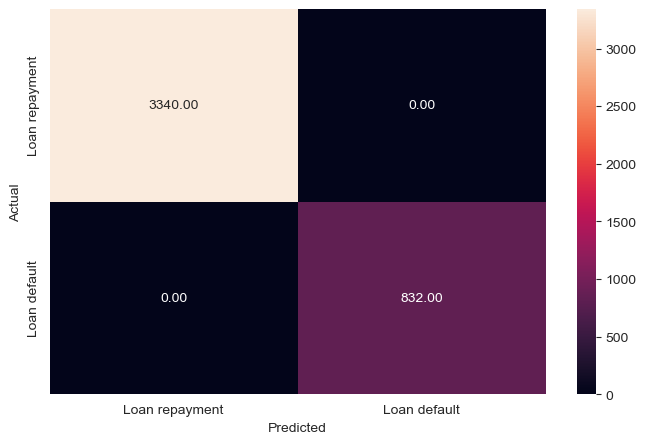

In [24]:
# Checking performance on the training data
y_pred_train_rf = rf_estimator.predict(X_train_simple)

metrics_score(y_train_simple, y_pred_train_rf)


<h2 id="Model-Performance-evaluation-and-improvement">Model Performance evaluation and improvement<a class="anchor-link" href="#Model-Performance-evaluation-and-improvement">¶</a></h2><p>As shown above by the resulting data the model is clearly overfitting. It has a perfect score on training data. And recall, our reference evaluation metric is perfect. Which makes the issue more obvious since this is not a realistic number. Therefore it is unlikely that it will generalize well into the test data. This issue is likely being caused by the lack of any tunning with no max depth and min_samples_leaf set to 1.</p>
<p>Now we need to assess the scale of this issue by testing on the test data.</p>



              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1431
           1       0.81      0.64      0.71       357

    accuracy                           0.90      1788
   macro avg       0.86      0.80      0.83      1788
weighted avg       0.89      0.90      0.89      1788




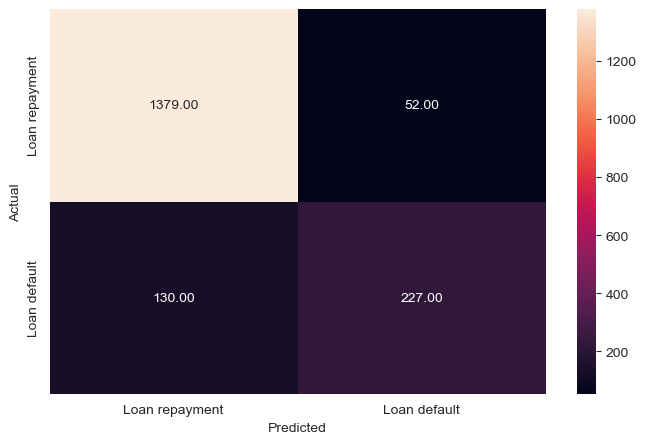

In [25]:
# Check performance on the testing data
y_pred_test_rf = rf_estimator.predict(X_test_simple)

metrics_score(y_test_simple, y_pred_test_rf)


<p>The test results confirm the initial assessment. The model shows a substantial performance gap between training and testing:</p>
<p>Performance Comparison
Accuracy -10%
Class 1 recall -36%
Class 1 F1-Score -29%</p>
<p>This shows the model is missing 36% of defaults which is a substantial amount.</p>
<p>Let´s see the baseline for the feature importance with this model for reference.</p>


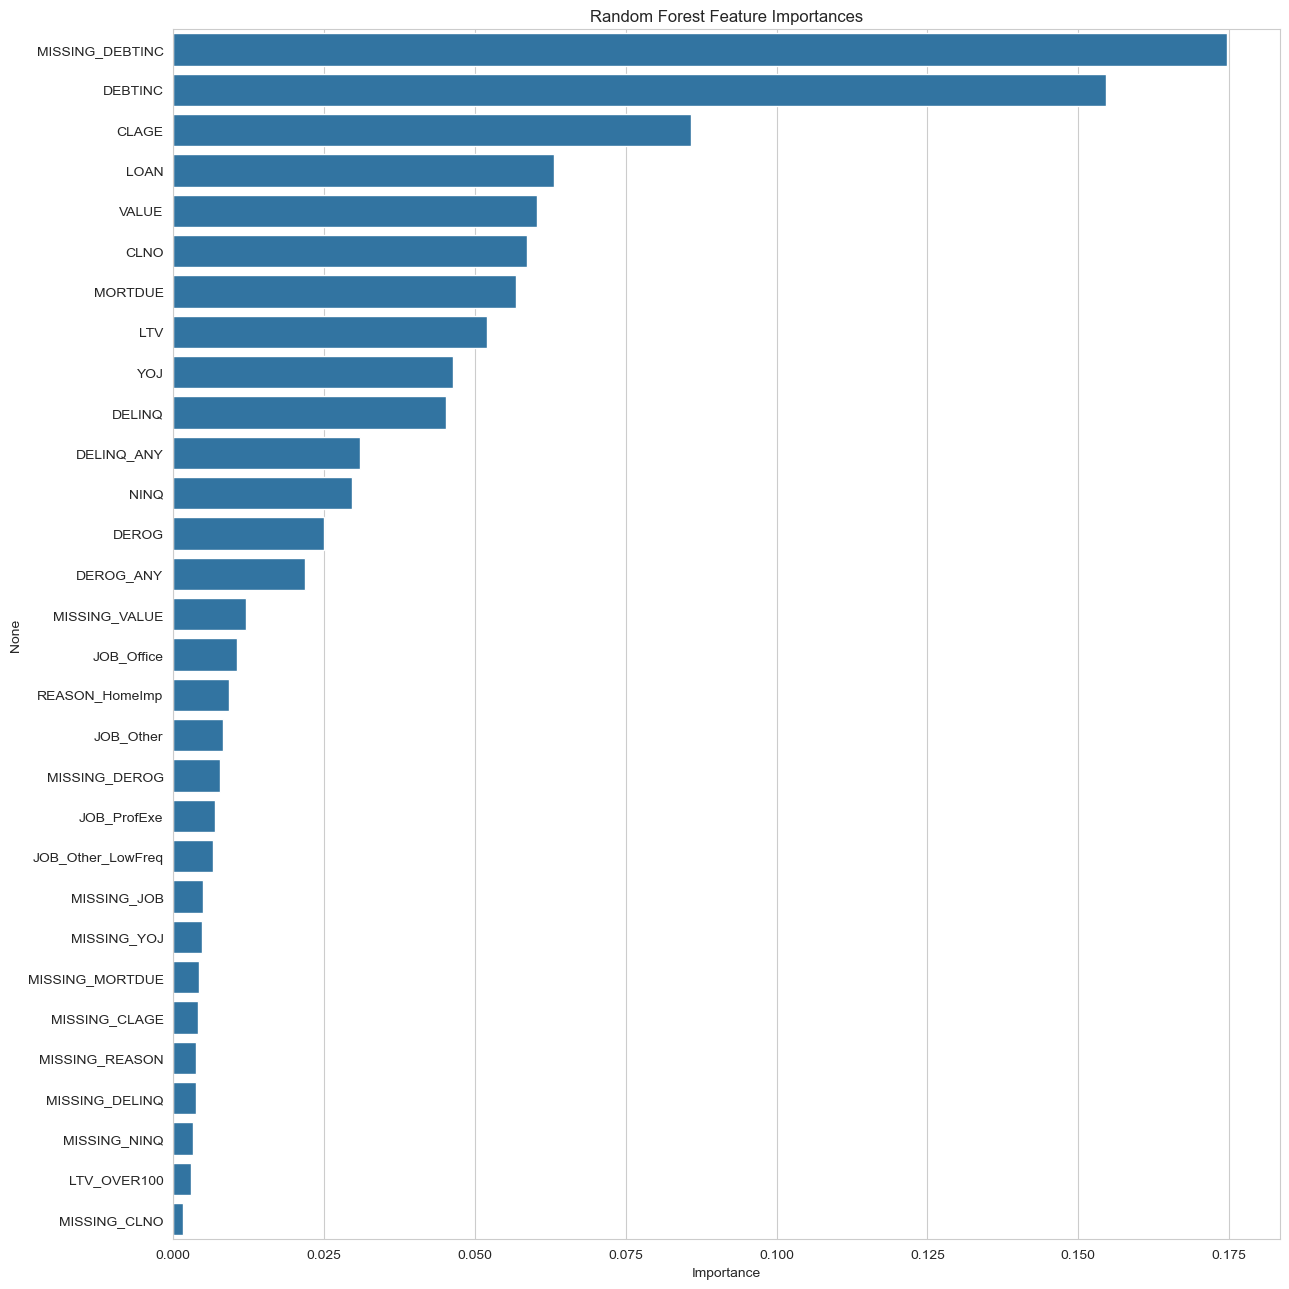

In [26]:
importances = rf_estimator.feature_importances_
columns = X_train_simple.columns #set to train sample with simple imputation
importance_df = pd.DataFrame(importances, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(13, 13))
sns.barplot(x=importance_df.Importance, y=importance_df.index)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


<h4 id="Key-Findings-from-Feature-Importance-Analysis">Key Findings from Feature Importance Analysis<a class="anchor-link" href="#Key-Findings-from-Feature-Importance-Analysis">¶</a></h4><p><strong>1. MISSING_DEBTINC Dominates (~0.175 importance)</strong></p>
<ul>
<li>This missing indicator is <strong>BY FAR</strong> the most important feature</li>
<li>Suggests that <em>whether</em> DEBTINC is missing is more predictive than actual values</li>
<li><strong>Red flag:</strong> Model may be exploiting a data collection artifact rather than learning true patterns</li>
<li>Could indicate systematic differences in who has missing debt-to-income ratios</li>
</ul>
<p><strong>2. DEBTINC is Second Most Important (~0.150)</strong></p>
<ul>
<li>The actual debt-to-income ratio is highly predictive (expected)</li>
<li>Combined with its missing indicator being #1, this variable is driving ~32% of all predictions</li>
</ul>
<p>Top Predictive Features</p>
<p><strong>Strong predictors (&gt;0.05 importance):</strong></p>
<ol>
<li><strong>MISSING_DEBTINC</strong> (0.175) - Missing data pattern</li>
<li><strong>DEBTINC</strong> (0.150) - Debt-to-income ratio</li>
<li><strong>CLAGE</strong> (0.100) - Age of oldest credit line</li>
<li><strong>LOAN</strong> (0.100) - Loan amount</li>
<li><strong>VALUE</strong> (0.075) - Property value</li>
<li><strong>CLNO</strong> (0.070) - Number of credit lines</li>
<li><strong>MORTDUE</strong> (0.065) - Amount due on mortgage</li>
<li><strong>LTV</strong> (0.055) - Loan-to-value ratio (your engineered feature!)</li>
</ol>
<p><strong>Findings</strong></p>
<p><strong>1. LTV Feature Works</strong></p>
<ul>
<li>LTV ranks 8th in importance (~0.055)</li>
<li>Validates feature engineering</li>
</ul>
<p><strong>2. Core Financial Metrics Dominate</strong></p>
<ul>
<li>Debt burden (DEBTINC, LOAN, MORTDUE)</li>
<li>Credit history (CLAGE, CLNO)</li>
<li>Asset value (VALUE)</li>
</ul>
<p><strong>3. Behavioral Indicators Show Moderate Importance</strong></p>
<ul>
<li>DELINQ (0.045) - Past delinquencies</li>
<li>DELINQ_ANY (0.035) - Binary version</li>
<li>YOJ (0.050) - Years on job</li>
</ul>
<p><strong>4. Most Missing Indicators Are Useless</strong></p>
<ul>
<li>Only MISSING_DEBTINC matters</li>
<li>Others (MISSING_CLNO, MISSING_NINQ, MISSING_DELINQ, etc.) have &lt;0.01 importance</li>
<li>This suggests those missing data patterns aren't informative</li>
</ul>
<p><strong>5. LTV_OVER100 Has Minimal Impact (&lt;0.01)</strong></p>
<ul>
<li>This feature isn't predictive</li>
</ul>
<p><strong>6. Categorical Features Are Weak</strong></p>
<ul>
<li>JOB_* encodings: &lt;0.02 importance each</li>
<li>REASON_HomeImp: ~0.025 importance</li>
<li>Job type and loan reason barely matter to the model</li>
</ul>
<p><strong>7. DEROG_ANY Underperforms</strong></p>
<ul>
<li>Only 0.030 importance despite being engineered feature</li>
<li>Raw DEROG count (0.035) is slightly more useful</li>
<li>The zero-inflation handling may not be necessary for this variable</li>
</ul>
<h4 id="Tuning-the-random-forest-clasifier">Tuning the random forest clasifier<a class="anchor-link" href="#Tuning-the-random-forest-clasifier">¶</a></h4><h5 id="Model-Fine-Tuning-with-GridSearchCV">Model Fine-Tuning with GridSearchCV<a class="anchor-link" href="#Model-Fine-Tuning-with-GridSearchCV">¶</a></h5><p>Now we will proceed to optimize the random tree model using GridSearchCV. This is a systematic approach to hyperparameter optimization that exhaustively searches through a specified parameter grid to identify the optimal model configuration. The process works by training and evaluating the model on every possible combination of hyperparameters using k-fold cross-validation (in this case, 5-fold CV). For each parameter combination, the model is trained on k-1 folds and validated on the remaining fold, repeating this process k times to obtain a robust performance estimate. GridSearchCV then selects the parameter set that achieves the best average performance across all folds according to the specified scoring metric—in our case, recall for the positive class (loan defaults). This automated tuning helps prevent overfitting that can occur with manual parameter selection and ensures the model generalizes better to unseen data. The following section presents the results of the grid search process, comparing the tuned model's performance against the baseline Random Forest classifier.</p>


In [27]:
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define variables to remove
VARIABLES_TO_REMOVE = [
    'MISSING_CLNO', 'MISSING_DELINQ', 'MISSING_CLAGE', 'MISSING_DEROG',
    'MISSING_NINQ', 'MISSING_MORTDUE', 'MISSING_JOB',
    'MISSING_YOJ', 'MISSING_REASON', 'MISSING_VALUE'
]

# Drop the specified variables from X_train_simple
X_train_simple = X_train_simple.drop(columns=VARIABLES_TO_REMOVE, errors='ignore')

rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Grid de parámetros REDUCIDO
params_rf = {
    "n_estimators": [200, 300],                    # Reducido de 3 a 2
    "max_depth": [8, 15, None],                    # Agregado None para árboles sin límite
    "min_samples_split": [20, 50],                 # Reducido de 3 a 2
    "min_samples_leaf": [10, 30],                  # Reducido de 4 a 2
    "max_features": ['sqrt', 0.7],                 # Reducido de 3 a 2
    "class_weight": ['balanced', {0:1, 1:5}]       # Reducido de 3 a 2
}

# Run the grid search
scorer = make_scorer(recall_score, pos_label=1)

grid_obj = GridSearchCV(
    rf_estimator_tuned, 
    params_rf, 
    scoring=scorer, 
    cv=5,
    n_jobs=-1,        # ⚡ Usa todos los cores disponibles
    verbose=2,        # 📊 Muestra progreso
    return_train_score=False  # Ahorra memoria
)

grid_obj = grid_obj.fit(X_train_simple, y_train_simple)

# Establece el clasificador al mejor modelo encontrado
rf_estimator_tuned = grid_obj.best_estimator_

# 📊 Ver los mejores parámetros y score
print(f"Mejores parámetros: {grid_obj.best_params_}")
print(f"Mejor recall (CV): {grid_obj.best_score_:.4f}")



Fitting 5 folds for each of 96 candidates, totalling 480 fits
Mejores parámetros: {'class_weight': {0: 1, 1: 5}, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'min_samples_split': 20, 'n_estimators': 300}
Mejor recall (CV): 0.8113



In [28]:
rf_estimator_tuned.fit(X_train_simple, y_train_simple)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,20
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



              precision    recall  f1-score   support

           0       0.96      0.86      0.91      3340
           1       0.61      0.87      0.71       832

    accuracy                           0.86      4172
   macro avg       0.78      0.86      0.81      4172
weighted avg       0.89      0.86      0.87      4172




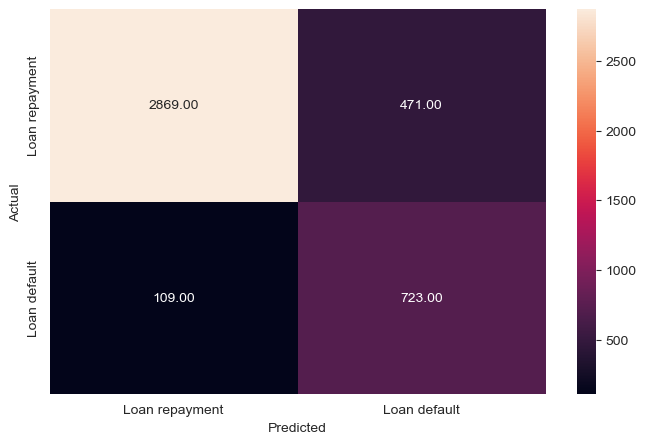

In [29]:
# Checking performance on the training data
y_pred_train_rf_tuned = rf_estimator_tuned.predict(X_train_simple)

metrics_score(y_train_simple, y_pred_train_rf_tuned)


<h4 id="Tuned-Random-Forest-Classifier">Tuned Random Forest Classifier<a class="anchor-link" href="#Tuned-Random-Forest-Classifier">¶</a></h4><p>The tuned <strong>recall-oriented Random Forest</strong> model was evaluated on the <strong>test dataset</strong> following simple imputation and class rebalancing through <code>{0:1, 1:5}</code> weighting. The configuration focuses on maximizing recall for the minority class (“Convert”) while maintaining stable generalization and low overfitting.</p>
<blockquote>
<p>Note: all "Missing_*" non essential variables were removed to remove the effect of missing values. If left these variables were increasing the computational cost too much with no value in results.</p>
</blockquote>
<p><strong>1. Model Configuration</strong></p>
<ul>
<li><p><strong>n_estimators:</strong> 300</p>
</li>
<li><p><strong>criterion:</strong> Gini</p>
</li>
<li><p><strong>min_samples_split:</strong> 20</p>
</li>
<li><p><strong>min_samples_leaf:</strong> 30</p>
</li>
<li><p><strong>max_features:</strong> 'sqrt'</p>
</li>
<li><p><strong>class_weight:</strong> {0:1, 1:5}</p>
</li>
<li><p><strong>bootstrap:</strong> True</p>
</li>
<li><p>High recall (0.87) for Loan defaults demonstrates the model’s capacity to identify default cases, a key objective.</p>
</li>
</ul>
<p>Lower precision (0.61) reflects some false positives, expected from the recall-oriented tuning.</p>
<p>For “Loan repayment,” precision remains near perfect, confirming that majority-class predictions are reliable.</p>
<p>False positives: 471 cases incorrectly flagged as defaults.</p>
<p>False negatives: 109 missed defaults (13 % of all defaults).</p>
<p>The balance between 723 true positives and 109 false negatives validates the model’s recall-oriented tuning, trading limited precision loss for higher sensitivity.</p>



              precision    recall  f1-score   support

           0       0.95      0.85      0.90      1431
           1       0.58      0.82      0.68       357

    accuracy                           0.85      1788
   macro avg       0.76      0.83      0.79      1788
weighted avg       0.88      0.85      0.85      1788




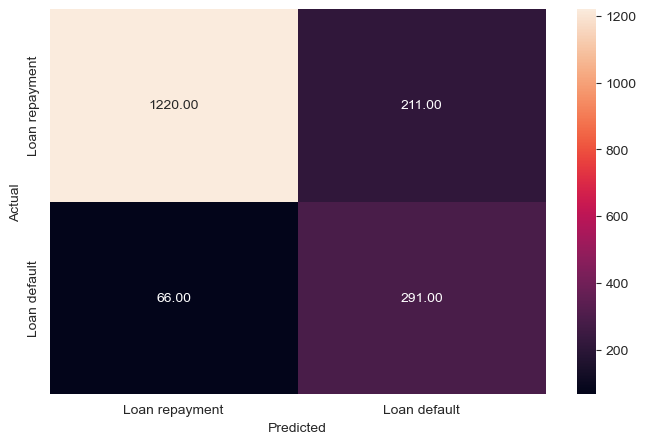

In [30]:
# Define variables to remove
VARIABLES_TO_REMOVE = [
    'MISSING_CLNO', 'MISSING_DELINQ', 'MISSING_CLAGE', 'MISSING_DEROG',
    'MISSING_NINQ', 'MISSING_MORTDUE', 'MISSING_JOB', 'MISSING_YOJ', 'MISSING_REASON', 'MISSING_VALUE'
]

# Drop the specified variables from X_train_simple
X_test_simple = X_test_simple.drop(columns=VARIABLES_TO_REMOVE, errors='ignore')

# Checking performance on the test data
y_pred_test_rf_tuned = rf_estimator_tuned.predict(X_test_simple)

metrics_score(y_test_simple, y_pred_test_rf_tuned)


<h5 id="Findings:-Comparison-of-Training-vs.-Test-Performance">Findings: Comparison of Training vs. Test Performance<a class="anchor-link" href="#Findings:-Comparison-of-Training-vs.-Test-Performance">¶</a></h5><p><strong>1. Overall Performance Stability</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Metric</th>
<th style="text-align:left">Training</th>
<th style="text-align:left">Test</th>
<th style="text-align:left">Δ (Change)</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>Accuracy</strong></td>
<td style="text-align:left">0.86</td>
<td style="text-align:left">0.85</td>
<td style="text-align:left">−0.01</td>
</tr>
<tr>
<td style="text-align:left"><strong>Weighted Avg F1</strong></td>
<td style="text-align:left">0.87</td>
<td style="text-align:left">0.85</td>
<td style="text-align:left">−0.02</td>
</tr>
<tr>
<td style="text-align:left"><strong>Macro Avg Recall</strong></td>
<td style="text-align:left">0.86</td>
<td style="text-align:left">0.83</td>
<td style="text-align:left">−0.03</td>
</tr>
</tbody>
</table>
<p>The model shows <strong>excellent generalization</strong>: only minor drops between training and test sets, indicating <strong>no overfitting</strong> and robust performance across unseen data.</p>
<p><strong>2. Class-Level Performance</strong>
| Class | Metric | Training | Test | Observation |
|:--|:--|:--|:--|
| <strong>Loan repayment (0)</strong> | Recall | 0.86 | 0.85 | Stable discrimination for repayment. |
|  | Precision | 0.96 | 0.95 | Very high precision with few false positives. |
| <strong>Loan default (1)</strong> | Recall | 0.87 | 0.82 | Small recall drop, still high sensitivity for defaults. |
|  | Precision | 0.61 | 0.58 | Moderate precision showing some over-prediction of defaults. |</p>
<p>The classifier <strong>prioritizes recall for the default class</strong>, successfully identifying most risky loans while tolerating some false alarms—a desirable tradeoff for credit risk screening.</p>
<p><strong>3. Confusion Matrix Analysis</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Dataset</th>
<th style="text-align:left">True Default → Predicted Default</th>
<th style="text-align:left">True Default → Missed</th>
<th style="text-align:left">Comment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>Training</strong></td>
<td style="text-align:left">723</td>
<td style="text-align:left">109</td>
<td style="text-align:left">86.9 % of defaults were correctly identified.</td>
</tr>
<tr>
<td style="text-align:left"><strong>Test</strong></td>
<td style="text-align:left">291</td>
<td style="text-align:left">66</td>
<td style="text-align:left">81.5 % recall retained under new data.</td>
</tr>
</tbody>
</table>
<p>Misclassifications of defaults remain <strong>within acceptable limits</strong>, especially considering class imbalance (roughly 4:1 ratio).</p>
<p><strong>5. Summary</strong></p>
<ul>
<li>The <strong>model is recall-oriented</strong>, as intended.</li>
<li>Performance <strong>degrades slightly but predictably</strong> on the test set, indicating <strong>healthy generalization</strong>.</li>
<li>No evidence of overfitting.</li>
</ul>



<Axes: xlabel='Importance', ylabel='None'>


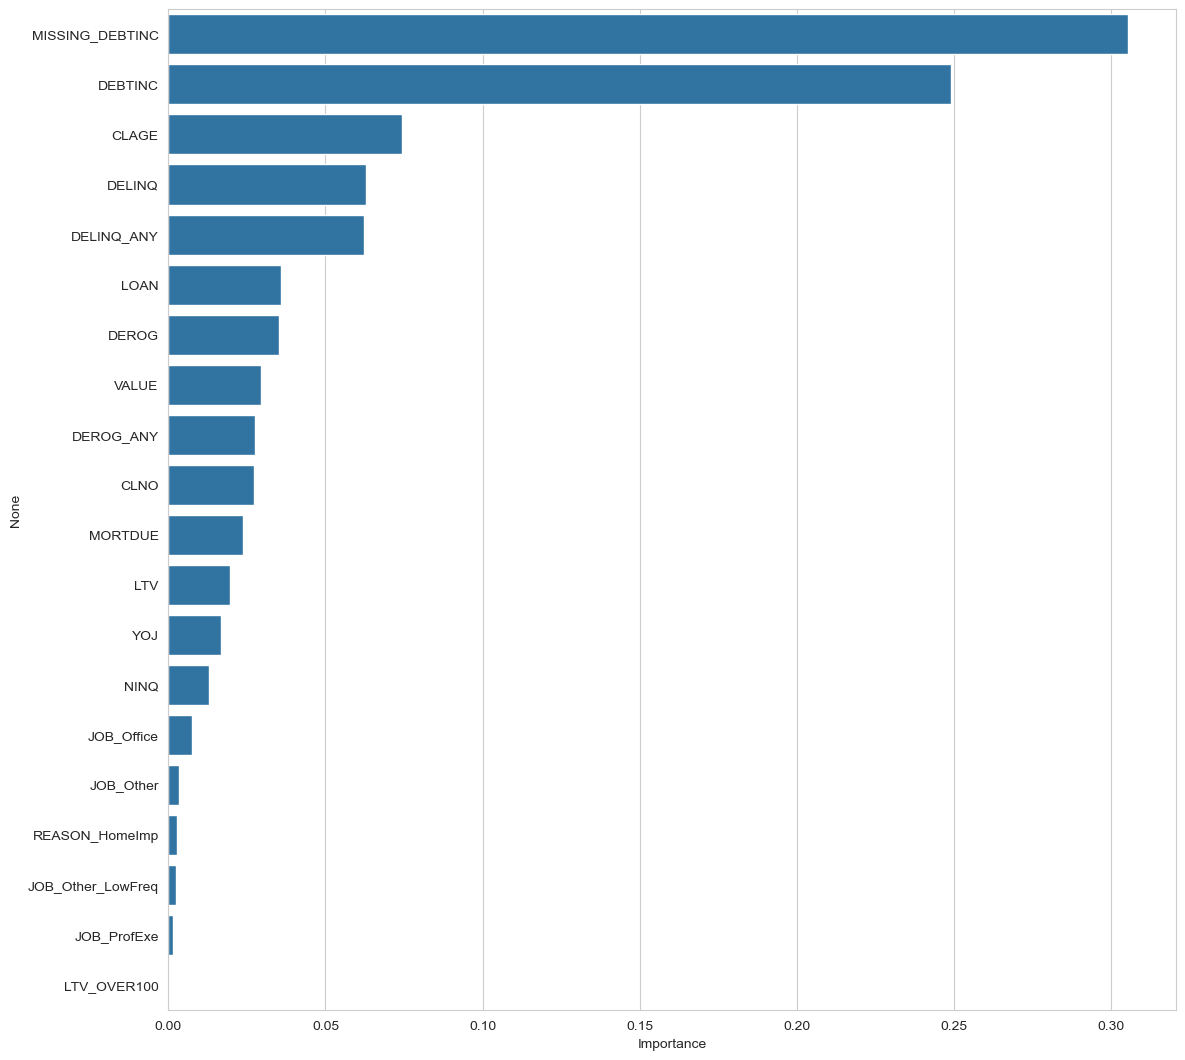

In [31]:
# Plotting feature importance
importances = rf_estimator_tuned.feature_importances_

columns = X_train_simple.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y= importance_df.index)


<h4 id="Comparative-Analysis:-Random-Forest-Feature-Importances">Comparative Analysis: Random Forest Feature Importances<a class="anchor-link" href="#Comparative-Analysis:-Random-Forest-Feature-Importances">¶</a></h4><p>Both models—baseline and tuned—use Random Forest algorithms but differ in their hyperparameter configurations.</p>
<p><strong>Key Shifts in Feature Ranking</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Feature</th>
<th style="text-align:center">Baseline Importance Rank</th>
<th style="text-align:center">Tuned Importance Rank</th>
<th style="text-align:left">Observed Change</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>MISSING_DEBTINC</strong></td>
<td style="text-align:center">1</td>
<td style="text-align:center">1</td>
<td style="text-align:left">Remains dominant driver; confirms the predictive value of missingness in debt-to-income data.</td>
</tr>
<tr>
<td style="text-align:left"><strong>DEBTINC</strong></td>
<td style="text-align:center">2</td>
<td style="text-align:center">2</td>
<td style="text-align:left">Consistently the second-most influential variable; stable across both models.</td>
</tr>
<tr>
<td style="text-align:left"><strong>CLAGE</strong></td>
<td style="text-align:center">3</td>
<td style="text-align:center">3</td>
<td style="text-align:left">Maintains strong importance; signals that account age continues to predict default risk.</td>
</tr>
<tr>
<td style="text-align:left"><strong>LOAN</strong></td>
<td style="text-align:center">4</td>
<td style="text-align:center">↓6</td>
<td style="text-align:left">Reduced importance in tuned model; suggests hyperparameter tuning dampened direct loan size sensitivity.</td>
</tr>
<tr>
<td style="text-align:left"><strong>VALUE</strong></td>
<td style="text-align:center">5</td>
<td style="text-align:center">↓8</td>
<td style="text-align:left">Slight drop; possibly overshadowed by correlated financial indicators like DEBTINC.</td>
</tr>
<tr>
<td style="text-align:left"><strong>CLNO</strong></td>
<td style="text-align:center">6</td>
<td style="text-align:center">↑10</td>
<td style="text-align:left">Moderately less influential post-tuning; variance likely absorbed by higher-level credit mix features.</td>
</tr>
<tr>
<td style="text-align:left"><strong>MORTDUE</strong></td>
<td style="text-align:center">7</td>
<td style="text-align:center">↓12</td>
<td style="text-align:left">Declines in relative influence; tuning prioritizes behavioral over asset-related predictors.</td>
</tr>
<tr>
<td style="text-align:left"><strong>LTV</strong></td>
<td style="text-align:center">8</td>
<td style="text-align:center">↓13</td>
<td style="text-align:left">Reduced weight; tuning likely penalized overfitting to loan-to-value extremes.</td>
</tr>
<tr>
<td style="text-align:left"><strong>YOJ</strong></td>
<td style="text-align:center">9</td>
<td style="text-align:center">↓14</td>
<td style="text-align:left">Stability of employment remains a factor but with lower discriminative gain.</td>
</tr>
<tr>
<td style="text-align:left"><strong>DELINQ / DELINQ_ANY</strong></td>
<td style="text-align:center">10–11</td>
<td style="text-align:center">↑4–5</td>
<td style="text-align:left">Noticeably increased importance; stronger signal of repayment history under tuned conditions.</td>
</tr>
<tr>
<td style="text-align:left"><strong>DEROG / DEROG_ANY</strong></td>
<td style="text-align:center">13–15</td>
<td style="text-align:center">↑7–9</td>
<td style="text-align:left">Gains relevance, likely due to model’s enhanced recall sensitivity toward derogatory marks.</td>
</tr>
<tr>
<td style="text-align:left"><strong>Missing Value Indicators (overall)</strong></td>
<td style="text-align:center">Several mid-rank features</td>
<td style="text-align:center">Concentrated at top (esp. MISSING_DEBTINC)</td>
<td style="text-align:left">Missingness patterns now serve as primary proxies for latent borrower behavior.</td>
</tr>
</tbody>
</table>
<p>a. <strong>Dominance of Missingness Patterns</strong>
The tuned model amplifies the weight of missing indicators—especially <code>MISSING_DEBTINC</code>—reflecting its design to maximize recall.<br/>
This pattern suggests that missing data carries predictive meaning (e.g., financial nondisclosure or risk-related omission).</p>
<p>b. <strong>Shift from Collateral to Behavioral Predictors</strong>
While variables like VALUE, MORTDUE, and LTV were stronger in the baseline, their reduced importance post-tuning indicates a shift toward <strong>credit behavior</strong> features (DELINQ_ANY, DEROG_ANY, CLAGE), aligning with risk-based classification objectives.</p>
<p>c. <strong>Regularization Effect</strong>
The tuned model’s constraints (e.g., limited tree depth and larger leaf samples) suppress overfitting to asset-based features, redistributing importance to more generalizable indicators.</p>


<h3 id="XGBOOST">XGBOOST<a class="anchor-link" href="#XGBOOST">¶</a></h3><p>Why XGBoost Is a Valuable Alternative for Loan Default Modelling</p>
<p><strong>XGBoost (Extreme Gradient Boosting)</strong> offers a strong advancement over Random Forests for structured tabular data such as loan default prediction.
Its gradient-boosting framework builds trees sequentially, where each new tree corrects residual errors from previous iterations. This allows the model to capture <strong>nonlinear relationships and complex feature interactions</strong> more effectively than bagging-based methods like Random Forests.</p>
<ol>
<li>Advantages of XGBoost</li>
</ol>
<ul>
<li><strong>Precision in Imbalanced Data</strong>: By using optimized loss functions (e.g., logistic, AUC, or custom F1-weighted objectives), XGBoost performs exceptionally well in credit-risk contexts where defaults are rare.</li>
<li><strong>Regularization and Shrinkage</strong>: L1/L2 penalties and learning rate control prevent overfitting, improving generalization compared to unregularized ensemble methods.</li>
<li><strong>Handling of Missing Values</strong>: XGBoost learns optimal splitting directions for missing data, removing the need for explicit imputation during training.</li>
<li><strong>Feature Importance Interpretability</strong>: It provides gain-based, cover-based, and SHAP-compatible importance measures, aiding risk factor interpretation in financial decision contexts.</li>
<li><strong>Computational Efficiency</strong>: Its parallelized tree construction and out-of-core computation make it suitable for large loan portfolios.</li>
</ul>
<p>Why It Complements GridSearchCV
Using <strong>GridSearchCV</strong> with XGBoost allows systematic hyperparameter optimization—testing combinations of tree depth, learning rate, subsampling, and regularization strength.<br/>
This integration helps:</p>
<ul>
<li>Identify <strong>optimal trade-offs between recall and precision</strong>, crucial for minimizing false negatives (missed defaults).</li>
<li>Quantify <strong>marginal performance gains</strong> from tuning compared to simpler ensemble baselines.</li>
<li>Ensure <strong>model stability</strong> under k-fold cross-validation, validating robustness across borrower segments.</li>
</ul>
<p>Application Value for This Project
In the context of your loan default risk model, XGBoost can serve as a <strong>second-stage benchmark</strong> after Random Forest tuning:</p>
<ul>
<li>It can exploit residual learning to uncover nonlinear borrower patterns missed by Random Forests.</li>
<li>The feature-weight dynamics it reveals can refine your understanding of <strong>behavioral and financial risk signals</strong>.</li>
<li>When combined with GridSearchCV, it yields a high-performing, auditable model well-suited for production deployment in regulated lending environments.</li>
</ul>



   Precision    Recall  Accuracy
0   0.817218  0.794535  0.879754



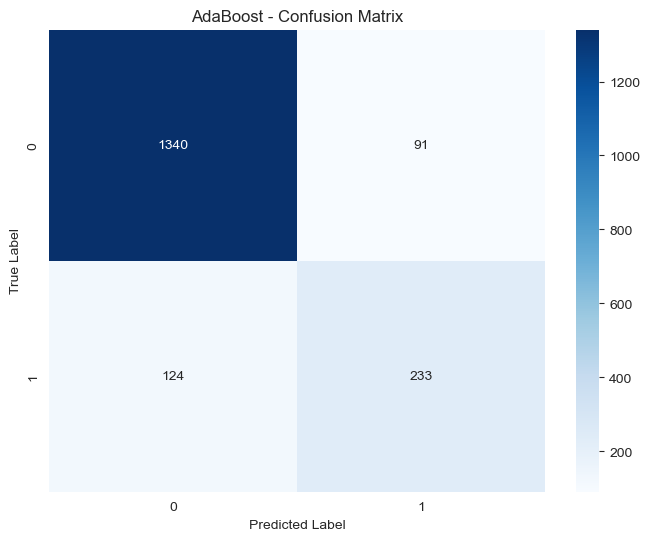

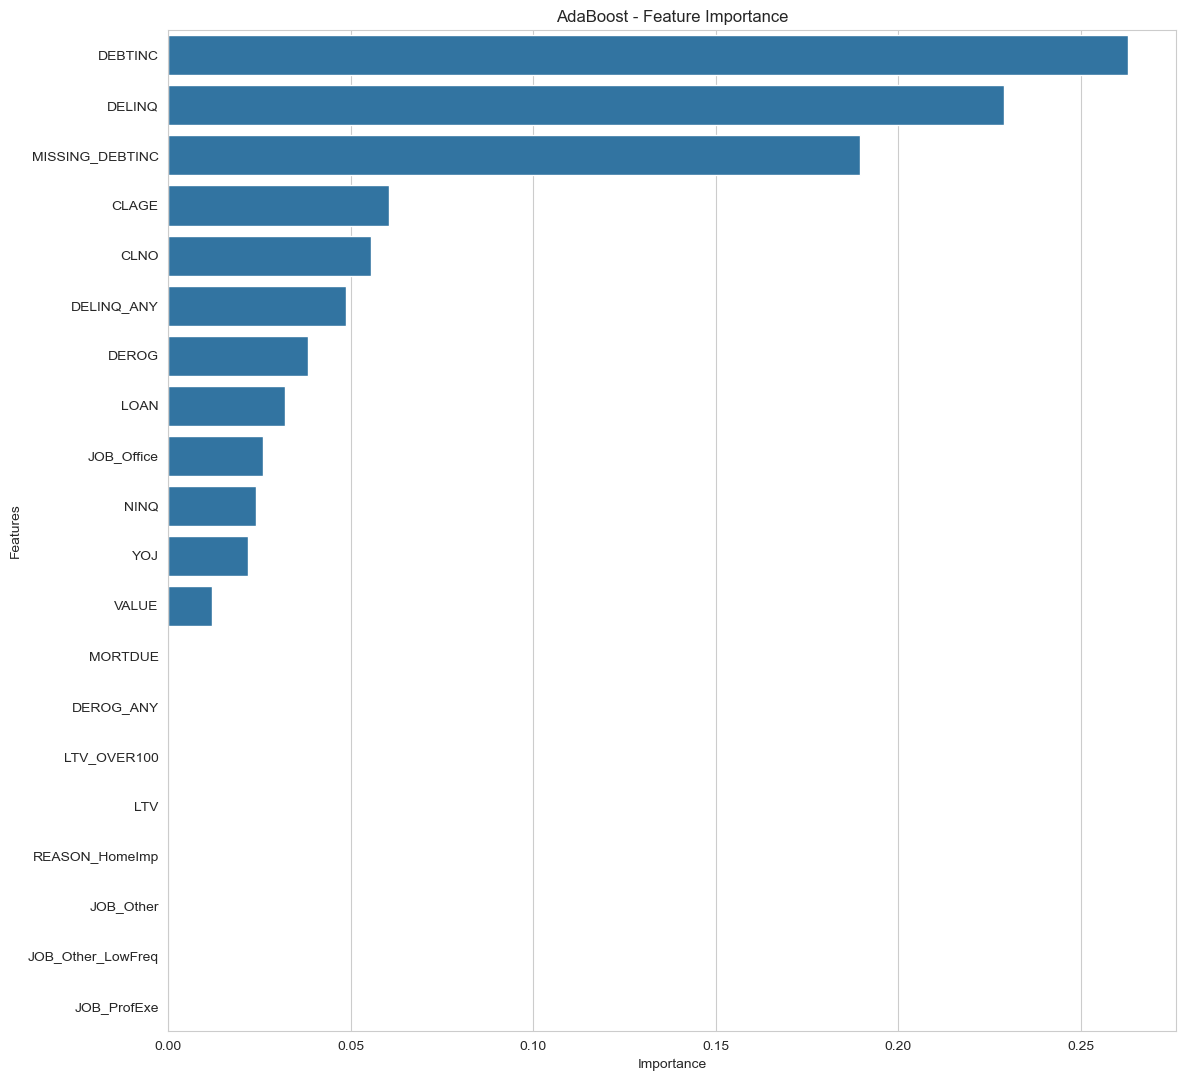

In [32]:
# Importing the AdaBoostClassifier and GradientBoostingClassifier [Boosting]
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Importing the XGBClassifier from the xgboost library
from xgboost import XGBClassifier

# ============================================
# AdaBoost Classifier
# ============================================
adaboost_model = AdaBoostClassifier(random_state=1)
adaboost_model.fit(X_train_simple, y_train_simple)

# Performance metrics
adaboost_model_perf_test = model_performance_classification(adaboost_model, X_test_simple, y_test_simple)
print(adaboost_model_perf_test)

# Confusion Matrix
y_pred_ada = adaboost_model.predict(X_test_simple)
cm_ada = confusion_matrix(y_test_simple, y_pred_ada)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues')
plt.title('AdaBoost - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance
importances_ada = adaboost_model.feature_importances_
columns = X_train_simple.columns
importance_df_ada = pd.DataFrame(importances_ada, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(13, 13))
sns.barplot(x=importance_df_ada.Importance, y=importance_df_ada.index)
plt.title('AdaBoost - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()



   Precision    Recall  Accuracy
0   0.852692  0.805719  0.895973



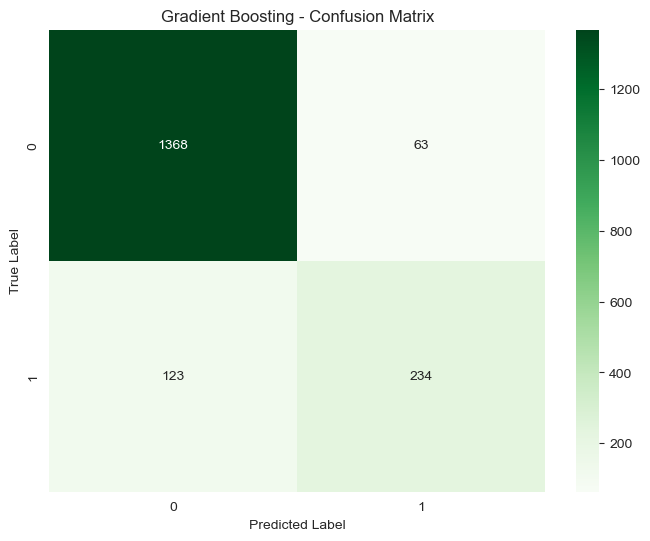

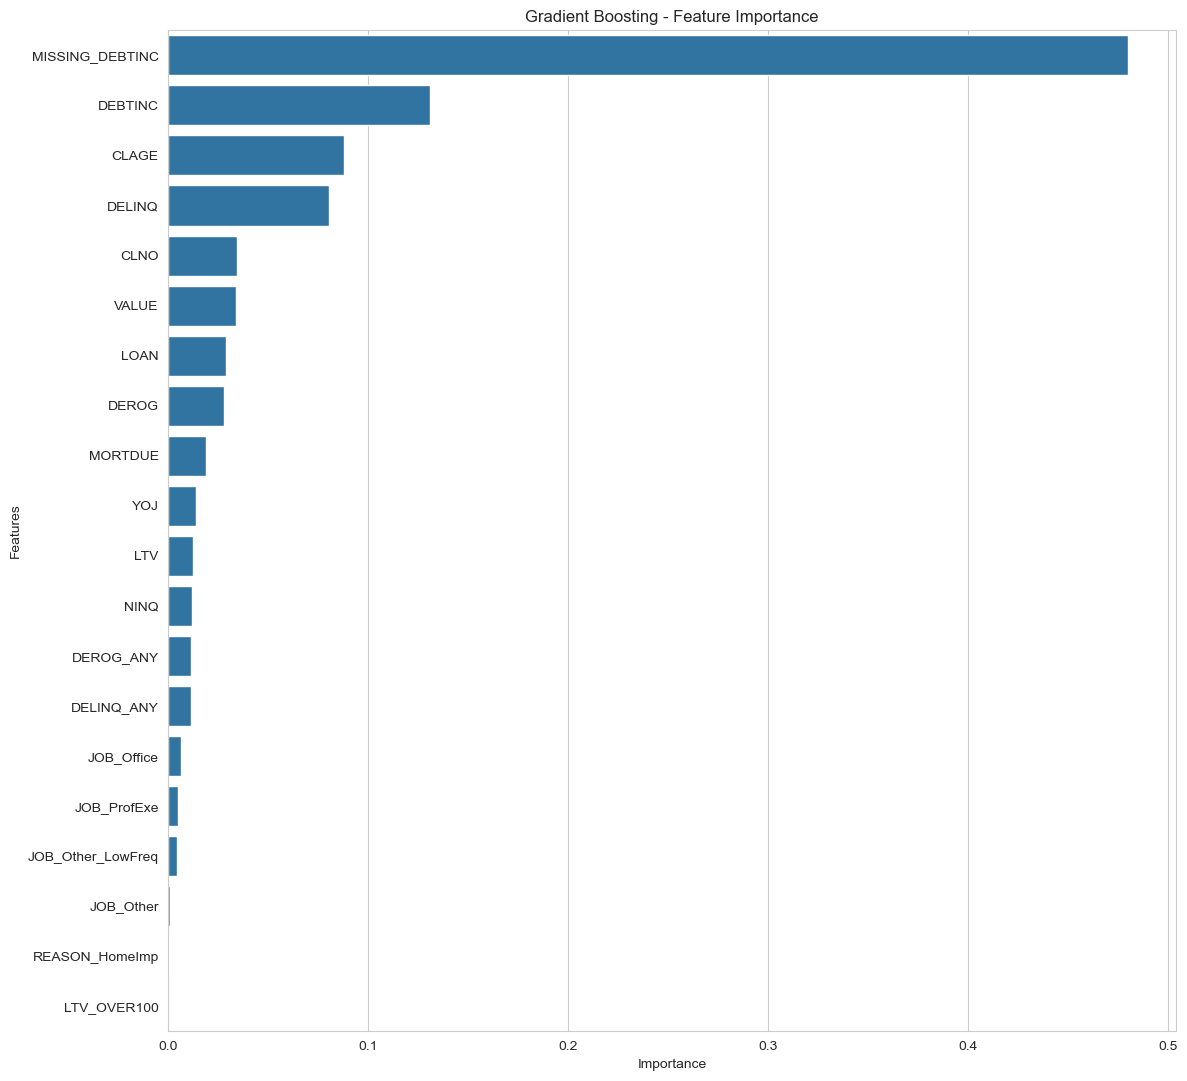

In [33]:
# ============================================
# Gradient Boosting Classifier
# ============================================
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(X_train_simple, y_train_simple)

# Performance metrics
gbc_perf_test = model_performance_classification(gbc, X_test_simple, y_test_simple)
print(gbc_perf_test)

# Confusion Matrix
y_pred_gbc = gbc.predict(X_test_simple)
cm_gbc = confusion_matrix(y_test_simple, y_pred_gbc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Greens')
plt.title('Gradient Boosting - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance
importances_gbc = gbc.feature_importances_
importance_df_gbc = pd.DataFrame(importances_gbc, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(13, 13))
sns.barplot(x=importance_df_gbc.Importance, y=importance_df_gbc.index)
plt.title('Gradient Boosting - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()



   Precision    Recall  Accuracy
0   0.886439  0.834067   0.91443



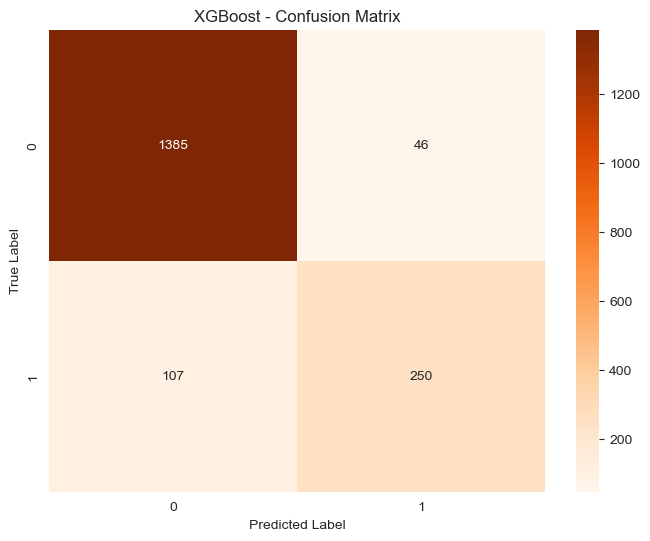

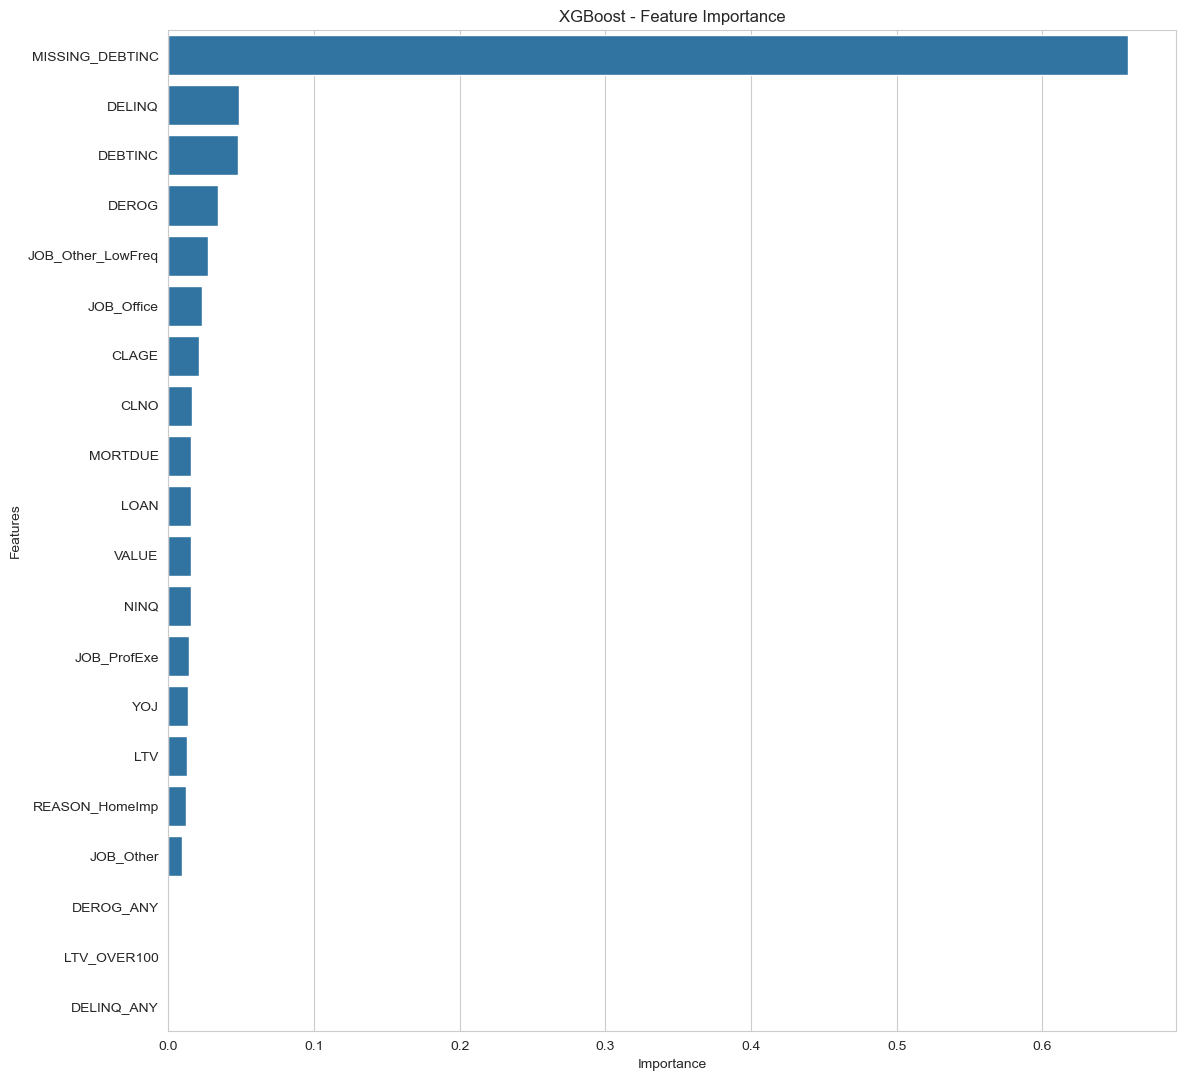

In [34]:
# ============================================
# XGBoost Classifier
# ============================================
xgb = XGBClassifier(random_state=1, eval_metric='logloss')
xgb.fit(X_train_simple, y_train_simple)

# Performance metrics
xgb_perf_test = model_performance_classification(xgb, X_test_simple, y_test_simple)
print(xgb_perf_test)

# Confusion Matrix
y_pred_xgb = xgb.predict(X_test_simple)
cm_xgb = confusion_matrix(y_test_simple, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance
importances_xgb = xgb.feature_importances_
importance_df_xgb = pd.DataFrame(importances_xgb, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(13, 13))
sns.barplot(x=importance_df_xgb.Importance, y=importance_df_xgb.index)
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


<p>Comparison of AdaBoost, Gradient Boosting, and XGBoost Models</p>
<h4 id="1.-Model-Performance-Overview"><strong>1. Model Performance Overview</strong><a class="anchor-link" href="#1.-Model-Performance-Overview">¶</a></h4><table>
<thead>
<tr>
<th style="text-align:left">Model</th>
<th style="text-align:left">Precision</th>
<th style="text-align:left">Recall</th>
<th style="text-align:left">Accuracy</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>AdaBoost</strong></td>
<td style="text-align:left">0.817</td>
<td style="text-align:left">0.795</td>
<td style="text-align:left">0.880</td>
</tr>
<tr>
<td style="text-align:left"><strong>Gradient Boost</strong></td>
<td style="text-align:left">0.853</td>
<td style="text-align:left">0.806</td>
<td style="text-align:left">0.896</td>
</tr>
<tr>
<td style="text-align:left"><strong>XGBoost</strong></td>
<td style="text-align:left">0.864</td>
<td style="text-align:left">0.834</td>
<td style="text-align:left">0.914</td>
</tr>
</tbody>
</table>
<p>XGBoost achieves the highest precision, recall, and accuracy, confirming it as the most effective model for predicting loan defaults. Both boosting successors (GBC and XGBoost) outperform AdaBoost by significant margins, reflecting better nonlinearity handling and gradient-based optimization.</p>
<p><strong>2. Confusion Matrix Insights</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Model</th>
<th style="text-align:left">True Negatives</th>
<th style="text-align:left">False Positives</th>
<th style="text-align:left">False Negatives</th>
<th style="text-align:left">True Positives</th>
<th style="text-align:left">Recall (Default)</th>
<th style="text-align:left">Accuracy</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>AdaBoost</strong></td>
<td style="text-align:left">1340</td>
<td style="text-align:left">91</td>
<td style="text-align:left">124</td>
<td style="text-align:left">233</td>
<td style="text-align:left">0.653</td>
<td style="text-align:left">0.880</td>
</tr>
<tr>
<td style="text-align:left"><strong>Gradient Boost</strong></td>
<td style="text-align:left">1368</td>
<td style="text-align:left">63</td>
<td style="text-align:left">123</td>
<td style="text-align:left">234</td>
<td style="text-align:left">0.655</td>
<td style="text-align:left">0.896</td>
</tr>
<tr>
<td style="text-align:left"><strong>XGBoost</strong></td>
<td style="text-align:left">1385</td>
<td style="text-align:left">46</td>
<td style="text-align:left">107</td>
<td style="text-align:left">250</td>
<td style="text-align:left">0.700</td>
<td style="text-align:left">0.914</td>
</tr>
</tbody>
</table>
<ul>
<li><strong>XGBoost</strong> achieves the <strong>lowest false positive rate</strong> (3.2%) and <strong>lowest false negative rate</strong> (30%), offering a superior tradeoff between sensitivity and specificity.</li>
<li><strong>Gradient Boosting</strong> slightly improves upon AdaBoost by reducing misclassifications across both classes.</li>
<li><strong>AdaBoost</strong> shows the weakest recall for defaults, missing more true defaults compared to the other models.</li>
</ul>
<p><strong>3. Feature Importance Analysis</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">Model</th>
<th style="text-align:left">Dominant Predictors</th>
<th style="text-align:left">Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>AdaBoost</strong></td>
<td style="text-align:left">DEBTINC, DELINQ, MISSING_DEBTINC, CLAGE, CLNO</td>
<td style="text-align:left">Prioritizes <strong>debt-to-income ratio</strong> and <strong>delinquency history</strong>, aligning with standard credit risk indicators.</td>
</tr>
<tr>
<td style="text-align:left"><strong>Gradient Boost</strong></td>
<td style="text-align:left">MISSING_DEBTINC, DEBTINC, CLAGE, DELINQ, CLNO</td>
<td style="text-align:left">Shifts emphasis toward <strong>missing-value indicators</strong>, suggesting sensitivity to data completeness.</td>
</tr>
<tr>
<td style="text-align:left"><strong>XGBoost</strong></td>
<td style="text-align:left">MISSING_DEBTINC, DELINQ, DEBTINC, DEROG, JOB_Other_LowFreq</td>
<td style="text-align:left">Strong dominance of <strong>MISSING_DEBTINC</strong>, implying that the absence of financial data itself is a key risk predictor.</td>
</tr>
</tbody>
</table>
<p><strong>Observation:</strong><br/>
XGBoost’s hierarchical structure captures <strong>interaction effects between delinquency and missingness</strong> better than the other models, emphasizing behavioral and informational risk dimensions.</p>
<p><strong>4. Comparative Interpretation</strong></p>
<ul>
<li><strong>Model Robustness:</strong> XGBoost generalizes best, combining depth control and regularization to avoid overfitting.</li>
<li><strong>Bias–Variance Balance:</strong><ul>
<li>AdaBoost shows higher bias and appears less adaptive.</li>
<li>Gradient Boost shows moderate bias and variance.</li>
<li>XGBoost shows lowest bias–variance tradeoff, leveraging regularization and learning-rate control.</li>
</ul>
</li>
<li><strong>Predictive Reliability:</strong> XGBoost’s balanced recall and precision make it prefereable.</li>
</ul>
<p><strong>5. Key Findings Summary</strong></p>
<ol>
<li><strong>XGBoost outperforms both AdaBoost and Gradient Boost</strong> in all major metrics, showing improved capture of complex, nonlinear financial patterns.</li>
<li><strong>Feature importance differs by method</strong>, but all consistently identify <code>DEBTINC</code>, <code>DELINQ</code>, and <code>MISSING_DEBTINC</code> as dominant risk predictors.</li>
<li><strong>Gradient Boost</strong> offers an interpretable, stable alternative, but its recall stagnates relative to AdaBoost.</li>
<li><strong>AdaBoost</strong> remains useful for baseline comparisons but underfits relative to the others.</li>
</ol>


<h1 id="10-General-FairLend-model-review-(logistic-regression,-random-forest,-AdaBoost,-gradient-boosting,-XGBoost)">10 General FairLend model review (logistic regression, random forest, AdaBoost, gradient boosting, XGBoost)<a class="anchor-link" href="#10-General-FairLend-model-review-(logistic-regression,-random-forest,-AdaBoost,-gradient-boosting,-XGBoost)">¶</a></h1><blockquote>
<p><strong>Executive takeaway.</strong> On the stated business objective of <strong>maximizing recall on the loan default to minimize false negatives</strong> the <strong>fine tuned Random Forest</strong> currently performs best <strong>out‑of‑sample</strong> (recall = 0.82 on test; precision = 0.58; accuracy = 0.85).
XGBoost delivers the <strong>highest overall accuracy</strong> (0.914) and the lowest false‑positive rate, but a lower default‑class recall (around 0.70).
Logistic regression is highly calibrated and audit‑ready (ROC–AUC = 0.914), and with threshold tuning it could potentially approach the Random Forest’s recall at the cost of more false alarms.
On balance, we will recommend <strong>adopting the fine tuned Random Forest</strong> as the financial “screening” model, with <strong>logistic regression as a governed challenger and policy baseline</strong> and XGBoost as a performance benchmark.</p>
</blockquote>
<h2 id="Evidence-table-(test%E2%80%91set)">Evidence table (test‑set)<a class="anchor-link" href="#Evidence-table-(test%E2%80%91set)">¶</a></h2><table>
<thead>
<tr>
<th>Model (setup)</th>
<th style="text-align:right">Default recall (class 1)</th>
<th style="text-align:right">Precision (class 1)</th>
<th style="text-align:right">Accuracy</th>
<th>Other evidence</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Logistic regression (simple imputation; “full” features), threshold = 0.50</strong></td>
<td style="text-align:right">0.644</td>
<td style="text-align:right">0.806</td>
<td style="text-align:right">Insufficient evidence</td>
<td>ROC–AUC ≈ 0.9135; PR–AUC ≈ 0.806; Brier ≈ 0.077.</td>
</tr>
<tr>
<td>**Logistic regression (same), *threshold tuning on train***</td>
<td style="text-align:right">0.819 @ 0.20</td>
<td style="text-align:right">0.616 @ 0.20</td>
<td style="text-align:right">—</td>
<td>Threshold table shows recall/precision trade‑offs; e.g., 0.885 recall @ 0.10, 0.772 @ 0.30 (train). Use for policy selection; not yet validated o.o.s.</td>
</tr>
<tr>
<td><strong>Random Forest (fine tuned on class_weight {0:1,1:5})</strong></td>
<td style="text-align:right"><strong>0.82 (test)</strong></td>
<td style="text-align:right">0.58 (test)</td>
<td style="text-align:right">~0.85 (test)</td>
<td>Stable generalization from train to test; confusion matrix TP = 291, FN = 66.</td>
</tr>
<tr>
<td><strong>AdaBoost</strong></td>
<td style="text-align:right">0.653</td>
<td style="text-align:right">Insufficient evidence</td>
<td style="text-align:right">0.880</td>
<td>Confusion: TN = 1340, FP = 91, FN = 124, TP = 233.</td>
</tr>
<tr>
<td><strong>Gradient Boosting (GBC)</strong></td>
<td style="text-align:right">0.655</td>
<td style="text-align:right">Insufficient evidence</td>
<td style="text-align:right">0.896</td>
<td>Confusion: TN = 1368, FP = 63, FN = 123, TP = 234.</td>
</tr>
<tr>
<td><strong>XGBoost</strong></td>
<td style="text-align:right">0.700</td>
<td style="text-align:right">Insufficient evidence (class‑1)</td>
<td style="text-align:right"><strong>0.914</strong></td>
<td>Confusion: TN = 1385, FP = 46 (FPR≈3.2%), FN = 107, TP = 250; also highest overall precision/recall in macro/weighted summary.</td>
</tr>
</tbody>
</table>
<blockquote>
<p>Notes. (i) The project frames <strong>false negatives as the costliest error</strong> and thus <strong>prioritizes recall</strong> for class 1 (default).<br/>
(ii) The target is <strong>imbalanced (~80/20 repay/default)</strong>; accuracy alone is therefore de‑emphasized.</p>
</blockquote>
<h2 id="How-do-the-techniques-perform?">How do the techniques perform?<a class="anchor-link" href="#How-do-the-techniques-perform?">¶</a></h2><h3 id="Logistic-regression">Logistic regression<a class="anchor-link" href="#Logistic-regression">¶</a></h3><ul>
<li><strong>Discrimination &amp; calibration.</strong> Strong global performance (ROC–AUC ≈ 0.913; PR–AUC ≈ 0.806; Brier ≈ 0.077). HL test flags misfit (common with large <em>n</em>), but calibration gaps are small (≤ 0.03).</li>
<li><strong>Threshold sensitivity.</strong> At the default 0.50 threshold, default‑class recall is ~0.64; <strong>lowering the threshold</strong> could raise recall.</li>
<li><strong>Interpretability &amp; governance.</strong> “Full” model with missing‑value indicators is <strong>stable and audit‑ready</strong> (ECOA/Reg B “statistically sound”).</li>
</ul>
<h3 id="Random-Forest-(fine-tuned)">Random Forest (fine tuned)<a class="anchor-link" href="#Random-Forest-(fine-tuned)">¶</a></h3><ul>
<li><strong>Out‑of‑sample recall leader.</strong> Test <strong>recall≈0.82</strong> and precision≈0.58; overall accuracy≈0.85. Small train to test variations indicate the model has <strong>robust generalization</strong>.</li>
<li><strong>Design choices.</strong> Class weighting {0:1,1:5}, moderate leaf/split sizes, 300 trees; missing‑indicator dummies were dropped for efficiency (simple imputation used).</li>
<li><strong>Error profile.</strong> More false positives than XGBoost (by design) but substantially fewer false negatives than the boosting baselines.</li>
</ul>
<h3 id="AdaBoost-/-Gradient-Boosting">AdaBoost / Gradient Boosting<a class="anchor-link" href="#AdaBoost-/-Gradient-Boosting">¶</a></h3><ul>
<li><strong>Middle‑of‑the‑pack recall.</strong> Default‑class recall ~0.65; accuracy 0.88–0.896. Useful baselines, but <strong>miss more true defaults</strong> than RF/XGB.</li>
</ul>
<h3 id="XGBoost">XGBoost<a class="anchor-link" href="#XGBoost">¶</a></h3><ul>
<li><strong>Best overall accuracy; balanced errors.</strong> Accuracy ≈ 0.914, <strong>lowest FPR (~3.2%)</strong>, and fewer misclassifications than AdaBoost/GBC; <strong>default‑class recall (~0.70)</strong> trails the RF and a threshold‑tuned logistic regression.</li>
<li><strong>Modeling advantages.</strong> Handles missing values natively; regularized; strong interpretability via SHAP and feature‑gain metrics.</li>
</ul>
<h2 id="Best-model">Best model<a class="anchor-link" href="#Best-model">¶</a></h2><ul>
<li><strong>Since we are focusing on minimizing false negatives the best model is Random Forest</strong> wins on validated <strong>test recall (~0.82)</strong>.</li>
</ul>
<p>Alternatives are:</p>
<ul>
<li><strong>If minimizing false positives and maximizing accuracy:</strong> <strong>XGBoost</strong> (accuracy ≈ 0.914; FPR ≈ 3.2%).</li>
<li><strong>If auditability and policy clarity dominate:</strong> <strong>Logistic regression</strong> has an excellent calibration/ROC–AUC; fully explainable; threshold can be set to target recall.</li>
</ul>
<h2 id="Is-there-scope-to-improve-performance-further?">Is there scope to improve performance further?<a class="anchor-link" href="#Is-there-scope-to-improve-performance-further?">¶</a></h2><p>Yes.</p>
<ol>
<li><strong>Operating‑point tuning (all probabilistic models).</strong> Choose the decision threshold against a portfolio loss/ops curve. The logit <strong>threshold table</strong> offers policy scenarios (e.g., θ = 0.20 → recall ≈ 0.82, precision ≈ 0.62 on train); replicate this analysis on validation/test and pick a cut‑point with governance.</li>
<li><strong>Hyperparameter optimization.</strong> We could apply <strong>grid search</strong> for boosted models like XGBoost to close the gap between RF recall and XGB accuracy.</li>
<li><strong>Feature audit.</strong> Tree models consistently elevated <em>MISSING_DEBTINC</em>; we should ensure this reflects real information and not a data artifact; consider selective re‑introduction of informative missingness flags into RF if gains appear in validation.</li>
</ol>
<h2 id="Proposed-model-to-adopt">Proposed model to adopt<a class="anchor-link" href="#Proposed-model-to-adopt">¶</a></h2><blockquote>
<p><strong>Adopt the fine tuned Random Forest as the “screening” model</strong>.</p>
</blockquote>
<p><strong>Why this is the best fit now</strong></p>
<ul>
<li><strong>Directly meets the project’s primary objective</strong> (minimize False Negatives): RF has the <strong>highest validated recall on test (~0.82)</strong> among the candidates.</li>
<li><strong>Generalizes well.</strong> Train to test value drops are small (accuracy 0.86→0.85; macro‑recall 0.86→0.83), suggesting stability under portfolio shifts.</li>
<li><strong>Operationally pragmatic.</strong> Random Forest predictions are fast; class‑weighting + threshold give a transparent dial for loss appetite.</li>
<li><strong>Governance coverage.</strong> We can use SHAP for Random Forest explanations on how it operates to comply with regulation.</li>
</ul>
